### All Statistics PPR2 R²ₜ

In [27]:
# =========================
# Libraries and setup  R²ₜ
# =========================

from pathlib import Path          # File system paths (OS-independent)
import numpy as np                # Numerical operations (arrays, math)
import pandas as pd               # DataFrames, I/O, tabular manipulation
import matplotlib.pyplot as plt   # for plotting
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
import re                         # Regular expressions (string pattern matching)
import os                         # Useful to save tables, graphs to any location(s)
import dataframe_image as dfi     # Beautiful&neat tables
from scipy.stats import spearmanr
import openpyxl
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
from playwright.async_api import async_playwright
from PIL import Image

# Display settings for pandas outputs in notebooks/console
pd.options.display.float_format = '{:.4f}'.format   # Show floats with 4 decimals
pd.set_option('display.max_columns', None) # Force all columns to be visible (wide tables)
# pd.options.display.float_format = '{:.0f}'.format # Alternative: show floats with 0 decimals

import warnings

warnings.filterwarnings(
    "ignore",
    message="This figure includes Axes that are not compatible with tight_layout*"
)


In [2]:
# Create an input folder variable
# the_input_folder = r"F:/ALL_ABOUT_PLOTS/PPR2_ACCURATE_Polygon_Shapefiles/"

# Helper function to join folder and filename to be used when reading the data
def input_path(filename):
    return os.path.join(the_input_folder, filename)

# Create an output folder variable
the_output_folder = ".../PPR2_FIGURES&TABLES/"

# Helper function to join folder and filename to be used when saving output
def output_path(filename):
    return os.path.join(the_output_folder, filename)

In [6]:
### Step 1 — Build one master table of model statistics across all folders
##
# What it does: Scans every model-output folder, reads the averaged “STATISTICS” CSV (if present), 
# and concatenates everything into one DataFrame all_stats with Year, inVar, and key metrics.
##
# What to focus on: Whether every folder is represented (even failed ones) and whether 
# Year and inVar are correctly parsed from folder names. This step defines your analysis 
# population (what models exist).

# Root directory containing all model output folders
root = Path(r"...\r_model_output")

# =========================
# Helper function
# =========================
# Parse folder name to extract Year and trait (inVar)
def parse_folder_name(folder_name: str):
    # Expected format: PPR2_<YearPart>_<Date>_<Trait>
    # Note: trait name may contain underscores
    parts = folder_name.split("_")
    if len(parts) < 4:
        return None, None  # invalid folder name format

    year_part = parts[1]
    trait = "_".join(parts[3:])  # rejoin trait components

    # Optional formatting: convert "2012&2013" → "2012-2013"
    year_part = year_part.replace("&", "-")

    return year_part, trait

# =========================
# Scan folders and collect statistics
# =========================
rows = []

# List all subdirectories (each expected to be one model run)
folders = [p for p in root.iterdir() if p.is_dir()]

for folder in folders:
    # Extract metadata from folder name
    year_val, trait_val = parse_folder_name(folder.name)

    # Look for the averaged statistics file
    stats_files = list(folder.glob("*_MAIN_MODELs-avg-STATISTICS.csv"))

    if stats_files:
        f = stats_files[0]  # assume only one statistics file per folder
        try:
            df_one = pd.read_csv(f)
        except Exception as e:
            # If file exists but cannot be read, use a placeholder row
            print(f"Read error -> placeholder used: {f}\n  -> {e}")
            df_one = pd.DataFrame([{}])
    else:
        # Placeholder row when statistics file is missing
        df_one = pd.DataFrame([{}])

    # =========================
    # Ensure required metadata columns exist
    # =========================
    if "Year" not in df_one.columns:
        df_one["Year"] = year_val

    if "inVar" not in df_one.columns:
        df_one["inVar"] = trait_val

    # If statistics are missing, explicitly mark as zero valid iterations
    if "Valid_Iter" not in df_one.columns or pd.isna(df_one["Valid_Iter"]).all():
        df_one["Valid_Iter"] = 0

    # Store source folder path (folder-level, not file-level)
    df_one["source_path"] = str(folder)

    rows.append(df_one)

# =========================
# Combine all folder-level results
# =========================
all_stats = pd.concat(rows, ignore_index=True)

# Drop columns that are not needed (if they exist)
all_stats = all_stats.drop(columns=["nComps", "Unnamed: 0"], errors="ignore")

# =========================
# Coerce key performance metrics to numeric
# =========================
num_cols = [
    "PRESS","RMSEP","R2","Cal_R2","Val_R2",
    "Cal_RMSEP","Val_RMSEP","Valid_Iter"
]

for c in num_cols:
    if c in all_stats.columns:
        all_stats[c] = pd.to_numeric(all_stats[c], errors="coerce")

# =========================
# Sanity checks
# =========================
print(f"Folders scanned: {len(folders)}")
print(f"Rows produced: {len(all_stats)}")

all_stats.drop(columns=["source_path"]).head()


Folders scanned: 103
Rows produced: 103


,Year,inVar,Valid_Iter,PRESS,RMSEP,R2,Cal_R2,Val_R2,Cal_RMSEP,Val_RMSEP
0,None,None,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010&2011&2012,ADF_perc,114,719.9582,2.7622,0.2319,0.5452,0.3075,2.2000,2.7000
2,2010&2011&2012,ADL_perc,946,462.9853,2.2150,0.0906,0.2643,0.0720,2.0000,2.3000
3,2010&2011&2012,Biom_dry_g,863,661638.3754,83.7659,0.0628,0.1499,0.0223,79.8000,87.5000
4,2010&2011&2012,Biom_wet_g,990,6022411.5915,252.0198,0.1656,0.3839,0.1062,217.9000,268.5000


In [7]:
# =========================
# Clean and standardize metadata
# =========================

# 1) Standardize Year text
all_stats["Year"] = (
    all_stats["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# 2) Convert placeholder strings to proper missing values
all_stats["Year"] = all_stats["Year"].replace(["<NA>", "None"], pd.NA)
all_stats["inVar"] = all_stats["inVar"].replace(["<NA>", "None"], pd.NA)

# 3) Remove rows where both Year and inVar are missing
all_stats = all_stats[
    ~(all_stats["Year"].isna() & all_stats["inVar"].isna())
].copy()

# 4) Keep only sufficiently convergent models
all_stats = all_stats[
    all_stats["Valid_Iter"] >= 700
].copy()

In [8]:
### Step 2 — Generalization gap

# =========================
# #1 R² gap between calibration and validation
# =========================

all_stats["R2_gap"] = (all_stats["Cal_R2"] - all_stats["Val_R2"]).abs()
# |Cal_R2 − Val_R2|; smaller = better generalization

all_stats[["Year", "inVar", "Cal_R2", "Val_R2", "R2_gap", "Valid_Iter"]].head(5)


,Year,inVar,Cal_R2,Val_R2,R2_gap,Valid_Iter
2,2010-2011-2012,ADL_perc,0.2643,0.0720,0.1923,946
3,2010-2011-2012,Biom_dry_g,0.1499,0.0223,0.1276,863
4,2010-2011-2012,Biom_wet_g,0.3839,0.1062,0.2777,990
9,2010-2011-2013,ADL_perc,0.3039,0.1715,0.1324,1000
10,2010-2011-2013,Biom_dry_g,0.4551,0.2673,0.1878,1000


In [9]:
### Step 3 — Validation-based performance flags

all_stats["Val_R2_flag"] = pd.cut(
    all_stats["Val_R2"],
    bins=[-1, 0.0, 0.2, 0.5, 1],
    labels=["negative", "weak", "moderate", "strong"]
)
# validation R² class; higher = better generalization

all_stats["Val_RMSEP_rel"] = all_stats["Val_RMSEP"] / all_stats["Cal_RMSEP"]
# val / cal RMSEP; >>1 suggests error inflation (diagnostic only)

all_stats[[
    "Year", "inVar", "Val_R2", "Val_R2_flag",
    "Val_RMSEP", "Val_RMSEP_rel", "Valid_Iter"
]].head(5)


,Year,inVar,Val_R2,Val_R2_flag,Val_RMSEP,Val_RMSEP_rel,Valid_Iter
2,2010-2011-2012,ADL_perc,0.0720,weak,2.3000,1.1500,946
3,2010-2011-2012,Biom_dry_g,0.0223,weak,87.5000,1.0965,863
4,2010-2011-2012,Biom_wet_g,0.1062,weak,268.5000,1.2322,990
9,2010-2011-2013,ADL_perc,0.1715,weak,2.6000,1.0833,1000
10,2010-2011-2013,Biom_dry_g,0.2673,moderate,80.7000,1.1628,1000


In [10]:
all_stats["Val_R2_flag"].value_counts(dropna=False)

moderate    24
weak        18
strong       7
negative     0
Name: Val_R2_flag, dtype: int64

In [12]:
#up2d8

# =========================
# NEW Step — Uncertainty / variability + CI widths + nComps stability (+ PRESS)
# =========================

unc_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)
    if year_val is None or trait_val is None:
        continue

    stats_candidates = list(folder.glob("*REF_DF_MODELs*-STATISTICS.csv"))
    if not stats_candidates:
        continue

    # Read ALL iteration-level stats files in this folder
    df_list = []
    for f in stats_candidates:
        df = pd.read_csv(f).drop(columns=["Unnamed: 0"], errors="ignore")
        df_list.append(df)

    df_iter = pd.concat(df_list, ignore_index=True)

    # Require your iteration-level columns
    required = {"R2", "RMSEP", "Valid_Iter", "Processing", "nComps"}
    if not required.issubset(df_iter.columns):
        continue

    # Keep only the intended trait
    df_iter = df_iter[df_iter["Processing"].astype(str) == str(trait_val)].copy()

    # Numeric conversion
    df_iter["R2"] = pd.to_numeric(df_iter["R2"], errors="coerce")
    df_iter["RMSEP"] = pd.to_numeric(df_iter["RMSEP"], errors="coerce")
    df_iter["Valid_Iter"] = pd.to_numeric(df_iter["Valid_Iter"], errors="coerce")
    df_iter["nComps"] = pd.to_numeric(df_iter["nComps"], errors="coerce")

    # PRESS is optional
    has_press = "PRESS" in df_iter.columns
    if has_press:
        df_iter["PRESS"] = pd.to_numeric(df_iter["PRESS"], errors="coerce")

    # Drop incomplete iteration rows
    base_drop = ["Valid_Iter", "R2", "RMSEP", "nComps"]
    if has_press:
        df_iter = df_iter.dropna(subset=base_drop + ["PRESS"])
    else:
        df_iter = df_iter.dropna(subset=base_drop)

    # De-duplicate iteration IDs if multiple files overlap
    df_iter = (
        df_iter
        .sort_values("Valid_Iter")
        .drop_duplicates(subset=["Valid_Iter"], keep="last")
    )

    n = len(df_iter)
    if n < 2:
        continue

    # -------------------------
    # Uncertainty metrics
    # -------------------------
    r2_q025 = df_iter["R2"].quantile(0.025)
    r2_q975 = df_iter["R2"].quantile(0.975)
    rmsep_q025 = df_iter["RMSEP"].quantile(0.025)
    rmsep_q975 = df_iter["RMSEP"].quantile(0.975)

    if has_press:
        press_q025 = df_iter["PRESS"].quantile(0.025)
        press_q975 = df_iter["PRESS"].quantile(0.975)
    else:
        press_q025, press_q975 = np.nan, np.nan

    # -------------------------
    # nComps stability
    # -------------------------
    ncomps_series = df_iter["nComps"].dropna().astype(int)

    ncomps_mode = ncomps_series.mode()
    ncomps_mode_val = int(ncomps_mode.iloc[0]) if len(ncomps_mode) else np.nan

    mode_count = int((ncomps_series == ncomps_mode_val).sum()) if pd.notna(ncomps_mode_val) else 0
    ncomps_mode_pct = (mode_count / len(ncomps_series) * 100) if len(ncomps_series) else np.nan

    ncomps_iqr = ncomps_series.quantile(0.75) - ncomps_series.quantile(0.25)
    ncomps_range = ncomps_series.max() - ncomps_series.min()

    unc_rows.append({
        "Year": year_val,
        "inVar": trait_val,

        # how many successful iteration rows were used
        "n_iters_metrics": n,

        # ---- Iteration-level R2 uncertainty ----
        "Iter_R2_sd": df_iter["R2"].std(),
        "Iter_R2_iqr": df_iter["R2"].quantile(0.75) - df_iter["R2"].quantile(0.25),
        "Iter_R2_q025": r2_q025,
        "Iter_R2_q975": r2_q975,
        "Iter_R2_ci_width": r2_q975 - r2_q025,

        # ---- Iteration-level RMSEP uncertainty ----
        "Iter_RMSEP_sd": df_iter["RMSEP"].std(),
        "Iter_RMSEP_iqr": df_iter["RMSEP"].quantile(0.75) - df_iter["RMSEP"].quantile(0.25),
        "Iter_RMSEP_q025": rmsep_q025,
        "Iter_RMSEP_q975": rmsep_q975,
        "Iter_RMSEP_ci_width": rmsep_q975 - rmsep_q025,

        # ---- Iteration-level PRESS uncertainty ----
        "Iter_PRESS_sd": df_iter["PRESS"].std() if has_press else np.nan,
        "Iter_PRESS_iqr": (df_iter["PRESS"].quantile(0.75) - df_iter["PRESS"].quantile(0.25)) if has_press else np.nan,
        "Iter_PRESS_q025": press_q025,
        "Iter_PRESS_q975": press_q975,
        "Iter_PRESS_ci_width": (press_q975 - press_q025) if (has_press and pd.notna(press_q025) and pd.notna(press_q975)) else np.nan,

        # ---- nComps stability ----
        "Iter_nComps_mode": ncomps_mode_val,
        "Iter_nComps_mode_pct": ncomps_mode_pct,
        "Iter_nComps_iqr": float(ncomps_iqr),
        "Iter_nComps_range": int(ncomps_range),
    })

unc_df = pd.DataFrame(unc_rows)

# =========================
# Align uncertainty table with convergent model list
# =========================

unc_df["Year"] = (
    unc_df["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

unc_df["inVar"] = unc_df["inVar"].astype("string")

valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

unc_df = unc_df.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

print("unc_df rows after convergence alignment:", len(unc_df))
print("minimum n_iters_metrics:", unc_df["n_iters_metrics"].min())
print("unc_df cols:", unc_df.columns.tolist())

unc_df.head()


unc_df rows after convergence alignment: 49
minimum n_iters_metrics: 707
unc_df cols: ['Year', 'inVar', 'n_iters_metrics', 'Iter_R2_sd', 'Iter_R2_iqr', 'Iter_R2_q025', 'Iter_R2_q975', 'Iter_R2_ci_width', 'Iter_RMSEP_sd', 'Iter_RMSEP_iqr', 'Iter_RMSEP_q025', 'Iter_RMSEP_q975', 'Iter_RMSEP_ci_width', 'Iter_PRESS_sd', 'Iter_PRESS_iqr', 'Iter_PRESS_q025', 'Iter_PRESS_q975', 'Iter_PRESS_ci_width', 'Iter_nComps_mode', 'Iter_nComps_mode_pct', 'Iter_nComps_iqr', 'Iter_nComps_range']


,Year,inVar,n_iters_metrics,Iter_R2_sd,Iter_R2_iqr,Iter_R2_q025,Iter_R2_q975,Iter_R2_ci_width,Iter_RMSEP_sd,Iter_RMSEP_iqr,Iter_RMSEP_q025,Iter_RMSEP_q975,Iter_RMSEP_ci_width,Iter_PRESS_sd,Iter_PRESS_iqr,Iter_PRESS_q025,Iter_PRESS_q975,Iter_PRESS_ci_width,Iter_nComps_mode,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_range
0,2010-2011-2012,ADL_perc,946,0.0445,0.0625,0.0171,0.1825,0.1654,0.1386,0.1692,1.8931,2.4017,0.5086,56.0857,70.9475,336.8888,542.1988,205.3100,5,33.6152,3.0000,7
1,2010-2011-2012,Biom_dry_g,863,0.0531,0.0683,0.0035,0.2011,0.1977,4.6914,6.3532,73.1013,90.3184,17.2171,71995.9464,100537.5350,502316.7955,766797.0005,264480.2050,1,74.6234,1.0000,9
2,2010-2011-2012,Biom_wet_g,990,0.1018,0.1301,0.0331,0.4112,0.3781,23.5543,36.0986,199.1070,277.0821,77.9751,1063604.6226,1719085.5700,3726510.6667,7216801.6910,3490291.0242,2,49.8990,1.0000,14
3,2010-2011-2013,ADL_perc,1000,0.0324,0.0416,0.1371,0.2699,0.1328,0.1604,0.2077,2.2053,2.8079,0.6026,91.8387,123.9700,554.4325,898.7927,344.3602,2,79.4000,0.0000,23
4,2010-2011-2013,Biom_dry_g,1000,0.0624,0.0746,0.0949,0.3491,0.2542,3.3760,4.4027,74.9231,87.4864,12.5632,62711.4479,82101.4150,639936.8463,872540.5477,232603.7015,8,33.2000,2.0000,17


In [13]:
# =========================
# Merge the new stability metrics into all_stats (SAFE)
# =========================

new_cols = [
    "Iter_R2_iqr",          # robust R² variability across iterations; smaller = more stable
    "Iter_R2_ci_width",     # full R² uncertainty span across iterations; smaller = less extreme spread
    "Iter_RMSEP_iqr",       # robust RMSEP variability across iterations; smaller = more stable
    "Iter_RMSEP_ci_width",  # full RMSEP uncertainty span across iterations; smaller = less extreme spread
    "Iter_nComps_mode_pct", # how often the same nComps wins; higher = more stable
    "Iter_nComps_iqr",      # spread of chosen complexity; smaller = more stable
    "Iter_nComps_mode"      # the number of components that chosed by most of the models
]

if len(unc_df) == 0:
    print("WARNING: unc_df is empty. No iteration-level stats matched expected structure.")
    for c in new_cols:
        all_stats[c] = np.nan
else:
    all_stats = all_stats.merge(
        unc_df[["Year", "inVar"] + new_cols],
        on=["Year", "inVar"],
        how="left"
    )
    for c in new_cols:
        if c not in all_stats.columns:
            all_stats[c] = np.nan  # safety

# =========================
# OPTIONAL: nComps stability flag
# =========================
NCOMPS_MODE_PCT_MIN = 39.1      # 49.1   # 50
NCOMPS_IQR_MAX = 5.5

all_stats["Iter_nComps_stable"] = (
    (all_stats["Iter_nComps_mode_pct"] >= NCOMPS_MODE_PCT_MIN) &
    (all_stats["Iter_nComps_iqr"] <= NCOMPS_IQR_MAX)
)

# quick inspection table
all_stats[[
    "Year", "inVar",
    "Iter_R2_iqr","Iter_R2_ci_width","Iter_RMSEP_iqr","Iter_RMSEP_ci_width",
    "Valid_Iter","Iter_nComps_mode","Iter_nComps_stable","Iter_nComps_mode_pct","Iter_nComps_iqr"
]].head(5)


,Year,inVar,Iter_R2_iqr,Iter_R2_ci_width,Iter_RMSEP_iqr,Iter_RMSEP_ci_width,Valid_Iter,Iter_nComps_mode,Iter_nComps_stable,Iter_nComps_mode_pct,Iter_nComps_iqr
0,2010-2011-2012,ADL_perc,0.0625,0.1654,0.1692,0.5086,946,5,False,33.6152,3.0000
1,2010-2011-2012,Biom_dry_g,0.0683,0.1977,6.3532,17.2171,863,1,True,74.6234,1.0000
2,2010-2011-2012,Biom_wet_g,0.1301,0.3781,36.0986,77.9751,990,2,True,49.8990,1.0000
3,2010-2011-2013,ADL_perc,0.0416,0.1328,0.2077,0.6026,1000,2,True,79.4000,0.0000
4,2010-2011-2013,Biom_dry_g,0.0746,0.2542,4.4027,12.5632,1000,8,False,33.2000,2.0000


In [14]:
# =========================
# NEW Missing Step — Baseline comparison ("better than trivial?") + trait range
# Uses exported ensemble-cal/val prediction CSVs inside each PPR2_* folder
# =========================

def r2_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Compute R² without sklearn (robust, no dependencies)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if y_true.size < 2:
        return np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    if ss_tot == 0:
        return np.nan  # constant y -> undefined R²

    return 1 - (ss_res / ss_tot)

def rmse_manual(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE without sklearn."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if y_true.size == 0:
        return np.nan

    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

# root already defined in your notebook earlier
# root = Path(r"...\r_model_output")

rows = []

ppr2_folders = [p for p in root.iterdir() if p.is_dir() and p.name.startswith("PPR2_")]

for folder in ppr2_folders:
    # find exported prediction files (should be exactly one each)
    cal_files = list(folder.glob("*_ensemble-cal-preds.csv"))
    val_files = list(folder.glob("*_ensemble-val-preds.csv"))

    if not cal_files or not val_files:
        continue

    cal_path = cal_files[0]
    val_path = val_files[0]

    try:
        cal_df = pd.read_csv(cal_path)
        val_df = pd.read_csv(val_path)
    except Exception as e:
        print(f"Read error in {folder.name} -> {e}")
        continue

    # --- columns we need ---
    # required: predicted, measured, Year, inVar
    need_cols = {"predicted", "measured", "Year", "inVar"}
    if not need_cols.issubset(cal_df.columns) or not need_cols.issubset(val_df.columns):
        print(f"Missing required columns in {folder.name}")
        continue

    # enforce numeric types
    cal_df["measured"] = pd.to_numeric(cal_df["measured"], errors="coerce")
    cal_df["predicted"] = pd.to_numeric(cal_df["predicted"], errors="coerce")
    val_df["measured"] = pd.to_numeric(val_df["measured"], errors="coerce")
    val_df["predicted"] = pd.to_numeric(val_df["predicted"], errors="coerce")

    # take Year/inVar from file columns (should be constant)
    year_val = str(cal_df["Year"].iloc[0])
    invar_val = str(cal_df["inVar"].iloc[0])

    # ---- Trait range from CAL measured (requested) ----
    y_cal = cal_df["measured"].dropna().values
    invar_min = float(np.nanmin(y_cal)) if y_cal.size else np.nan
    invar_max = float(np.nanmax(y_cal)) if y_cal.size else np.nan

    # ---- Baseline: mean of calibration measured ----
    baseline_mean = float(np.nanmean(y_cal)) if y_cal.size else np.nan

    # ---- Evaluate on validation ----
    y_val = val_df["measured"].values
    y_val_pred_model = val_df["predicted"].values

    # baseline predictions on validation
    y_val_pred_base = np.full_like(y_val, baseline_mean, dtype=float)

    # metrics for model (computed from preds)
    val_r2_model_from_preds = r2_manual(y_val, y_val_pred_model)
    val_rmse_model_from_preds = rmse_manual(y_val, y_val_pred_model)

    # metrics for baseline
    val_r2_baseline = r2_manual(y_val, y_val_pred_base)
    val_rmse_baseline = rmse_manual(y_val, y_val_pred_base)

    # comparisons
    delta_r2 = val_r2_model_from_preds - val_r2_baseline
    delta_rmse = val_rmse_baseline - val_rmse_model_from_preds  # positive means model improves RMSE

    rows.append({
        "Year": year_val,
        "inVar": invar_val,
        # trait range
        "inVar_min": invar_min, # trait range min
        "inVar_max": invar_max, # trait range max
        # baseline metrics
        "baseline_type": "mean_cal",
        "Val_R2_baseline": val_r2_baseline,
        "Val_RMSEP_baseline": val_rmse_baseline,
        # model metrics (computed from exported preds, for audit)
        "Val_R2_from_preds": val_r2_model_from_preds, # validation R² recomputed from exported preds; audit check
        "Val_RMSEP_from_preds": val_rmse_model_from_preds, # validation RMSEP recomputed from exported preds; audit check
        # improvement vs baseline
        "Delta_R2_vs_baseline": delta_r2, # improvement in R² vs trivial baseline; bigger = better
        "Delta_RMSEP_vs_baseline": delta_rmse, # improvement in RMSEP vs baseline; bigger = better
        "Better_than_baseline_R2": (delta_r2 > 0) if pd.notna(delta_r2) else False, # model beats baseline on R²; True = passes sanity check
        "Better_than_baseline_RMSEP": (delta_rmse > 0) if pd.notna(delta_rmse) else False, # model beats baseline on RMSEP; True = passes sanity check
        # sample sizes (useful)
        "n_cal_samples": int(np.isfinite(cal_df["measured"]).sum()), # weight trust in the score; more = more reliable
        "n_val_samples": int(np.isfinite(val_df["measured"]).sum()), # weight trust in the score; more = more reliable
        # traceability
        "ensemble_cal_file": str(cal_path),
        "ensemble_val_file": str(val_path),
    })

baseline_summary = pd.DataFrame(rows)

# 1) Standardize Year text (e.g., convert "2012&2013" → "2012-2013")
baseline_summary["Year"] = (
    baseline_summary["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# Align baseline summary with convergent model list
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

baseline_summary = baseline_summary.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

# Approximate split-size counts for visual reporting only
# Ensemble prediction files contain averaged predictions per unique plot,
# so raw row counts are not the original 80/20 split sizes.
baseline_summary["n_val_samples"] = (baseline_summary["n_val_samples"] * 0.2).round().astype(int)
baseline_summary["n_cal_samples"] = (baseline_summary["n_cal_samples"] * 0.8).round().astype(int)

print("Folders scanned:", len(ppr2_folders))
print("Baseline rows computed:", len(baseline_summary))
# baseline_summary.head()

baseline_summary.drop(columns=["ensemble_cal_file","ensemble_val_file"]).head()

Folders scanned: 101
Baseline rows computed: 49


,Year,inVar,inVar_min,inVar_max,baseline_type,Val_R2_baseline,Val_RMSEP_baseline,Val_R2_from_preds,Val_RMSEP_from_preds,Delta_R2_vs_baseline,Delta_RMSEP_vs_baseline,Better_than_baseline_R2,Better_than_baseline_RMSEP,n_cal_samples,n_val_samples
0,2010-2011-2012,ADL_perc,3.0709,17.7675,mean_cal,0.0000,2.3233,0.0503,2.2642,0.0503,0.0592,True,True,94,24
1,2010-2011-2012,Biom_dry_g,1.2000,420.9900,mean_cal,0.0000,86.7354,-0.0171,87.4723,-0.0171,-0.7370,False,False,94,24
2,2010-2011-2012,Biom_wet_g,4.7000,1373.4000,mean_cal,0.0000,276.2274,0.0552,268.4976,0.0552,7.7298,True,True,94,24
3,2010-2011-2013,ADL_perc,2.9677,20.9771,mean_cal,0.0000,2.9068,0.1705,2.6475,0.1705,0.2594,True,True,114,29
4,2010-2011-2013,Biom_dry_g,8.4000,443.3000,mean_cal,0.0000,94.1155,0.2646,80.7098,0.2646,13.4058,True,True,114,29


In [15]:
# =========================
# Merge baseline + trait range into all_stats (SAFE)
# =========================

new_cols_2add = [
    "Delta_R2_vs_baseline",        # R² gain over mean baseline; bigger = better
    "Delta_RMSEP_vs_baseline",     # RMSEP reduction vs baseline; bigger = better
    "Better_than_baseline_R2",     # beats trivial baseline on R²; True = passes sanity check
    "Better_than_baseline_RMSEP",  # beats trivial baseline on RMSEP; True = passes sanity check
    "n_val_samples",              # approximate validation split size for visual reporting
    "n_cal_samples",              # approximate calibration split size for visual reporting
    "inVar_min",                  # trait minimum
    "inVar_max"                   # trait maximum
]

if len(baseline_summary) == 0:
    print("WARNING: baseline_summary is empty.")
    for c in new_cols_2add:
        all_stats[c] = np.nan
else:
    all_stats = all_stats.merge(
        baseline_summary[["Year", "inVar"] + new_cols_2add],
        on=["Year", "inVar"],
        how="left"
    )
    for c in new_cols_2add:
        if c not in all_stats.columns:
            all_stats[c] = np.nan  # safety

# quick inspection table
all_stats[[
    "Year","inVar","Delta_R2_vs_baseline","Delta_RMSEP_vs_baseline",
    "Better_than_baseline_R2","Better_than_baseline_RMSEP",
    "n_val_samples","n_cal_samples","inVar_min","inVar_max"
]].head(5)


,Year,inVar,Delta_R2_vs_baseline,Delta_RMSEP_vs_baseline,Better_than_baseline_R2,Better_than_baseline_RMSEP,n_val_samples,n_cal_samples,inVar_min,inVar_max
0,2010-2011-2012,ADL_perc,0.0503,0.0592,True,True,24,94,3.0709,17.7675
1,2010-2011-2012,Biom_dry_g,-0.0171,-0.7370,False,False,24,94,1.2000,420.9900
2,2010-2011-2012,Biom_wet_g,0.0552,7.7298,True,True,24,94,4.7000,1373.4000
3,2010-2011-2013,ADL_perc,0.1705,0.2594,True,True,29,114,2.9677,20.9771
4,2010-2011-2013,Biom_dry_g,0.2646,13.4058,True,True,29,114,8.4000,443.3000


In [16]:
# --- helper columns for sorting ---
year_order = [
    "2010","2011","2012","2013","2010-2011","2010-2012","2010-2013","2011-2012","2011-2013","2012-2013",
    "2010-2011-2012","2010-2011-2013","2010-2012-2013","2011-2012-2013"
]

# map Year -> rank
year_rank = {y: i for i, y in enumerate(year_order)}

# create a sort key (unknown Years go to the end)
all_stats["_year_rank"] = all_stats["Year"].astype(str).map(year_rank).fillna(9999).astype(int)

# sort per trait using your exact Year order
all_stats = (
    all_stats
    .sort_values(["inVar", "_year_rank"])
    .drop(columns=["_year_rank"])
    .reset_index(drop=True)
)

# quick check
# all_stats[["inVar", "Year"]]
# sorted(all_stats["Year"].unique())


In [17]:
# -------------------------------------------------
# 1) Define Year-level metadata lookup; Adding AGDD & Phenology data
# -------------------------------------------------
import pandas as pd

data = [
    # ---- Single-year models ----
    ["2010", "20100624", 225.1, 225.1, "14.2", "52.2", "early", "Single_Year"],
    ["2011", "20110626", 319.8, 319.8, "17.6", "141.5", "mid", "Single_Year"],
    ["2012", "20120629", 333.3, 333.3, "19.6", "132.7", "mid", "Single_Year"],
    ["2013", "20130712", 321.5, 321.5, "16.2", "56.7", "mid", "Single_Year"],

    # ---- Two-year combinations ----
    ["2010-2011", "20100624 - 20110626", "225.1 - 319.8", 272.45, "14.2 - 17.6", "52.2 - 141.5", "early+mid", "Combined_Year"],
    ["2010-2012", "20100624 - 20120629", "225.1 - 333.3", 279.2, "14.2 - 19.6", "52.2 - 132.7", "early+mid", "Combined_Year"],
    ["2010-2013", "20100624 - 20130712", "225.1 - 321.5", 273.3, "14.2 - 16.2", "52.2 - 56.7", "early+mid", "Combined_Year"],
    ["2011-2012", "20110626 - 20120629", "319.8 - 333.3", 326.6, "17.6 - 19.6", "141.5 - 132.7", "mid", "Combined_Year"],
    ["2011-2013", "20110626 - 20130712", "319.8 - 321.5", 320.7, "17.6 - 16.2", "141.5 - 56.7", "mid", "Combined_Year"],
    ["2012-2013", "20120629 - 20130712", "333.3 - 321.5", 327.4, "19.6 - 16.2", "132.7 - 56.7", "mid", "Combined_Year"],

    # ---- Three-year combinations ----
    ["2010-2011-2012", "20100624 - 20110626 - 20120629",
     "225.1 - 319.8 - 333.3", 292.7,
     "14.2 - 17.6 - 19.6", "52.2 - 141.5 - 132.7",
     "early+mid", "Combined_Year"],

    ["2010-2011-2013", "20100624 - 20110626 - 20130712",
     "225.1 - 319.8 - 321.5", 288.8,
     "14.2 - 17.6 - 16.2", "52.2 - 141.5 - 56.7",
     "early+mid", "Combined_Year"],

    ["2010-2012-2013", "20100624 - 20120629 - 20130712",
     "225.1 - 333.3 - 321.5", 293.3,
     "14.2 - 19.6 - 16.2", "52.2 - 132.7 - 56.7",
     "early+mid", "Combined_Year"],

    ["2011-2012-2013", "20110626 - 20120629 - 20130712",
     "319.8 - 333.3 - 321.5", 324.9,
     "17.6 - 19.6 - 16.2", "141.5 - 132.7 - 56.7",
     "mid", "Combined_Year"],
]

columns = [
    "Year_int","Img_acq_date","AGDD","AGDD_int_avg","T_avg_M_C0","Precip_Avg_M_mm","Phenology","Model_Type"
]

df_meta = pd.DataFrame(data, columns=columns)

df_meta.head(15)

,Year_int,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type
0,2010,20100624,225.1000,225.1000,14.2,52.2,early,Single_Year
1,2011,20110626,319.8000,319.8000,17.6,141.5,mid,Single_Year
2,2012,20120629,333.3000,333.3000,19.6,132.7,mid,Single_Year
3,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year
4,2010-2011,20100624 - 20110626,225.1 - 319.8,272.4500,14.2 - 17.6,52.2 - 141.5,early+mid,Combined_Year
5,2010-2012,20100624 - 20120629,225.1 - 333.3,279.2000,14.2 - 19.6,52.2 - 132.7,early+mid,Combined_Year
6,2010-2013,20100624 - 20130712,225.1 - 321.5,273.3000,14.2 - 16.2,52.2 - 56.7,early+mid,Combined_Year
7,2011-2012,20110626 - 20120629,319.8 - 333.3,326.6000,17.6 - 19.6,141.5 - 132.7,mid,Combined_Year
8,2011-2013,20110626 - 20130712,319.8 - 321.5,320.7000,17.6 - 16.2,141.5 - 56.7,mid,Combined_Year
9,2012-2013,20120629 - 20130712,333.3 - 321.5,327.4000,19.6 - 16.2,132.7 - 56.7,mid,Combined_Year


In [18]:
traits = ["ADF_perc", "ADL_perc", "Biom_dry_g", "Biom_wet_g", "C_perc", "NDF_perc", "N_perc"]

# repeat each row for every trait (14 rows -> 14*7 = 98 rows)
df_meta_long = df_meta.merge(
    pd.DataFrame({"inVar": traits}),
    how="cross"
)

# optional: re-sort after adding
df_meta_long["n_years"] = df_meta_long["Year_int"].str.split("-").apply(len)
df_meta_long["year_start"] = df_meta_long["Year_int"].str.split("-").str[0].astype(int)

df_meta_long = (
    df_meta_long
    .sort_values(by=["inVar", "n_years", "year_start"])
    .drop(columns=["n_years", "year_start"])
    .reset_index(drop=True)
)

# optional: reorder columns
cols = ["Year_int", "inVar", "Img_acq_date", "AGDD", "AGDD_int_avg",
        "T_avg_M_C0", "Precip_Avg_M_mm", "Phenology", "Model_Type"]
df_meta_long = df_meta_long[cols]

# helper columns for sorting
df_meta_long["n_years"] = df_meta_long["Year_int"].str.split("-").apply(len)
df_meta_long["year_start"] = (
    df_meta_long["Year_int"]
    .str.split("-")
    .str[0]
    .astype(int)
)

# sort
df_meta_long = (
    df_meta_long
    .sort_values(
        by=["inVar", "n_years", "year_start"]
    )
    .drop(columns=["n_years", "year_start"])
    .reset_index(drop=True)
)

#adding P_perc
p_years = {"2010", "2012", "2010-2012"}

# 0) remove any existing P_perc rows (so reruns don't stack duplicates)
df_meta_long = df_meta_long[df_meta_long["inVar"] != "P_perc"].copy()

# 1) get ONE metadata row per Year (ignore trait duplication)
base_year_rows = (
    df_meta_long[df_meta_long["Year_int"].isin(p_years)]
    .drop_duplicates(subset=["Year_int"])   # keep first row per Year
    .copy()
)

# 2) create P_perc rows
p_rows = base_year_rows.copy()
p_rows["inVar"] = "P_perc"

# 3) append back
df_meta_long = pd.concat([df_meta_long, p_rows], ignore_index=True)

# (optional) sort again
df_meta_long["n_years"] = df_meta_long["Year_int"].str.split("-").apply(len)
df_meta_long["year_start"] = df_meta_long["Year_int"].str.split("-").str[0].astype(int)

df_meta_long = (
    df_meta_long
    .sort_values(by=["inVar", "n_years", "year_start"])
    .drop(columns=["n_years", "year_start"])
    .reset_index(drop=True)
)

# check
# df_meta_long[df_meta_long["inVar"] == "P_perc"][["Year_int", "inVar"]]

df_meta_long.head(5)


,Year_int,inVar,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type
0,2010,ADF_perc,20100624,225.1000,225.1000,14.2,52.2,early,Single_Year
1,2011,ADF_perc,20110626,319.8000,319.8000,17.6,141.5,mid,Single_Year
2,2012,ADF_perc,20120629,333.3000,333.3000,19.6,132.7,mid,Single_Year
3,2013,ADF_perc,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year
4,2010-2011,ADF_perc,20100624 - 20110626,225.1 - 319.8,272.4500,14.2 - 17.6,52.2 - 141.5,early+mid,Combined_Year


In [19]:
# merge metadata into all_stats
all_stats = all_stats.merge(
    df_meta_long,
    left_on=["Year", "inVar"],
    right_on=["Year_int", "inVar"],
    how="left"
)

# quick check
all_stats[["Year", "Year_int", "inVar", "Img_acq_date", "Model_Type"]].head(5)


,Year,Year_int,inVar,Img_acq_date,Model_Type
0,2013,2013,ADF_perc,20130712,Single_Year
1,2011-2013,2011-2013,ADF_perc,20110626 - 20130712,Combined_Year
2,2012-2013,2012-2013,ADF_perc,20120629 - 20130712,Combined_Year
3,2010-2012-2013,2010-2012-2013,ADF_perc,20100624 - 20120629 - 20130712,Combined_Year
4,2011-2012-2013,2011-2012-2013,ADF_perc,20110626 - 20120629 - 20130712,Combined_Year


In [20]:
# =========================
# Missing Steps 3 & 4 — Representativeness diagnostics (lean version)
# Keeps only ranking-relevant mismatch summaries
# =========================

from pathlib import Path
import numpy as np
import pandas as pd

root = Path(r"...\r_model_output")

def safe_read_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df.drop(columns=["Unnamed: 0"], errors="ignore")

rows = []
folders = [p for p in root.iterdir() if p.is_dir() and p.name.startswith("PPR2_")]

for folder in folders:
    cal_files = list(folder.glob("*_ensemble-cal-preds.csv"))
    val_files = list(folder.glob("*_ensemble-val-preds.csv"))
    if not cal_files or not val_files:
        continue

    cal_path = cal_files[0]
    val_path = val_files[0]

    try:
        cal_df = safe_read_csv(cal_path)
        val_df = safe_read_csv(val_path)
    except Exception as e:
        print(f"Read error: {folder.name}\n  -> {e}")
        continue

    need = {"measured", "predicted", "Year", "inVar"}
    if not need.issubset(cal_df.columns) or not need.issubset(val_df.columns):
        print(f"Missing columns in {folder.name}")
        continue

    # numeric coercion
    for df in (cal_df, val_df):
        df["measured"] = pd.to_numeric(df["measured"], errors="coerce")

    # keys (usually constant per folder)
    key_df = (
        pd.concat([cal_df[["Year", "inVar"]], val_df[["Year", "inVar"]]], ignore_index=True)
        .dropna().drop_duplicates()
    )

    for _, k in key_df.iterrows():
        year = str(k["Year"]).replace("&", "-")   # match your all_stats Year convention
        inv  = str(k["inVar"])

        cal_sub = cal_df[
            (cal_df["Year"].astype(str).str.replace("&", "-", regex=False) == year) &
            (cal_df["inVar"].astype(str) == inv)
        ].copy()

        val_sub = val_df[
            (val_df["Year"].astype(str).str.replace("&", "-", regex=False) == year) &
            (val_df["inVar"].astype(str) == inv)
        ].copy()

        cal_y = cal_sub["measured"].dropna().values
        val_y = val_sub["measured"].dropna().values
        if cal_y.size < 2 or val_y.size < 2:
            continue

        # calibration summary (needed only to compute mismatch)
        cal_mean = float(np.mean(cal_y))
        cal_sd   = float(np.std(cal_y, ddof=1)) if cal_y.size > 1 else np.nan
        cal_min  = float(np.min(cal_y))
        cal_max  = float(np.max(cal_y))
        cal_range = cal_max - cal_min

        # validation summary (needed only to compute mismatch)
        val_mean = float(np.mean(val_y))
        val_min  = float(np.min(val_y))
        val_max  = float(np.max(val_y))
        val_range = val_max - val_min

        # overlap (val within cal range)
        overlap_low  = max(cal_min, val_min)
        overlap_high = min(cal_max, val_max)
        overlap = max(0.0, overlap_high - overlap_low)
        overlap_pct_cal = overlap / cal_range if cal_range > 0 else np.nan

        # mismatch summaries (ranking-relevant)
        range_shift_ratio = val_range / cal_range if cal_range > 0 else np.nan
        mean_shift_sd = abs(val_mean - cal_mean) / cal_sd if (cal_sd is not None and cal_sd > 0) else np.nan

        rows.append({
            "Year": year,
            "inVar": inv,

            "mean_shift_sd": mean_shift_sd,             # cal–val mean shift (in SD units); smaller = more comparable
            "range_overlap_pct_cal": overlap_pct_cal,   # val inside cal range; higher = more comparable
            "range_shift_ratio": range_shift_ratio,     # val range / cal range; ~1 = similar spread
        })

preds_diag = pd.DataFrame(rows)

# Standardize Year text
preds_diag["Year"] = (
    preds_diag["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# Align representativeness diagnostics with convergent model list
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

preds_diag = preds_diag.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

print("Rows in preds_diag:", len(preds_diag))
preds_diag.head()


Rows in preds_diag: 49


,Year,inVar,mean_shift_sd,range_overlap_pct_cal,range_shift_ratio
0,2010-2011-2012,ADL_perc,0.0000,1.0000,1.0000
1,2010-2011-2012,Biom_dry_g,0.0000,1.0000,1.0000
2,2010-2011-2012,Biom_wet_g,0.0000,1.0000,1.0000
3,2010-2011-2013,ADL_perc,0.0000,1.0000,1.0000
4,2010-2011-2013,Biom_dry_g,0.0000,1.0000,1.0000


In [21]:
# =========================
# SAFE MERGE: only add new column
# =========================

new_cols_join = [
    "mean_shift_sd"  # smaller = better (more representative validation)
                     # quantifies the magnitude of distribution shift between calibration and validation data
                     # by expressing the difference in means relative to the calibration standard deviation.
]

if len(preds_diag) == 0:
    print("WARNING: preds_diag is empty. No prediction diagnostics matched expected structure.")
    for c in new_cols_join:
        all_stats[c] = np.nan
else:
    all_stats = all_stats.merge(
        preds_diag[["Year", "inVar"] + new_cols_join],
        on=["Year", "inVar"],
        how="left"
    )
    for c in new_cols_join:
        if c not in all_stats.columns:
            all_stats[c] = np.nan  # safety

# quick inspection table
all_stats[["Year", "inVar", "Valid_Iter", "mean_shift_sd"]].head()


,Year,inVar,Valid_Iter,mean_shift_sd
0,2013,ADF_perc,804,0.0000
1,2011-2013,ADF_perc,707,0.0000
2,2012-2013,ADF_perc,1000,0.0000
3,2010-2012-2013,ADF_perc,997,0.0000
4,2011-2012-2013,ADF_perc,1000,0.0000


In [22]:
### Step 8 — Stable VIP wavelengths (interpretability)

# Loads STATISTICS + VIP files per Year × Trait, aligns by Valid_Iter,
# and extracts the Top-30 most stable wavelengths across iterations.
# Requires ≥2 iterations to ensure meaningful stability.

# Interpretation:
# n_wvl: count of Top-30 bands in a spectral region; larger = repeatedly important
# vip_mean_avg: mean VIP in region; larger = stronger drivers
# vip_cv_avg: VIP variability in region; smaller = more stable drivers
# stability_score_sum: total stability weight; larger = consistently important region

root = Path(r"...\r_model_output")

# Consistent float printing for inspection tables
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if pd.notna(x) else "NaN")

# --- helpers -------------------------------------------------

def iter_n(path: Path) -> int:
    """Extract iteration count from filename (used to pick the last/highest run)."""
    m = re.search(r"REF_DF_MODELs-(\d+)-", path.name)
    return int(m.group(1)) if m else -1

def parse_folder_name(folder_name: str):
    """
    Parse folder naming convention:
      PPR2_2012&2013_2026-02-02_Biom_wet_g
      -> ("2012&2013", "Biom_wet_g")
    """
    parts = folder_name.split("_")
    if len(parts) < 4:
        return None, None  # unexpected folder name format
    year = parts[1]
    trait = "_".join(parts[3:])  # trait may contain underscores
    return year, trait

def vip_stability(df_one, vip_threshold=1.0, top_n=30):
    """
    Compute wavelength-wise VIP stability for one Year × Trait.

    df_one: merged STATISTICS + VIPS, aligned by Valid_Iter
    Returns: Top-N wavelengths ranked by stability_score
    """
    # Wavelength columns are expected to be purely numeric strings (e.g., "400", "401", ...)
    vip_cols = [c for c in df_one.columns if re.fullmatch(r"\d+", str(c))]

    # If no wavelength columns exist OR only one iteration is available, stability is not meaningful
    if len(vip_cols) == 0 or df_one["Valid_Iter"].nunique() < 2:
        return pd.DataFrame()

    # VIP matrix: iterations × wavelengths
    X = df_one[vip_cols].apply(pd.to_numeric, errors="coerce")

    # Per-wavelength summary statistics across iterations
    out = pd.DataFrame({
        "wavelength": pd.to_numeric(vip_cols),
        "vip_mean": X.mean(axis=0).values,
        "vip_sd": X.std(axis=0).values,
        "vip_cv": (X.std(axis=0) / X.mean(axis=0)).values,
        "vip_gt1_pct": (X.gt(vip_threshold).mean(axis=0) * 100).values,
        "n_valid_iters": df_one["Valid_Iter"].nunique()
    })

    # Composite stability score:
    # - rewards high mean VIP and high % above threshold
    # - penalizes high variability (CV)
    out["stability_score"] = (
        out["vip_mean"].rank(pct=True) +
        out["vip_gt1_pct"].rank(pct=True) -
        out["vip_cv"].rank(pct=True)
    )

    # Keep only Top-N stable wavelengths
    return out.sort_values("stability_score", ascending=False).head(top_n)

# --- MAIN LOOP -----------------------------------------------

vip_top30_all = []

# Iterate over each output folder (each expected to represent one Year × Trait)
for folder in [p for p in root.iterdir() if p.is_dir()]:

    # Extract Year and trait metadata from folder name
    year_val, trait_val = parse_folder_name(folder.name)

    # Collect candidate STATISTICS and VIPS files (multiple runs may exist)
    stats_files = list(folder.glob("*REF_DF_MODELs*-STATISTICS.csv"))
    vips_files  = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))

    if not stats_files or not vips_files:
        continue  # skip folders without required files (model failed or not run)

    # Pick files corresponding to the highest iteration count
    stats_file = max(stats_files, key=iter_n)
    vips_file  = max(vips_files,  key=iter_n)

    # Read selected files
    stats = pd.read_csv(stats_file).drop(columns=["Unnamed: 0"], errors="ignore")
    vips  = pd.read_csv(vips_file ).drop(columns=["Unnamed: 0"], errors="ignore")

    # Some VIP tables do NOT include Valid_Iter in your pipeline:
    # if missing, reconstruct from stats row order (assumes consistent filtering)
    if "Valid_Iter" not in vips.columns:
        vips["Valid_Iter"] = stats["Valid_Iter"].values

    # Ensure merge key is numeric
    stats["Valid_Iter"] = pd.to_numeric(stats["Valid_Iter"], errors="coerce")
    vips["Valid_Iter"]  = pd.to_numeric(vips["Valid_Iter"],  errors="coerce")

    # Merge by Valid_Iter (NOT by row index)
    merged = pd.merge(stats, vips, on="Valid_Iter", how="inner")

    if merged.empty:
        continue  # nothing to evaluate for this folder

    # Compute Top-30 stable VIP wavelengths for this Year × Trait
    stab = vip_stability(merged, vip_threshold=1.0, top_n=30)
    if stab.empty:
        continue

    # Add metadata for later grouping/aggregation
    stab.insert(0, "Year", year_val)
    stab.insert(1, "inVar", trait_val)
    stab["source_folder"] = str(folder)

    vip_top30_all.append(stab)

# Concatenate results across all Year × Trait pairs
vip_top30_df = pd.concat(vip_top30_all, ignore_index=True)

# 1) Standardize Year text (e.g., convert "2012&2013" → "2012-2013")
vip_top30_df["Year"] = (
    vip_top30_df["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# Align VIP stability results with convergent model list
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

vip_top30_df = vip_top30_df.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

vip_top30_df.drop(columns=["source_folder"]).head()


,Year,inVar,wavelength,vip_mean,vip_sd,vip_cv,vip_gt1_pct,n_valid_iters,stability_score
0,2010-2011-2012,ADL_perc,771,1.4261,0.1320,0.0926,100.0000,946,1.8243
1,2010-2011-2012,ADL_perc,776,1.4367,0.1356,0.0944,100.0000,946,1.8243
2,2010-2011-2012,ADL_perc,766,1.4131,0.1277,0.0904,100.0000,946,1.8207
3,2010-2011-2012,ADL_perc,780,1.4343,0.1419,0.0989,100.0000,946,1.8025
4,2010-2011-2012,ADL_perc,748,1.3901,0.1057,0.0761,99.8943,946,1.8007


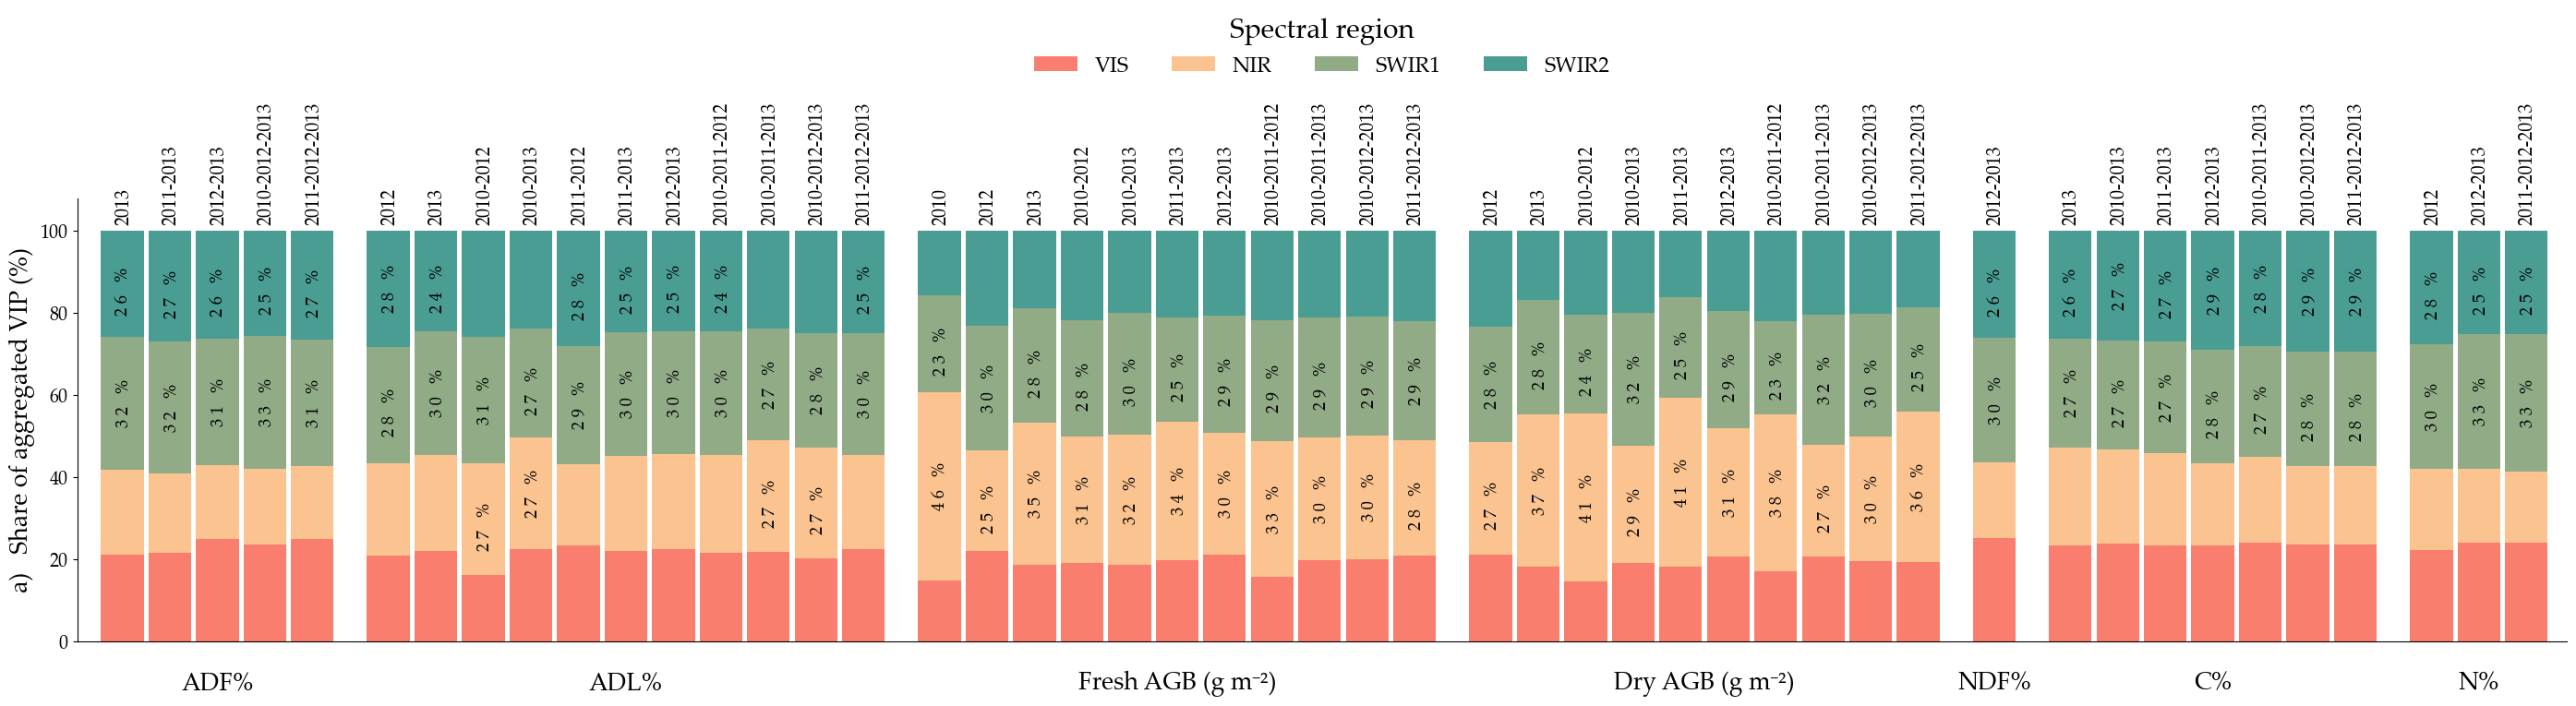

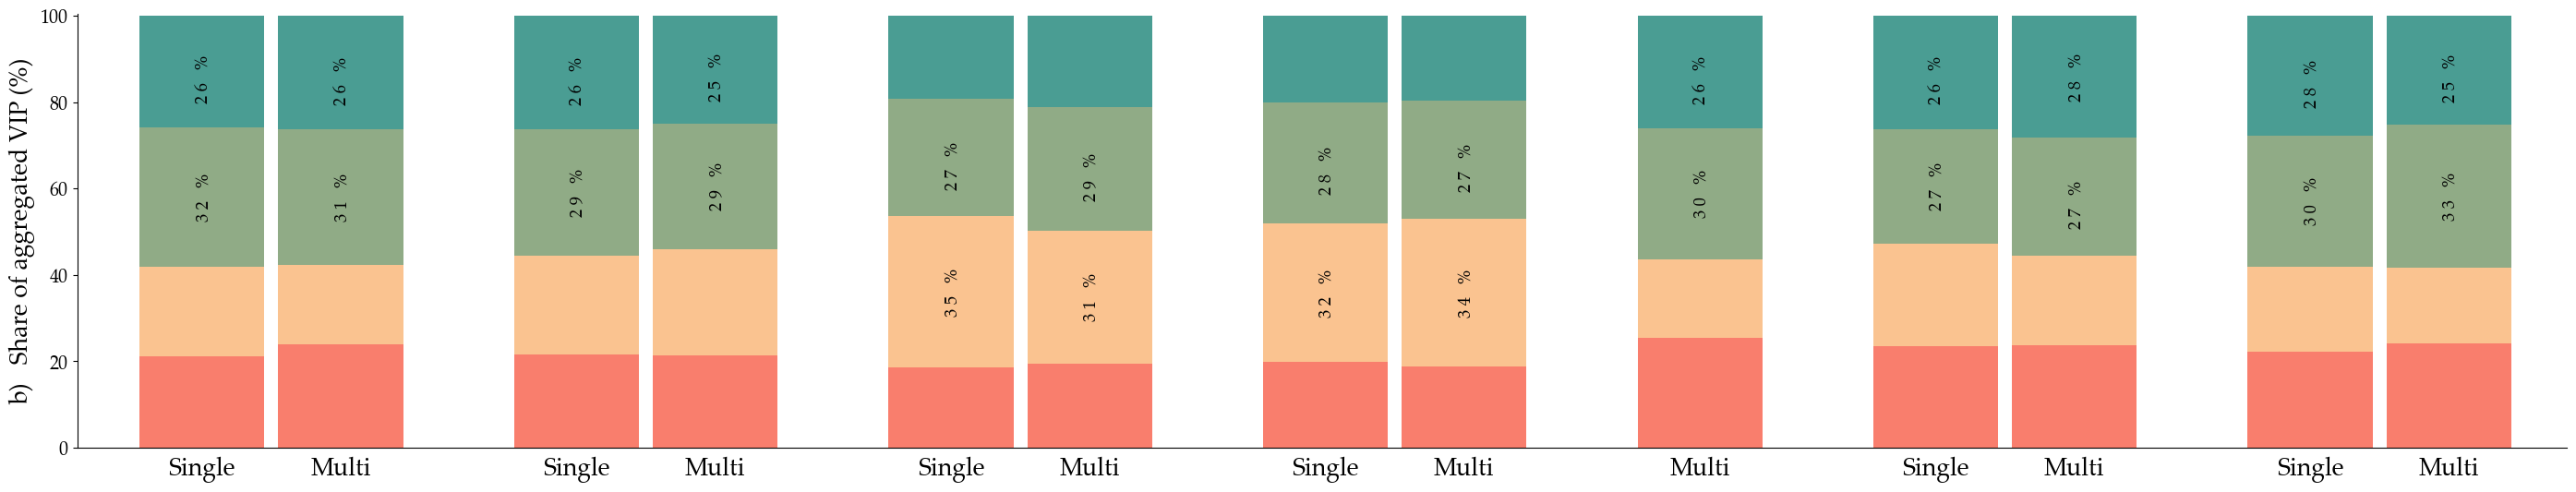

In [23]:
# MAIN
# ============================================================
# Block 5 — ONE pipeline, TWO appendix figures
#   Fig A: Trait × Year (stacked %)
#   Fig B: Trait × Calibration Type (Single vs Multi; stacked %)
#
# Reads VIPS.csv per Year × Trait folder, computes mean VIP per wavelength
# across iterations, aggregates VIP by spectral region (VIS/NIR/SWIR1/SWIR2),
# then plots % share per region.
# ============================================================

# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12
def rel(x): return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype","axes.titlesize": rel(1.6),"axes.labelsize": rel(1.6),
    "figure.titlesize": rel(1.6),"xtick.labelsize": rel(1.6),"ytick.labelsize": rel(1.2),
    "legend.fontsize": rel(1.2),"pdf.fonttype": 42,"ps.fonttype": 42,
})

# -------------------------
# USER CONTROLS
# -------------------------
ROOT = Path(r"...\r_model_output")

# Figure A (Trait × Year)
FIG_A_FIGSIZE = (28, 12)
FIG_A_BAR_WIDTH = 0.45
FIG_A_GAP_WITHIN_TRAIT = 0.05
FIG_A_GAP_BETWEEN_TRAITS = 0.3
FIG_A_LEFT_MARGIN = 0.25
FIG_A_RIGHT_MARGIN = 0.2

# Figure B (Trait × Calibration Type)
FIG_B_FIGSIZE = (28, 7)
FIG_B_BAR_WIDTH = 0.45
FIG_B_GAP_WITHIN_TRAIT = 0.05
FIG_B_GAP_BETWEEN_TRAITS = 0.35
FIG_B_LEFT_MARGIN = 0.225
FIG_B_RIGHT_MARGIN = 0.2

# -------------------------
# Output path helper (fallback if you don't have output_path())
# -------------------------
try:
    output_path  # noqa
except NameError:
    OUTDIR = ROOT / "_figures_out"
    OUTDIR.mkdir(parents=True, exist_ok=True)
    def output_path(fname: str) -> Path:
        return OUTDIR / fname

# -------------------------
# Enforce EXACT manuscript orders
# -------------------------
# Requested panel order (publication labels)
trait_order = [
    "ADF%",
    "ADL%",
    "Fresh AGB (g m⁻²)",
    "Dry AGB (g m⁻²)",
    "NDF%",
    "C%",
    "N%",
]

year_order = [
    "2010","2011","2012","2013","2010-2011","2010-2012","2010-2013","2011-2012","2011-2013","2012-2013",
    "2010-2011-2012","2010-2011-2013","2010-2012-2013","2011-2012-2013"
]

# -------------------------
# Trait labels (internal -> publication)
# -------------------------
trait_labels_pub = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}


# -------------------------
# Region boundaries (your bins; gaps excluded)
# VIS   410–748
# NIR   753–1098
# SWIR1 1107–1862
# SWIR2 1870–2400
# -------------------------
def spectral_region(w):
    w = float(w)
    if 410 <= w <= 748:
        return "VIS"
    if 753 <= w <= 1098:
        return "NIR"
    if 1107 <= w <= 1862:
        return "SWIR1"
    if 1870 <= w <= 2400:
        return "SWIR2"
    return np.nan

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

REGION_COLORS = {
    "VIS":   "#F97E6D",
    "NIR":   "#FAC390",
    "SWIR1": "#90AB86",
    "SWIR2": "#4A9D93",
}

# -------------------------
# Helpers
# -------------------------
def iter_n(path: Path) -> int:
    m = re.search(r"REF_DF_MODELs-(\d+)-", path.name)
    return int(m.group(1)) if m else -1

def parse_folder_name(folder_name: str):
    """
    Expected: PPR2_2012&2013_2026-02-02_Biom_wet_g
      -> ("2012&2013", "Biom_wet_g")
    """
    parts = folder_name.split("_")
    if len(parts) < 4:
        return None, None
    year = parts[1]
    trait = "_".join(parts[3:])
    return year, trait

def annotate_top2(ax, plot_df, x_col="x"):
    """Annotate top-2 region shares per bar in the same style you used."""
    for _, row in plot_df.iterrows():
        vals = {
            r: float(row.get(f"{r}_pct", 0)) if pd.notna(row.get(f"{r}_pct", np.nan)) else 0.0
            for r in region_order
        }
        top2 = sorted(vals.items(), key=lambda kv: kv[1], reverse=True)[:2]
        if len(top2) == 0 or top2[0][1] <= 0:
            continue

        cum_bottom = {}
        running = 0.0
        for r in region_order:
            cum_bottom[r] = running
            running += vals[r]

        for rank, (r_sel, v_sel) in enumerate(top2):
            if v_sel <= 0:
                continue

            y_mid = cum_bottom[r_sel] + v_sel * 0.5
            y_offset_points = -6 if rank == 1 else 0

            ax.annotate(
                " ".join(list(f"{v_sel:.0f} %")),
                xy=(row[x_col], y_mid),
                xytext=(1.5, y_offset_points),
                textcoords="offset points",
                ha="center",
                va="center",
                rotation=90,
                fontsize=rel(1.1),
                clip_on=True
            )

# ============================================================
# STEP 1 — Read VIPs once and build the base table:
# base_wide: Trait × Year with VIS_pct, NIR_pct, SWIR1_pct, SWIR2_pct
# ============================================================
rows = []

for folder in [p for p in ROOT.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)
    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    # Drop Phosphorus (Paper II rule)
    if trait_val == "P_perc":
        continue

    # Keep only expected years and traits
    if year_val not in year_order:
        continue
    if trait_val not in trait_labels_pub:
        continue

    trait_label = trait_labels_pub[trait_val]
    if trait_label not in trait_order:
        continue

    # Pick VIP file for highest iteration run
    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)
    vips = pd.read_csv(vips_file).drop(columns=["Unnamed: 0"], errors="ignore")

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    X = vips[vip_cols].apply(pd.to_numeric, errors="coerce")
    vip_mean_by_wvl = X.mean(axis=0)

    reg_sums = {r: 0.0 for r in region_order}
    for col in vip_cols:
        r = spectral_region(float(col))
        if pd.isna(r):
            continue
        val = vip_mean_by_wvl.get(col, np.nan)
        reg_sums[r] += float(val) if pd.notna(val) else 0.0

    total = sum(reg_sums.values())
    if total <= 0:
        continue

    reg_pcts = {f"{r}_pct": (reg_sums[r] / total) * 100 for r in region_order}

    rows.append({
        "Trait_label": trait_label,
        "inVar": trait_val,
        "Year": year_val,
        "Calibration_Type": "Multi-year" if "-" in year_val else "Single-year",
        **reg_pcts
    })

base_wide = pd.DataFrame(rows)

# Keep VIP regional summaries only for convergent models retained in all_stats
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

base_wide = base_wide.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

# enforce strict ordering
base_wide["Trait_label"] = pd.Categorical(base_wide["Trait_label"], categories=trait_order, ordered=True)
base_wide["Year"] = pd.Categorical(base_wide["Year"], categories=year_order, ordered=True)

base_wide = base_wide.sort_values(["Trait_label", "Year"]).reset_index(drop=True)

# ============================================================
# FIGURE A — Trait × Year
# ============================================================
def plot_trait_by_year(base_wide: pd.DataFrame):
    # build bar_meta (x positions)
    bar_meta = []
    x = 0.0

    for t in trait_order:
        df_t = base_wide[base_wide["Trait_label"] == t].copy()
        years_present = [y for y in year_order if y in df_t["Year"].astype(str).values]

        for y in years_present:
            bar_meta.append({"Trait_label": t, "Year": y, "x": x})
            x += FIG_A_BAR_WIDTH + FIG_A_GAP_WITHIN_TRAIT

        x += FIG_A_GAP_BETWEEN_TRAITS

    bar_meta_df = pd.DataFrame(bar_meta)
    plot_df = pd.merge(bar_meta_df, base_wide, on=["Trait_label", "Year"], how="left")

    fig, ax = plt.subplots(figsize=FIG_A_FIGSIZE)

    bottom = np.zeros(len(plot_df))
    for r in region_order:
        vals = plot_df[f"{r}_pct"].fillna(0).values
        ax.bar(
            plot_df["x"].values,
            vals,
            width=FIG_A_BAR_WIDTH,
            bottom=bottom,
            label=r,
            color=REGION_COLORS[r],
            edgecolor="none"
        )
        bottom += vals

    ax.set_ylim(0, 108)
    ax.set_ylabel("a)   Share of aggregated VIP (%)")

    # Annotate top-2 segments
    annotate_top2(ax, plot_df, x_col="x")

    # Trait labels centered per block
    trait_centers, trait_labels = [], []
    for t in trait_order:
        xs = plot_df.loc[plot_df["Trait_label"] == t, "x"].values
        if len(xs) == 0:
            continue
        trait_centers.append(xs.mean())
        trait_labels.append(t)
    ax.set_xticks(trait_centers)
    ax.set_xticklabels(trait_labels, rotation=0)
    ax.tick_params(axis="x", length=0, pad=22.5)

    # Year labels above each bar
    for _, row in plot_df.iterrows():
        ax.annotate(
            str(row["Year"]),
            xy=(row["x"], 101.5),
            xytext=(1.5, 0),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=rel(1.2),
            rotation=90,
            clip_on=False
        )

    ax.legend(
        title="Spectral region",
        frameon=False,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.45),
        fontsize=rel(1.4),
        title_fontsize=rel(1.8)
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    xmin = plot_df["x"].min() - FIG_A_BAR_WIDTH / 2 - FIG_A_LEFT_MARGIN
    xmax = plot_df["x"].max() + FIG_A_BAR_WIDTH / 2 + FIG_A_RIGHT_MARGIN
    ax.set_xlim(xmin, xmax)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)

    # # Save
    # fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-Year.pdf"), bbox_inches="tight")
    # fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-Year.png"), bbox_inches="tight", dpi=300)

    return fig, ax, plot_df

# ============================================================
# FIGURE B — Trait × Calibration Type (Single vs Multi)
# (computed from the same base_wide, not re-reading files)
# ============================================================
def plot_trait_by_calibration(base_wide: pd.DataFrame):
    wide_cal = (
        base_wide
        .groupby(["Trait_label", "Calibration_Type"], observed=True)[[f"{r}_pct" for r in region_order]]
        .mean()
        .reset_index()
    )

    wide_cal["Trait_label"] = pd.Categorical(wide_cal["Trait_label"], categories=trait_order, ordered=True)
    wide_cal["Calibration_Type"] = pd.Categorical(
        wide_cal["Calibration_Type"],
        categories=["Single-year", "Multi-year"],
        ordered=True
    )
    wide_cal = wide_cal.sort_values(["Trait_label", "Calibration_Type"]).reset_index(drop=True)

    # build x positions (2 bars per trait)
    bar_meta = []
    x = 0.0
    for t in trait_order:
        df_t = wide_cal[wide_cal["Trait_label"] == t]
        for cal in ["Single-year", "Multi-year"]:
            if cal in df_t["Calibration_Type"].astype(str).values:
                bar_meta.append({"Trait_label": t, "Calibration_Type": cal, "x": x})
                x += FIG_B_BAR_WIDTH + FIG_B_GAP_WITHIN_TRAIT
        x += FIG_B_GAP_BETWEEN_TRAITS

    bar_meta_df = pd.DataFrame(bar_meta)
    plot_df = pd.merge(bar_meta_df, wide_cal, on=["Trait_label", "Calibration_Type"], how="left")

    fig, ax = plt.subplots(figsize=FIG_B_FIGSIZE)

    bottom = np.zeros(len(plot_df))
    for r in region_order:
        vals = plot_df[f"{r}_pct"].fillna(0).values
        ax.bar(
            plot_df["x"].values,
            vals,
            width=FIG_B_BAR_WIDTH,
            bottom=bottom,
            label=r,
            color=REGION_COLORS[r],
            edgecolor="none"
        )
        bottom += vals

    ax.set_ylim(0, 100.5)
    ax.set_ylabel("b)   Share of aggregated VIP (%)")

    # Annotate top-2 segments
    annotate_top2(ax, plot_df, x_col="x")

    # X-axis: show Single/Multi tick labels (outside), hide trait names
    ax.set_xticks(plot_df["x"].values)
    ax.set_xticklabels(
        ["Single" if ct == "Single-year" else "Multi"
         for ct in plot_df["Calibration_Type"].astype(str)],
        rotation=0
    )
    ax.tick_params(axis="x", length=0, pad=7)

    # ax.legend(
    #     title="Spectral region",
    #     frameon=False,
    #     ncol=4,
    #     loc="upper center",
    #     bbox_to_anchor=(0.5, 1.12),
    #     fontsize=rel(1.4),
    #     title_fontsize=rel(1.8)
    # )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    xmin = plot_df["x"].min() - FIG_B_BAR_WIDTH / 2 - FIG_B_LEFT_MARGIN
    xmax = plot_df["x"].max() + FIG_B_BAR_WIDTH / 2 + FIG_B_RIGHT_MARGIN
    ax.set_xlim(xmin, xmax)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)

    # # Save
    # fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-CalibrationType.pdf"), bbox_inches="tight")
    # fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-CalibrationType.png"), bbox_inches="tight", dpi=300)

    return fig, ax, plot_df

# ============================================================
# RUN BOTH FIGURES (one go)
# ============================================================
figA, axA, plotA = plot_trait_by_year(base_wide)
figB, axB, plotB = plot_trait_by_calibration(base_wide)

plt.show()

# # ============================================================
# # DROP-IN ADDITION — save Fig A + Fig B together as ONE image/PDF
# # (keeps your two plotting functions unchanged)
# # ============================================================

# # Paths to already-saved PNGs
# imgA_path = output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-Year.png")
# imgB_path = output_path("PPR2_APP-X-FIGURE_VIPS_Trait-by-CalibrationType.png")

# # Open images exactly as saved
# imgA = Image.open(imgA_path)
# imgB = Image.open(imgB_path)

# # Create new canvas (no resizing, no padding, no scaling)
# combined = Image.new(
#     "RGB",
#     (imgA.width, imgA.height + imgB.height)
# )

# # Paste them directly one under the other
# combined.paste(imgA, (0, 0))
# combined.paste(imgB, (0, imgA.height))

# # Save combined result
# combined.save(output_path("PPR2_APP-X-COMBINED.png"))

In [24]:
# base_wide[["Year", "inVar"]].drop_duplicates().shape[0]
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

base_keys = base_wide[["Year", "inVar"]].drop_duplicates()

missing_from_base_wide = valid_model_keys.merge(
    base_keys,
    on=["Year", "inVar"],
    how="left",
    indicator=True
).query('_merge == "left_only"')

print(missing_from_base_wide) # P_perc excluded intentionally

         Year   inVar     _merge
48  2010-2012  P_perc  left_only


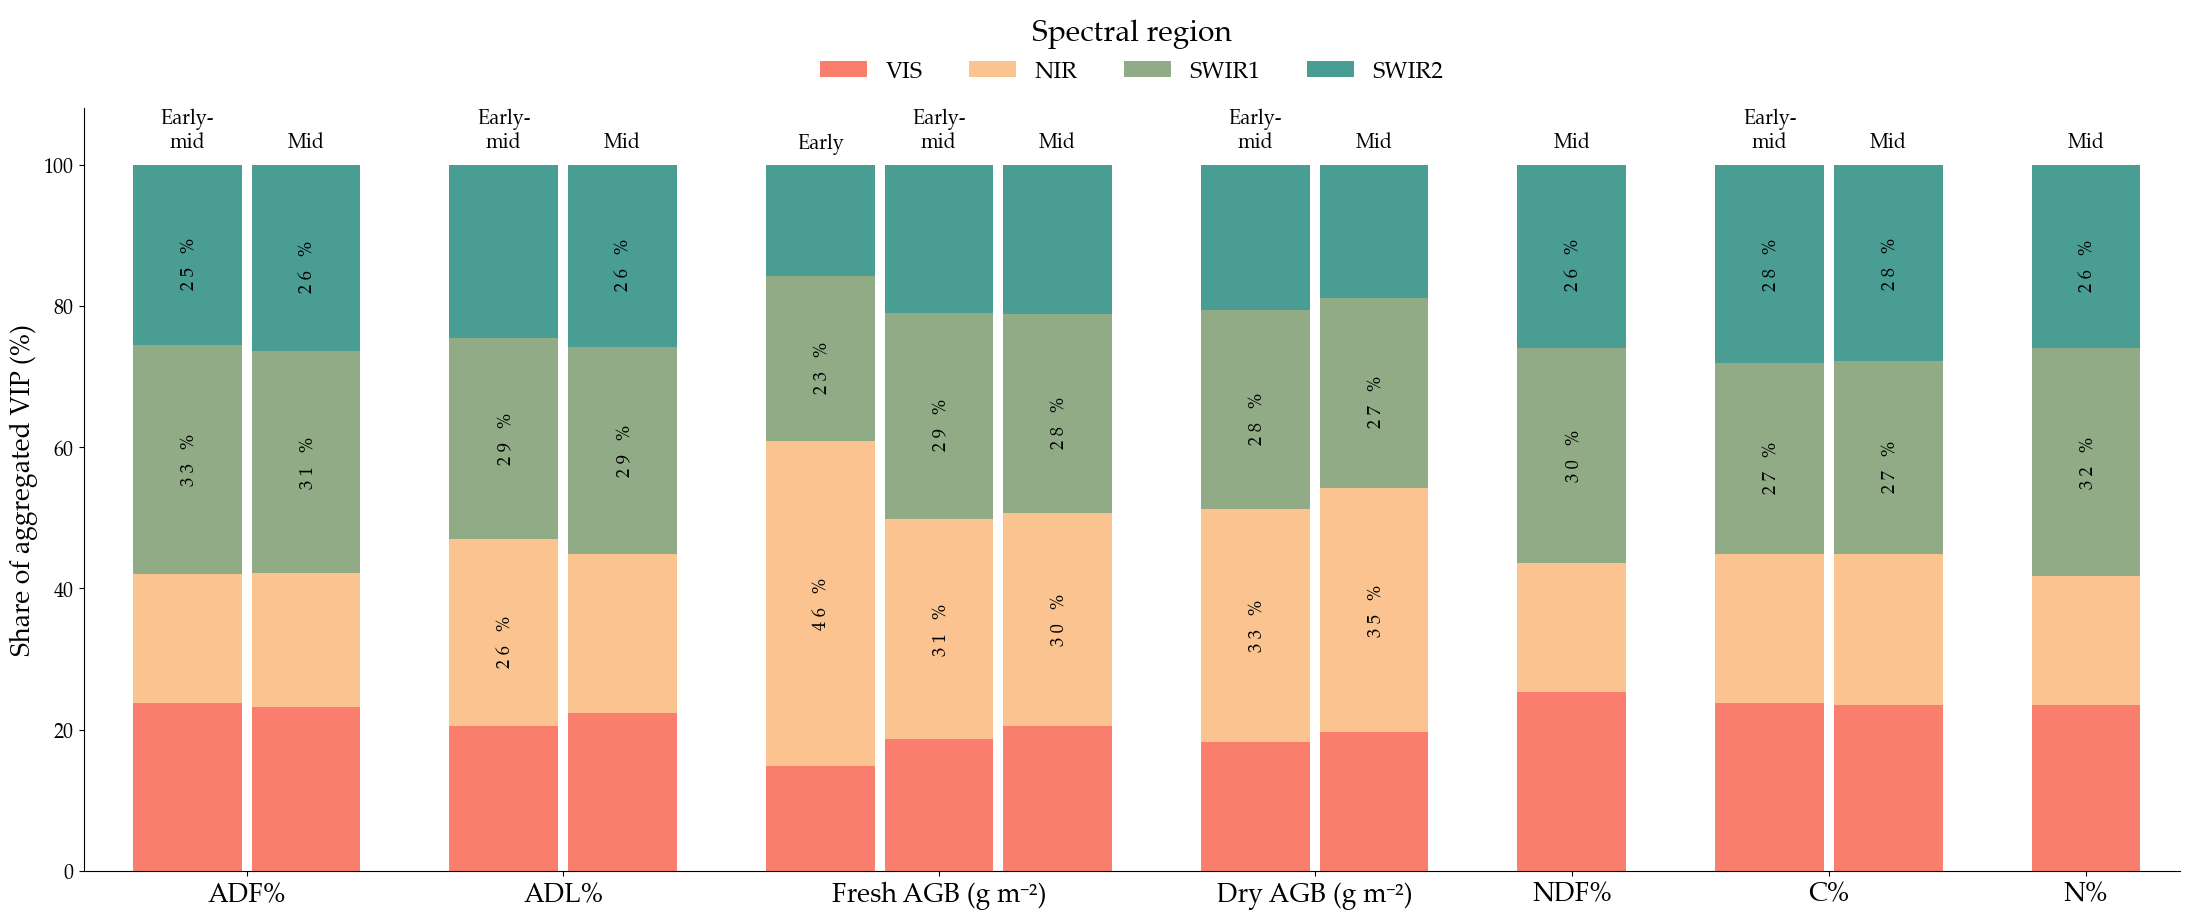

In [25]:
### MAIN FIGURE ###
# ============================================================
# Block 5 — Aggregated VIPs by Phenology Group
# 3 bars per trait:
#   Early (2010)
#   Early–mid (2010-* combinations)
#   Mid (2011–2013 & combinations)
# ============================================================

# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12
def rel(x): return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype","axes.titlesize": rel(1.6),"axes.labelsize": rel(1.6),
    "figure.titlesize": rel(1.6),"xtick.labelsize": rel(1.6),"ytick.labelsize": rel(1.2),
    "legend.fontsize": rel(1.2),"pdf.fonttype": 42,"ps.fonttype": 42,
})

# -------------------------
# USER CONTROLS
# -------------------------
FIGSIZE = (22, 12)
BAR_WIDTH = 0.55
GAP_WITHIN_TRAIT = 0.05
GAP_BETWEEN_TRAITS = 0.4

root = Path(r"...\r_model_output")

# -------------------------
# Trait order
# -------------------------
# Requested panel order (publication labels)
trait_order = [
    "ADF%",
    "ADL%",
    "Fresh AGB (g m⁻²)",
    "Dry AGB (g m⁻²)",
    "NDF%",
    "C%",
    "N%",
]

# -------------------------
# Trait mapping
# -------------------------
trait_labels_pub = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}

# -------------------------
# Spectral regions
# -------------------------
def spectral_region(w):
    w = float(w)
    if 410 <= w <= 748: return "VIS"
    if 753 <= w <= 1098: return "NIR"
    if 1107 <= w <= 1862: return "SWIR1"
    if 1870 <= w <= 2400: return "SWIR2"
    return np.nan

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

REGION_COLORS = {
    "VIS":   "#F97E6D",
    "NIR":   "#FAC390",
    "SWIR1": "#90AB86",
    "SWIR2": "#4A9D93",
}

# -------------------------
# Phenology-group colors (your spec)
# -------------------------
PHENO_COLORS = {
    "Early Phenology": to_rgba("#A9CE9A"),      # all three are already 80% opaque applied HEX codes and matching with the MS Word doc.
    "Mid Phenology": to_rgba("#EDB087"),     #E69257   
    "Early-mid Phenology": to_rgba("#E8D16E"), #DEBF33
}

EARLY = {"2010"}

MID = {
    "2011","2012","2013",
    "2011-2012","2011-2013","2012-2013",
    "2011-2012-2013"
}

EARLY_MID = {
    "2010-2011","2010-2012","2010-2013",
    "2010-2011-2012","2010-2011-2013","2010-2012-2013"
}

# -------------------------
# Helpers
# -------------------------
def iter_n(path: Path) -> int:
    m = re.search(r"REF_DF_MODELs-(\d+)-", path.name)
    return int(m.group(1)) if m else -1

def parse_folder_name(folder_name: str):
    parts = folder_name.split("_")
    if len(parts) < 4:
        return None, None
    year = parts[1]
    trait = "_".join(parts[3:])
    return year, trait

# -------------------------
# Phenology classification
# -------------------------
def phenology_group(year_str):

    if year_str == "2010":
        return "Early"

    if year_str.startswith("2010-"):
        return "Early–mid"

    # Mid phenology: any combination without 2010
    return "Mid"

phenology_order = ["Early", "Early–mid", "Mid"]

# -------------------------
# Build VIP table per Year × Trait
# -------------------------
rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)
    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    if trait_val == "P_perc":
        continue

    if trait_val not in trait_labels_pub:
        continue

    trait_label = trait_labels_pub[trait_val]
    if trait_label not in trait_order:
        continue

    phen_group = phenology_group(year_val)

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)
    vips = pd.read_csv(vips_file).drop(columns=["Unnamed: 0"], errors="ignore")

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    X = vips[vip_cols].apply(pd.to_numeric, errors="coerce")
    vip_mean_by_wvl = X.mean(axis=0)

    reg_sums = {r: 0.0 for r in region_order}

    for col in vip_cols:
        r = spectral_region(float(col))
        if pd.isna(r):
            continue
        reg_sums[r] += float(vip_mean_by_wvl[col]) if pd.notna(vip_mean_by_wvl[col]) else 0.0

    total = sum(reg_sums.values())
    if total <= 0:
        continue

    reg_pcts = {f"{r}_pct": (reg_sums[r] / total) * 100 for r in region_order}

    rows.append({
        "Trait_label": trait_label,
        "Phenology": phen_group,
        "Year": year_val,
        "inVar": trait_val,
        **reg_pcts
    })

df = pd.DataFrame(rows)

# Keep VIP phenology summaries only for convergent models retained in all_stats
valid_model_keys = all_stats[["Year", "inVar"]].drop_duplicates()

df = df.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

# -------------------------
# Aggregate across years within phenology group
# -------------------------
wide = (
    df.groupby(["Trait_label", "Phenology"])
      [[f"{r}_pct" for r in region_order]]
      .mean()
      .reset_index()
)

wide["Trait_label"] = pd.Categorical(wide["Trait_label"], categories=trait_order, ordered=True)
wide["Phenology"] = pd.Categorical(wide["Phenology"], categories=phenology_order, ordered=True)

wide = wide.sort_values(["Trait_label", "Phenology"]).reset_index(drop=True)

# -------------------------
# Build x positions (3 bars per trait)
# -------------------------
bar_meta = []
x = 0.0

for t in trait_order:
    df_t = wide[wide["Trait_label"] == t]

    for ph in phenology_order:
        if ph in df_t["Phenology"].values:
            bar_meta.append({"Trait_label": t, "Phenology": ph, "x": x})
            x += BAR_WIDTH + GAP_WITHIN_TRAIT

    x += GAP_BETWEEN_TRAITS

bar_meta_df = pd.DataFrame(bar_meta)

plot_df2 = pd.merge(
    bar_meta_df,
    wide,
    on=["Trait_label", "Phenology"],
    how="left"
)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

bottom = np.zeros(len(plot_df2))

for r in region_order:
    vals = plot_df2[f"{r}_pct"].fillna(0).values
    ax.bar(
        plot_df2["x"].values,
        vals,
        width=BAR_WIDTH,
        bottom=bottom,
        label=r,
        color=REGION_COLORS[r],
        edgecolor="none"
    )
    bottom += vals

ax.set_ylim(0, 108)
ax.set_ylabel("Share of aggregated VIP (%)")

# -------------------------
# Annotate TOP-2 per bar
# -------------------------
for _, row in plot_df2.iterrows():

    vals = {r: float(row[f"{r}_pct"]) for r in region_order}
    top2 = sorted(vals.items(), key=lambda kv: kv[1], reverse=True)[:2]

    cum_bottom = {}
    running = 0.0
    for r in region_order:
        cum_bottom[r] = running
        running += vals[r]

    for rank, (r_sel, v_sel) in enumerate(top2):

        if v_sel <= 0:
            continue

        y_mid = cum_bottom[r_sel] + v_sel * 0.5
        y_offset = -6 if rank == 1 else 0

        ax.annotate(
            " ".join(list(f"{v_sel:.0f} %")),
            xy=(row["x"], y_mid),
            xytext=(1.5, y_offset),
            textcoords="offset points",
            ha="center",
            va="center",
            rotation=90,
            fontsize=rel(1.1),
            clip_on=True
        )

# Trait centers
trait_centers = []
trait_labels = []

for t in trait_order:
    xs = plot_df2.loc[plot_df2["Trait_label"] == t, "x"].values
    if len(xs) == 0:
        continue
    trait_centers.append(xs.mean())
    trait_labels.append(t)

def wrap_trait_label(s: str) -> str:
    # manual, controlled wrapping (best for manuscript figures)
    return (s
            .replace("Acid Detergent ", "Acid Detergent\n")
            .replace("Neutral Detergent ", "Neutral Detergent\n")
           )

ax.set_xticks(trait_centers)
# ax.set_xticklabels(trait_labels)

trait_labels_wrapped = [wrap_trait_label(t) for t in trait_labels]
ax.set_xticklabels(trait_labels_wrapped, rotation=0)    

def wrap_pheno(s: str) -> str:
    return "Early-\nmid" if s in ["Early–mid", "Early-mid"] else s

# Phenology labels above bars (horizontal)
for _, row in plot_df2.iterrows():
    ax.annotate(
        wrap_pheno(str(row["Phenology"])),
        xy=(row["x"], 101.5),
        ha="center",
        va="bottom",
        fontsize=rel(1.2),
        rotation=0,
        clip_on=False
    )

# Legend
ax.legend(
    title="Spectral region",
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.145),
    fontsize=rel(1.4),
    title_fontsize=rel(1.8)
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

LEFT_MARGIN = 0.25
RIGHT_MARGIN = 0.2

xmin = plot_df2["x"].min() - BAR_WIDTH/2 - LEFT_MARGIN
xmax = plot_df2["x"].max() + BAR_WIDTH/2 + RIGHT_MARGIN
ax.set_xlim(xmin, xmax)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# # -------------------------
# # Save figure (PNG, 300 dpi & PDF)
# # -------------------------
# fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_vs_Trait-Phenology-Years.pdf"), bbox_inches="tight")
# fig.savefig(output_path("PPR2_APP-X-FIGURE_VIPS_vs_Trait-Phenology-Years.png"), bbox_inches="tight", dpi=300)

plt.show()

In [26]:
# Load Libraries
import os, time
import numpy as np
import rasterio
from rasterio.features import geometry_mask
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, box, mapping
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from geopandas.io.file import _to_file
import fiona
import rasterio
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.crs import CRS
from rasterio.windows import Window
from tqdm import tqdm
import glob
import re

# No_Duplicates_Single-Year_Model_input_2010_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv

# load reflectance data
Input_FILES = {
    2010: "./input_data/No_Duplicates_Single-Year_Model_input_2010_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2011: "./input_data/No_Duplicates_Single-Year_Model_input_2011_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2012: "./input_data/No_Duplicates_Single-Year_Model_input_2012_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2013: "./input_data/No_Duplicates_Single-Year_Model_input_2013_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
}

df_inputti_2010 = pd.read_csv(Input_FILES[2010])
df_inputti_2011 = pd.read_csv(Input_FILES[2011])
df_inputti_2012 = pd.read_csv(Input_FILES[2012])
df_inputti_2013 = pd.read_csv(Input_FILES[2013])

# print(df_inputti_2010.head())

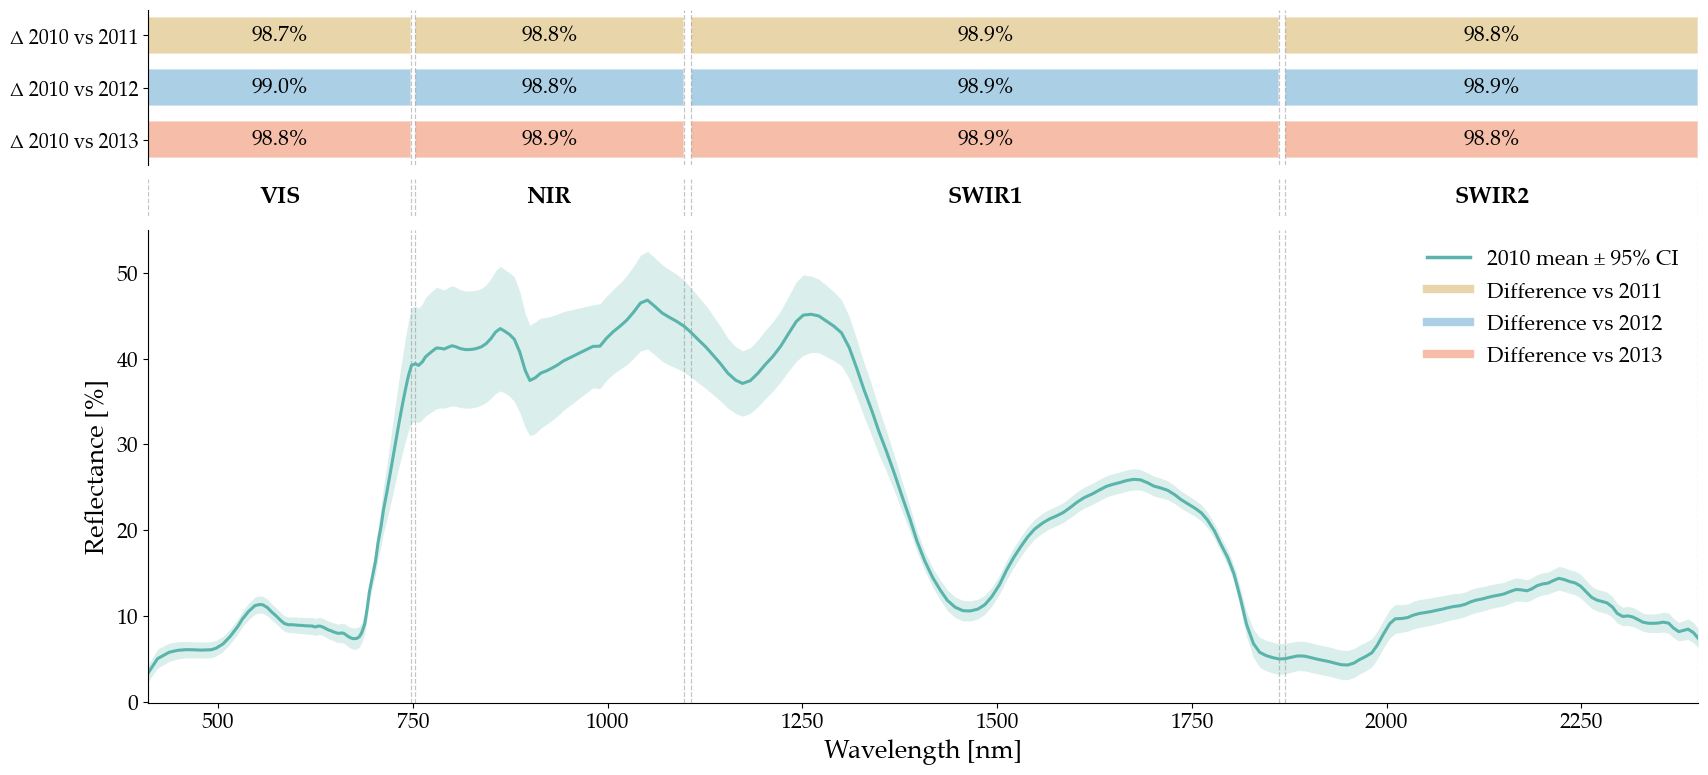

In [28]:
# ============================================================
# INPUT REFLECTANCE FIGURE — ONE SELECTED YEAR
# Top: regional % difference from other years
# Middle: spectral region labels
# Main: mean reflectance ± 95% CI
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

SELECTED_YEAR = 2010

FIGSIZE = (20, 9)
base_size = 12

def rel(x):
    return base_size * (x + 0.3)

YEAR_COLORS = {
    2010: "#5ab4ac",
    2011: "#d8b365", #"#a6611a",
    2012: "#67a9cf",
    2013: "#ef8a62",
}

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

# -------------------------
# Load input data
# -------------------------
Input_FILES = {
    2010: "./input_data/No_Duplicates_Single-Year_Model_input_2010_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2011: "./input_data/No_Duplicates_Single-Year_Model_input_2011_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2012: "./input_data/No_Duplicates_Single-Year_Model_input_2012_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2013: "./input_data/No_Duplicates_Single-Year_Model_input_2013_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
}

dfs = {yr: pd.read_csv(path) for yr, path in Input_FILES.items()}

# -------------------------
# Reflectance columns
# -------------------------
def get_reflectance_cols(df):
    cols = [c for c in df.columns if re.fullmatch(r"X\d+", str(c))]
    cols = sorted(cols, key=lambda x: int(x.replace("X", "")))
    return cols

ref_cols = get_reflectance_cols(dfs[SELECTED_YEAR])
wavelengths = np.array([int(c.replace("X", "")) for c in ref_cols])

# -------------------------
# Mean and CI for selected year
# -------------------------
df_sel = dfs[SELECTED_YEAR][ref_cols].apply(pd.to_numeric, errors="coerce")
df_sel = df_sel / 100

mean_sel = df_sel.mean(axis=0)
se_sel = df_sel.sem(axis=0)
ci95_sel = 1.96 * se_sel

# -------------------------
# Regional % difference
# -------------------------
rows = []

for comp_year, df_comp_raw in dfs.items():

    if comp_year == SELECTED_YEAR:
        continue

    df_comp = df_comp_raw[ref_cols].apply(pd.to_numeric, errors="coerce")
    mean_comp = df_comp.mean(axis=0)

    # Absolute percentage difference per wavelength
    pct_diff = ((mean_sel - mean_comp).abs() / mean_comp.abs()) * 100

    for reg, (x0, x1) in REGION_BANDS.items():

        mask = (wavelengths >= x0) & (wavelengths <= x1)

        rows.append({
            "Comparison": f"{SELECTED_YEAR} vs {comp_year}",
            "Comparison_year": comp_year,
            "Region": reg,
            "Pct_diff": pct_diff[mask].mean()
        })

diff_df = pd.DataFrame(rows)

# -------------------------
# Figure layout
# -------------------------
fig = plt.figure(figsize=FIGSIZE)

gs = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[1.45, 0.35, 4.4],
    hspace=0.06
)

ax_top = fig.add_subplot(gs[0, 0])
ax_region = fig.add_subplot(gs[1, 0], sharex=ax_top)
ax_main = fig.add_subplot(gs[2, 0], sharex=ax_top)

# -------------------------
# Shared spectral boundaries
# -------------------------
for ax in [ax_top, ax_region, ax_main]:
    for reg, (x0, x1) in REGION_BANDS.items():
        ax.axvline(x0, color="grey", lw=0.9, ls="--", alpha=0.45)
        ax.axvline(x1, color="grey", lw=0.9, ls="--", alpha=0.45)

# -------------------------
# Top panel: regional % difference bars
# -------------------------
comparison_years = [yr for yr in dfs.keys() if yr != SELECTED_YEAR]
y_positions = np.arange(len(comparison_years))
bar_height = 0.72

for i, comp_year in enumerate(comparison_years):

    d_comp = diff_df[diff_df["Comparison_year"] == comp_year]

    for reg in region_order:

        d_reg = d_comp[d_comp["Region"] == reg]

        if d_reg.empty:
            continue

        pct = float(d_reg["Pct_diff"].iloc[0])
        x0, x1 = REGION_BANDS[reg]
        width = x1 - x0

        ax_top.barh(
            y=i,
            width=width,
            left=x0,
            height=bar_height,
            color=YEAR_COLORS[comp_year],
            alpha=0.55,
            edgecolor="white",
            linewidth=1.1
        )

        ax_top.text(
            x0 + width / 2,
            i,
            f"{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=rel(1.0)
        )

ax_top.set_yticks(y_positions)
ax_top.set_yticklabels([f"Δ {SELECTED_YEAR} vs {yr}" for yr in comparison_years])
ax_top.invert_yaxis()
ax_top.set_xlim(410, 2400)
ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
# ax_top.set_title(
#     f"Regional reflectance difference and mean plot-level spectra for {SELECTED_YEAR}",
#     fontsize=rel(1.5),
#     fontweight="bold",
#     pad=10
# )

# -------------------------
# Middle spectral-region labels
# -------------------------
ax_region.set_ylim(0, 1)
ax_region.set_yticks([])

for reg, (x0, x1) in REGION_BANDS.items():
    ax_region.text(
        (x0 + x1) / 2,
        0.5,
        reg,
        ha="center",
        va="center",
        fontsize=rel(1.1),
        fontweight="bold"
    )

ax_region.tick_params(axis="x", bottom=False, labelbottom=False)

# -------------------------
# Main panel: mean reflectance ± CI
# -------------------------
color = YEAR_COLORS[SELECTED_YEAR]

ax_main.plot(
    wavelengths,
    mean_sel.values,
    color=color,
    lw=2.2,
    label=str(SELECTED_YEAR)
)

ax_main.fill_between(
    wavelengths,
    (mean_sel - ci95_sel).values,
    (mean_sel + ci95_sel).values,
    color=color,
    alpha=0.22,
    linewidth=0
)

ax_main.set_xlabel("Wavelength [nm]", fontsize=rel(1.25))
ax_main.set_ylabel("Reflectance [%]", fontsize=rel(1.25))
ax_main.set_xlim(410, 2400)
ax_main.tick_params(axis="both", labelsize=rel(1.0))

# -------------------------
# Legend
# -------------------------
legend_handles = [
    Line2D([0], [0], color=YEAR_COLORS[SELECTED_YEAR], lw=2.5, label=f"{SELECTED_YEAR} mean ± 95% CI")
]

for yr in comparison_years:
    legend_handles.append(
        Line2D([0], [0], color=YEAR_COLORS[yr], lw=6, alpha=0.55, label=f"Difference vs {yr}")
    )

ax_main.legend(
    handles=legend_handles,
    frameon=False,
    loc="upper right",
    fontsize=rel(1.0)
)

# -------------------------
# Styling
# -------------------------
for ax in [ax_top, ax_region, ax_main]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

ax_top.spines["bottom"].set_visible(False)
ax_region.spines["left"].set_visible(False)
ax_region.spines["bottom"].set_visible(False)
ax_region.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

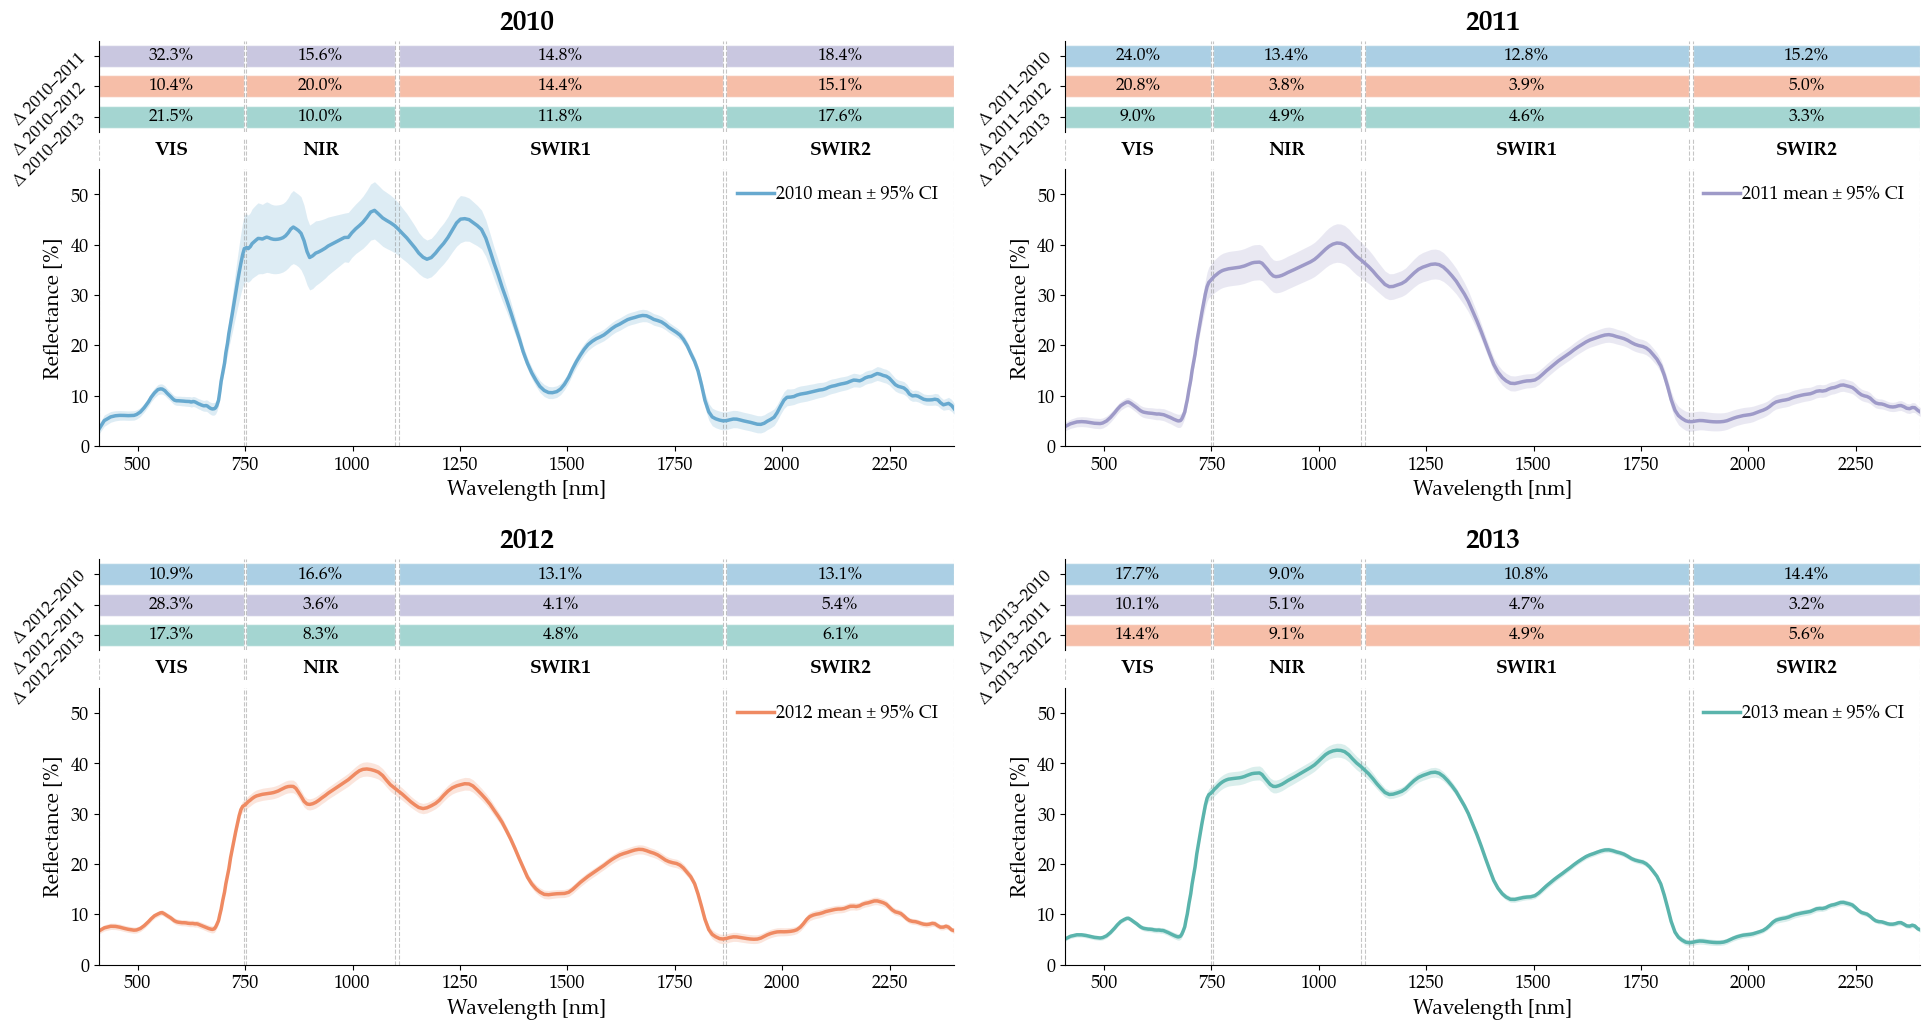

In [29]:
# ============================================================
# INPUT REFLECTANCE FIGURE — ALL YEARS GRID
# Each year panel:
# Top: regional % difference from other years
# Middle: spectral region labels
# Main: mean reflectance ± 95% CI
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIGSIZE = (23.5, 12)
base_size = 12

def rel(x):
    return base_size * (x + 0.3)

YEAR_COLORS = {
    2010: "#67a9cf",
    2011: "#9e9ac8", # check https://colorbrewer2.org/ site for color blind friendly palette(s)
    2012: "#ef8a62",
    2013: "#5ab4ac",
}

YEARS = [2010, 2011, 2012, 2013]

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

region_order = ["VIS", "NIR", "SWIR1", "SWIR2"]

Input_FILES = {
    2010: "./input_data/No_Duplicates_Single-Year_Model_input_2010_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2011: "./input_data/No_Duplicates_Single-Year_Model_input_2011_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2012: "./input_data/No_Duplicates_Single-Year_Model_input_2012_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
    2013: "./input_data/No_Duplicates_Single-Year_Model_input_2013_REF_INTERPOLATED_with_Metadata_Plots_All-Accurate.csv",
}

dfs = {yr: pd.read_csv(path) for yr, path in Input_FILES.items()}

def get_reflectance_cols(df):
    cols = [c for c in df.columns if re.fullmatch(r"X\d+", str(c))]
    return sorted(cols, key=lambda x: int(x.replace("X", "")))

ref_cols = get_reflectance_cols(dfs[2010])
wavelengths = np.array([int(c.replace("X", "")) for c in ref_cols])

# Pre-compute yearly mean and CI
year_stats = {}

for yr in YEARS:
    X = dfs[yr][ref_cols].apply(pd.to_numeric, errors="coerce") / 100
    mean = X.mean(axis=0)
    se = X.sem(axis=0)
    ci95 = 1.96 * se

    year_stats[yr] = {
        "mean": mean,
        "ci95": ci95,
        "n": len(X)
    }

def draw_year_panel(fig, outer_spec, selected_year):

    subgs = outer_spec.subgridspec(
        nrows=3,
        ncols=1,
        height_ratios=[1.45, 0.35, 4.4],
        hspace=0.06
    )

    ax_top = fig.add_subplot(subgs[0, 0])
    ax_region = fig.add_subplot(subgs[1, 0], sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2, 0], sharex=ax_top)

    mean_sel = year_stats[selected_year]["mean"]
    ci95_sel = year_stats[selected_year]["ci95"]

    # -------------------------
    # Regional % difference
    # -------------------------
    rows = []

    for comp_year in YEARS:

        if comp_year == selected_year:
            continue

        mean_comp = year_stats[comp_year]["mean"]

        pct_diff = ((mean_sel - mean_comp).abs() / mean_comp.abs()) * 100

        for reg, (x0, x1) in REGION_BANDS.items():

            mask = (wavelengths >= x0) & (wavelengths <= x1)

            rows.append({
                "Comparison_year": comp_year,
                "Region": reg,
                "Pct_diff": pct_diff[mask].mean()
            })

    diff_df = pd.DataFrame(rows)
    
    ## NOTE:
    ## Regional values represent independently calculated mean percentage
    ## reflectance differences within VIS, NIR, SWIR1, and SWIR2. Because
    ## each region is averaged separately, the resulting percentages are
    ## not proportions of a common total and therefore are not expected
    ## to sum to 100%. 
    # print(
    # selected_year,
    # diff_df.groupby("Comparison_year")["Pct_diff"].sum()
    # )

    # -------------------------
    # Shared spectral boundaries
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        for reg, (x0, x1) in REGION_BANDS.items():
            ax.axvline(x0, color="grey", lw=0.8, ls="--", alpha=0.45)
            ax.axvline(x1, color="grey", lw=0.8, ls="--", alpha=0.45)

    # -------------------------
    # Top panel: regional % difference bars
    # -------------------------
    comparison_years = [yr for yr in YEARS if yr != selected_year]
    y_positions = np.arange(len(comparison_years))
    bar_height = 0.72

    for i, comp_year in enumerate(comparison_years):

        d_comp = diff_df[diff_df["Comparison_year"] == comp_year]

        for reg in region_order:

            d_reg = d_comp[d_comp["Region"] == reg]

            if d_reg.empty:
                continue

            pct = float(d_reg["Pct_diff"].iloc[0])
            x0, x1 = REGION_BANDS[reg]
            width = x1 - x0

            ax_top.barh(
                y=i,
                width=width,
                left=x0,
                height=bar_height,
                color=YEAR_COLORS[comp_year],
                alpha=0.55,
                edgecolor="white",
                linewidth=1.0
            )

            ax_top.text(
                x0 + width / 2,
                i,
                f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=rel(0.75)
            )

    ax_top.set_yticks(y_positions)
    ax_top.set_yticklabels(
        [f"Δ {selected_year}–{yr}" for yr in comparison_years],
        fontsize=rel(0.75),
        rotation = 45
    )
    ax_top.invert_yaxis()
    ax_top.set_xlim(410, 2400)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

    ax_top.set_title(
        f"{selected_year}",
        fontsize=rel(1.35),
        fontweight="bold",
        pad=8
    )

    # -------------------------
    # Middle spectral-region labels
    # -------------------------
    ax_region.set_ylim(0, 1)
    ax_region.set_yticks([])

    for reg, (x0, x1) in REGION_BANDS.items():
        ax_region.text(
            (x0 + x1) / 2,
            0.5,
            reg,
            ha="center",
            va="center",
            fontsize=rel(0.85),
            fontweight="bold"
        )

    ax_region.tick_params(axis="x", bottom=False, labelbottom=False)

    # -------------------------
    # Main panel: mean reflectance ± CI
    # -------------------------
    color = YEAR_COLORS[selected_year]

    ax_main.plot(
        wavelengths,
        mean_sel.values,
        color=color,
        lw=2.5,
        label=f"{selected_year} mean ± 95% CI"
    )

    ax_main.fill_between(
        wavelengths,
        (mean_sel - ci95_sel).values,
        (mean_sel + ci95_sel).values,
        color=color,
        alpha=0.22, # 0.15
        linewidth=0
    )

    ax_main.set_xlim(410, 2400)
    ax_main.set_ylim(0, 55)
    ax_main.set_yticks(np.arange(0, 51, 10))
    ax_main.set_xlabel("Wavelength [nm]", fontsize=rel(0.95))
    ax_main.set_ylabel("Reflectance [%]", fontsize=rel(0.95))
    ax_main.tick_params(axis="both", labelsize=rel(0.8))

    ax_main.legend(
        frameon=False,
        loc="upper right",
        fontsize=rel(0.8),
        handletextpad=0.1 # move CI legend text to the right
    )

    # -------------------------
    # Styling
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

    return ax_top, ax_region, ax_main


# -------------------------
# Figure layout: 2 × 2 grid
# -------------------------
fig = plt.figure(figsize=FIGSIZE)

outer_gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    wspace=0.13, # Space in between grid columns
    hspace=0.28 # 0.26 Space in between grid rows
)

for idx, yr in enumerate(YEARS):

    row = idx // 2
    col = idx % 2

    draw_year_panel(
        fig=fig,
        outer_spec=outer_gs[row, col],
        selected_year=yr
    )

# fig.suptitle(
#     "Inter-annual differences in plot-level APEX reflectance spectra",
#     fontsize=rel(1.6),
#     fontweight="bold",
#     y=0.98
# )

plt.tight_layout(rect=[0, 0, 1, 0.965])

# # -------------------------
# # Save figure (PNG, 300 dpi & PDF)
# # -------------------------
# # pad_inches trims excess outer whitespace without altering any figure element(s)
# fig.savefig(output_path("PPR2_FIGURE_N_Avg_REF_with_CI_all_years.pdf"), bbox_inches="tight", pad_inches=0.05)
# fig.savefig(output_path("PPR2_FIGURE_N_Avg_REF_with_CI_all_years.png"), bbox_inches="tight", pad_inches=0.05, dpi=300)

plt.show()

In [30]:
### Step 9 — Spectral region aggregation (interpretability)

# Bins stable wavelengths into spectral regions (e.g. 50 nm),
# summarizes region-level stability, and ranks regions per Year × Trait.
# BIN_WIDTH controls spectral resolution; region_rank identifies main drivers.

# vip_top30_df required columns:
# Year, inVar, wavelength, vip_mean, vip_cv, vip_gt1_pct, stability_score

BIN_WIDTH = 25  # 25  # bin size in nm (use 50 for coarser regions, 25 for finer)

# -------------------------
# 1) Assign each wavelength to a region label (e.g., "750-799")
# -------------------------
vip_top30_df = vip_top30_df.copy()

# Region boundaries based on integer binning
vip_top30_df["region_start"] = (vip_top30_df["wavelength"] // BIN_WIDTH) * BIN_WIDTH
vip_top30_df["region_end"] = vip_top30_df["region_start"] + (BIN_WIDTH - 1)

# Human-readable region label for grouping/reporting
vip_top30_df["region"] = (
    vip_top30_df["region_start"].astype(int).astype(str) + "-" +
    vip_top30_df["region_end"].astype(int).astype(str)
)

# -------------------------
# 2) Region-level summary per Year × Trait
# -------------------------
# Each row represents one spectral region within one Year × Trait,
# summarizing how many Top-30 wavelengths fall in that region and
# how stable/strong they are on average.
region_summary = (
    vip_top30_df
    .groupby(["Year", "inVar", "region"], as_index=False)
    .agg(
        n_wvl=("wavelength", "count"),                    # count of Top-30 wavelengths in region
        vip_mean_avg=("vip_mean", "mean"),               # average VIP strength in region
        vip_gt1_pct_avg=("vip_gt1_pct", "mean"),         # average % of iters with VIP > 1
        vip_cv_avg=("vip_cv", "mean"),                   # average variability (lower = more stable)
        stability_score_avg=("stability_score", "mean"), # average stability score
        stability_score_sum=("stability_score", "sum"),  # total "stability mass" for region
    )
)

# -------------------------
# 3) Rank regions within each Year × Trait
# -------------------------
# Regions are ranked by stability_score_sum:
# higher sum means more of the Top-30 stability is concentrated there.
# region_summary["region_rank"] = (
#     region_summary
#     .groupby(["Year", "inVar"])["stability_score_sum"]
#     .rank(ascending=False, method="dense")
# )

# 1) Standardize Year text (e.g., convert "2012&2013" → "2012-2013")
region_summary["Year"] = (
    region_summary["Year"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

# Inspect top-ranked regions
region_summary.sort_values(["Year", "inVar"]) #.head(5) #, "region_rank"


,Year,inVar,region,n_wvl,vip_mean_avg,vip_gt1_pct_avg,vip_cv_avg,stability_score_avg,stability_score_sum
0,2010,Biom_wet_g,1000-1024,2,1.6213,100.0000,0.0478,1.6232,3.2464
1,2010,Biom_wet_g,1025-1049,2,1.7292,100.0000,0.0446,1.6830,3.3659
2,2010,Biom_wet_g,1050-1074,3,1.7978,100.0000,0.0454,1.6902,5.0707
3,2010,Biom_wet_g,1075-1099,3,1.7495,100.0000,0.0463,1.6636,4.9909
4,2010,Biom_wet_g,1100-1124,1,1.6525,100.0000,0.0487,1.6178,1.6178
...,...,...,...,...,...,...,...,...,...
568,2013,C_perc,2125-2149,2,1.0868,89.4657,0.0578,1.5263,3.0525
569,2013,C_perc,725-749,4,1.2288,98.1351,0.0672,1.5670,6.2681
570,2013,C_perc,750-774,1,1.3130,98.7903,0.0844,1.4275,1.4275
571,2013,C_perc,825-849,3,1.3923,99.5968,0.0987,1.4336,4.3007


In [31]:
# =========================
# #5 VIP stability (band selection stability)
# =========================
# Goal:
#   For each Year × Trait, retain only the TOP_K_REGIONS spectral regions
#   that concentrate the highest total stability (stability_score_sum).
#   This produces a compact, interpretable table for reporting and plotting.

TOP_K_REGIONS = 5  # number of top-ranked spectral regions to keep per Year × Trait

top_regions = (
    region_summary
    # Rank regions by importance within each Year × Trait
    .sort_values(
        ["Year", "inVar", "stability_score_sum"],
        ascending=[True, True, False]
    )
    # Keep only the top K regions per Year × Trait
    .groupby(["Year", "inVar"])
    .head(TOP_K_REGIONS)
    .reset_index(drop=True)
)

# Inspect the compact top-region table
top_regions[
    ["Year", "inVar", "region",
     "n_wvl", "vip_mean_avg", "vip_gt1_pct_avg",
     "vip_cv_avg", "stability_score_sum"]
].head(10)


,Year,inVar,region,n_wvl,vip_mean_avg,vip_gt1_pct_avg,vip_cv_avg,stability_score_sum
0,2010,Biom_wet_g,725-749,6,1.7059,100.0000,0.0441,10.1993
1,2010,Biom_wet_g,750-774,5,2.0432,100.0000,0.0508,8.4837
2,2010,Biom_wet_g,1050-1074,3,1.7978,100.0000,0.0454,5.0707
3,2010,Biom_wet_g,775-799,3,2.1144,100.0000,0.0660,4.9946
4,2010,Biom_wet_g,1075-1099,3,1.7495,100.0000,0.0463,4.9909
5,2010-2011-2012,ADL_perc,750-774,5,1.3988,99.9577,0.0880,8.9728
6,2010-2011-2012,ADL_perc,775-799,5,1.4147,100.0000,0.1019,8.7772
7,2010-2011-2012,ADL_perc,725-749,5,1.2467,97.8647,0.0665,8.5870
8,2010-2011-2012,ADL_perc,800-824,5,1.3829,100.0000,0.1053,8.5380
9,2010-2011-2012,ADL_perc,900-924,4,1.3542,99.7622,0.0844,6.9203


In [32]:
### Step 10 — Cross-year spectral region consensus

# Identifies spectral regions that repeatedly rank among top regions
# across years for the same trait.
# High n_models + low mean_cv indicate stable trait–spectral links;
# large min–max gaps suggest year-specific instability.

# Input: top_regions (Top-K regions per Year × Trait)
# Required columns:
# Year, inVar, region, stability_score_sum, vip_mean_avg, vip_cv_avg

trait_region_consensus = (
    top_regions
    # Aggregate across years within each trait and region
    .groupby(["inVar", "region"], as_index=False)
    .agg(
        n_models=("Year", "nunique"),  # number of distinct years where this region is top-ranked
        years_list=("Year", lambda s: ", ".join(sorted(set(map(str, s))))),  # which years contributed
        total_stability=("stability_score_sum", "sum"),  # total stability mass across years
        mean_vip=("vip_mean_avg", "mean"),               # average VIP strength across years
        mean_cv=("vip_cv_avg", "mean")                   # average variability (lower = more stable)
    )
    .query("n_models >= 2")  # keep regions supported by at least 2 years
    # Sort so the most consistent/important regions appear first within each trait
    .sort_values(
        ["inVar", "n_models", "total_stability"],
        ascending=[True, False, False]
    )
)

trait_region_consensus = trait_region_consensus.sort_values(
    by="n_models",
    ascending=False
)

# Inspect top consensus regions (across years) for each trait
trait_region_consensus.head()


,inVar,region,n_models,years_list,total_stability,mean_vip,mean_cv
47,Biom_wet_g,1050-1074,9,"2010, 2010-2011-2013, 2010-2012, 2010-2012-201...",48.5091,1.7879,0.0530
49,Biom_wet_g,725-749,8,"2010, 2010-2011-2013, 2010-2012, 2010-2013, 20...",68.6993,1.4908,0.0573
50,Biom_wet_g,750-774,8,"2010, 2010-2011-2012, 2010-2012-2013, 2011-201...",61.4457,1.6677,0.0593
26,ADL_perc,775-799,8,"2010-2011-2012, 2010-2011-2013, 2010-2012, 201...",53.7065,1.4134,0.0829
34,Biom_dry_g,1050-1074,7,"2010-2011-2012, 2010-2012-2013, 2010-2013, 201...",37.9837,1.9017,0.0603


In [33]:
# =========================
# Best vs worst region stability across years (diagnostic)
# =========================
# Compares most vs least stable regions across years for the same trait.
# Helps distinguish true spectral drivers from year-specific artifacts.
#
# Interpretation:
# - High accuracy + unstable VIPs → likely spurious relationships
# - Moderate accuracy + stable VIPs → biologically defensible signal
# - Stable regions across years → strong trait–spectral linkage

trait_region_consensus = (
    top_regions
    .groupby(["inVar", "region"], as_index=False)
    .agg(
        n_models=("Year", "nunique"),          # number of distinct years contributing
        years_list=("Year", lambda s: ", ".join(sorted(set(map(str, s))))),
        total_stability=("stability_score_sum", "sum"),  # cumulative stability; higher = better
        mean_vip=("vip_mean_avg", "mean"),     # mean VIP strength; higher = stronger driver
        mean_cv=("vip_cv_avg", "mean"),        # mean variability; lower = more stable
        min_stability=("stability_score_sum", "min"),    # weakest year; higher = safer
        max_stability=("stability_score_sum", "max"),    # strongest year; higher = peak potential
    )
    .query("n_models >= 2")  # keep regions supported by at least 2 years
    .sort_values(
        ["inVar", "n_models", "total_stability"],
        ascending=[True, False, False]
    )
)

trait_region_consensus.head()


,inVar,region,n_models,years_list,total_stability,mean_vip,mean_cv,min_stability,max_stability
9,ADF_perc,1900-1924,3,"2010-2012-2013, 2011-2012-2013, 2012-2013",13.8913,1.1681,0.0740,4.1522,4.8949
8,ADF_perc,1875-1899,3,"2010-2012-2013, 2011-2012-2013, 2012-2013",13.7971,1.1914,0.0757,4.1413,4.8533
11,ADF_perc,2025-2049,2,"2010-2012-2013, 2011-2012-2013",11.4076,1.3843,0.0761,4.9801,6.4275
6,ADF_perc,1825-1849,2,"2011-2012-2013, 2012-2013",10.5471,1.3881,0.0732,5.2101,5.3370
12,ADF_perc,2075-2099,2,"2011-2013, 2013",10.5254,1.2253,0.1100,5.0688,5.4565


In [34]:
# Top-5 regions per Year × inVar (ranked by region_rank, then stability_score_sum)
top5_regions = (
    region_summary
    .sort_values(["Year", "inVar", "stability_score_sum"], ascending=[True, True, False]) #, "region_rank" #True, 
    .groupby(["Year", "inVar"])["region"]
    .apply(lambda s: list(dict.fromkeys(s.astype(str)))[:5])  # unique, keep order, take top 5
    .reset_index(name="Top5_regions")
)

# SAFE merge: add only Top5_regions
all_stats = all_stats.merge(
    top5_regions[["Year", "inVar", "Top5_regions"]],
    on=["Year", "inVar"],
    how="left"
)

# Optional: make empty lists explicit
all_stats["Top5_regions"] = all_stats["Top5_regions"].apply(lambda x: x if isinstance(x, list) else [])

# quick inspection table
all_stats[["Year", "inVar", "Valid_Iter", "Val_R2","R2_gap", "Top5_regions"]].head()

,Year,inVar,Valid_Iter,Val_R2,R2_gap,Top5_regions
0,2013,ADF_perc,804,0.1289,0.3505,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1..."
1,2011-2013,ADF_perc,707,0.1071,0.3532,"[1775-1799, 1675-1699, 1750-1774, 1625-1649, 2..."
2,2012-2013,ADF_perc,1000,0.2300,0.2949,"[1825-1849, 1900-1924, 1875-1899, 2000-2024, 7..."
3,2010-2012-2013,ADF_perc,997,0.3109,0.2272,"[2025-2049, 1075-1099, 825-849, 1900-1924, 187..."
4,2011-2012-2013,ADF_perc,1000,0.2411,0.2557,"[1825-1849, 2025-2049, 1900-1924, 1875-1899, 1..."


In [35]:
### Step 12 — Spectral support (cross-year interpretability)

MIN_MODELS_SUPPORT = 2  # min distinct years needed to call a trait-region recurrent

# Summarize region recurrence + stability per (trait, region)
region_support = (
    region_summary
    .groupby(["inVar", "region"], as_index=False)
    .agg(
        n_models=("Year", "nunique"),                  # how many years the region recurs; higher = more robust
        years_supported=("Year", lambda s: sorted(set(s.dropna()))),  # which years support the region
        stability_sum=("stability_score_sum", "sum"),  # cumulative stability across years; higher = stronger evidence
        stability_mean=("stability_score_avg", "mean"),# average stability per year; higher = more consistently important
        vip_mean_avg=("vip_mean_avg", "mean"),         # average VIP strength; higher = stronger driver
        vip_gt1_pct_avg=("vip_gt1_pct_avg", "mean"),   # % VIP>1 across years; higher = more consistently relevant
        vip_cv_avg=("vip_cv_avg", "mean"),             # VIP variability across years; lower = more stable
    )
)

region_support["years_supported"] = region_support["years_supported"].apply(
    lambda ys: ", ".join(map(str, ys)) if isinstance(ys, list) else ""
)  # readable year list

# Trait-level support: any region recurrent in >= MIN_MODELS_SUPPORT years
supported_traits = set(
    region_support.loc[region_support["n_models"] >= MIN_MODELS_SUPPORT, "inVar"]
)

# Audit table: performance + spectral support
B_table = (
    all_stats[[
        "Year", "inVar",
        "Val_R2", "R2_gap", "Val_RMSEP_rel", "Valid_Iter"
    ]]
    .sort_values(["Val_R2", "Valid_Iter"], ascending=[False, False])
)

B_table.head(5)


,Year,inVar,Val_R2,R2_gap,Val_RMSEP_rel,Valid_Iter
40,2012-2013,C_perc,0.6269,0.1341,1.3387,961
48,2010-2012,P_perc,0.5968,0.1313,2.8039,961
32,2012-2013,Biom_wet_g,0.5739,0.1895,1.3447,1000
38,2010-2013,C_perc,0.5618,0.1541,1.2703,982
6,2013,ADL_perc,0.5483,0.2249,1.4286,1000


In [36]:
# Choose a "strong" cutoff (pick one):
STAB_SUM_MIN = region_summary["stability_score_sum"].quantile(0.75)  # top 25% as strong
# STAB_SUM_MIN = 0.0  # <-- if you already have a fixed definition, set it here

strong_region_support = (
    region_summary
    .loc[region_summary["stability_score_sum"] >= STAB_SUM_MIN]
    .groupby(["Year", "inVar"], as_index=False)
    .agg(
        B_n_wvl_strong=("n_wvl", "sum"),                    # total supported wavelengths; higher = more support
        B_stability_sum_strong=("stability_score_sum", "sum")  # optional: total stability mass; higher = stronger
    )
)

# SAFE merge: only bring in the new columns
new_cols = ["B_n_wvl_strong"] #, "Wvl_stability_sum_strong"
all_stats = all_stats.merge(
    strong_region_support[["Year", "inVar"] + new_cols],
    on=["Year", "inVar"],
    how="left"
)

all_stats["B_n_wvl_strong"] = all_stats["B_n_wvl_strong"].fillna(0).astype(int)
# all_stats["Wvl_stability_sum_strong"] = all_stats["Wvl_stability_sum_strong"].fillna(0)

# quick inspection table
all_stats[["Year", "inVar", "Valid_Iter", "Val_R2","R2_gap", "Top5_regions","B_n_wvl_strong"]] #,"Wvl_stability_sum_strong"

,Year,inVar,Valid_Iter,Val_R2,R2_gap,Top5_regions,B_n_wvl_strong
0,2013,ADF_perc,804,0.1289,0.3505,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
1,2011-2013,ADF_perc,707,0.1071,0.3532,"[1775-1799, 1675-1699, 1750-1774, 1625-1649, 2...",3
2,2012-2013,ADF_perc,1000,0.2300,0.2949,"[1825-1849, 1900-1924, 1875-1899, 2000-2024, 7...",0
3,2010-2012-2013,ADF_perc,997,0.3109,0.2272,"[2025-2049, 1075-1099, 825-849, 1900-1924, 187...",4
4,2011-2012-2013,ADF_perc,1000,0.2411,0.2557,"[1825-1849, 2025-2049, 1900-1924, 1875-1899, 1...",3
5,2012,ADL_perc,928,0.1947,0.2777,"[750-774, 775-799, 800-824, 725-749, 825-849]",23
6,2013,ADL_perc,1000,0.5483,0.2249,"[850-874, 800-824, 825-849, 775-799, 1050-1074]",24
7,2010-2012,ADL_perc,921,0.0769,0.1536,"[750-774, 800-824, 725-749, 900-924, 775-799]",25
8,2010-2013,ADL_perc,1000,0.1929,0.1683,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",11
9,2011-2012,ADL_perc,769,0.1291,0.2113,"[775-799, 825-849, 1850-1874, 1875-1899, 1900-...",12


In [37]:
all_stats = all_stats[[c for c in all_stats.columns if c != "source_path"] + ["source_path"]]
all_stats.drop(columns=["source_path"]).head()

,Year,inVar,Valid_Iter,PRESS,RMSEP,R2,Cal_R2,Val_R2,Cal_RMSEP,Val_RMSEP,R2_gap,Val_R2_flag,Val_RMSEP_rel,Iter_R2_iqr,Iter_R2_ci_width,Iter_RMSEP_iqr,Iter_RMSEP_ci_width,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_mode,Iter_nComps_stable,Delta_R2_vs_baseline,Delta_RMSEP_vs_baseline,Better_than_baseline_R2,Better_than_baseline_RMSEP,n_val_samples,n_cal_samples,inVar_min,inVar_max,Year_int,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,mean_shift_sd,Top5_regions,B_n_wvl_strong
0,2013,ADF_perc,804,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
1,2011-2013,ADF_perc,707,852.6829,2.9893,0.1693,0.4603,0.1071,2.5000,3.1000,0.3532,weak,1.2400,0.1972,0.4139,0.4384,1.1796,50.3536,4.0000,2,True,0.0892,0.1505,True,True,24,94,22.0123,44.1906,2011-2013,20110626 - 20130712,319.8 - 321.5,320.7000,17.6 - 16.2,141.5 - 56.7,mid,Combined_Year,0.0000,"[1775-1799, 1675-1699, 1750-1774, 1625-1649, 2...",3
2,2012-2013,ADF_perc,1000,1024.7678,2.6961,0.2541,0.5249,0.2300,2.2000,2.8000,0.2949,moderate,1.2727,0.1326,0.2854,0.3247,0.7236,36.9000,3.0000,5,False,0.1973,0.3258,True,True,35,140,22.0123,44.1906,2012-2013,20120629 - 20130712,333.3 - 321.5,327.4000,19.6 - 16.2,132.7 - 56.7,mid,Combined_Year,0.0000,"[1825-1849, 1900-1924, 1875-1899, 2000-2024, 7...",0
3,2010-2012-2013,ADF_perc,997,1185.0551,2.7168,0.2944,0.5381,0.3109,2.2000,2.7000,0.2272,moderate,1.2273,0.0793,0.2203,0.2295,0.5631,32.7984,2.0000,8,False,0.3006,0.5301,True,True,40,160,21.5467,44.1906,2010-2012-2013,20100624 - 20120629 - 20130712,225.1 - 333.3 - 321.5,293.3000,14.2 - 19.6 - 16.2,52.2 - 132.7 - 56.7,early+mid,Combined_Year,0.0000,"[2025-2049, 1075-1099, 825-849, 1900-1924, 187...",4
4,2011-2012-2013,ADF_perc,1000,1141.2343,2.7151,0.2550,0.4968,0.2411,2.2000,2.8000,0.2557,moderate,1.2727,0.1084,0.2422,0.3042,0.6406,40.5000,1.0000,7,True,0.2222,0.3726,True,True,39,154,22.0123,44.1906,2011-2012-2013,20110626 - 20120629 - 20130712,319.8 - 333.3 - 321.5,324.9000,17.6 - 19.6 - 16.2,141.5 - 132.7 - 56.7,mid,Combined_Year,0.0000,"[1825-1849, 2025-2049, 1900-1924, 1875-1899, 1...",3


In [38]:
### Step 14 — Final master table

big_table_9 = all_stats[[
    "Year", "inVar", "Valid_Iter",
    "Cal_R2", "Val_R2", "R2_gap",
    "Cal_RMSEP", "Val_RMSEP", #"Val_RMSEP_rel",
    "PRESS"
]].sort_values(
    ["Val_R2"], #, "Valid_Iter"
    ascending=[False] #, False
)

# Inspect top rows
big_table_9.head(10)


,Year,inVar,Valid_Iter,Cal_R2,Val_R2,R2_gap,Cal_RMSEP,Val_RMSEP,PRESS
40,2012-2013,C_perc,961,0.7610,0.6269,0.1341,6.2000,8.3000,229.1551
48,2010-2012,P_perc,961,0.7281,0.5968,0.1313,5.1000,14.3000,0.0663
32,2012-2013,Biom_wet_g,1000,0.7634,0.5739,0.1895,152.3000,204.8000,5766497.7412
38,2010-2013,C_perc,982,0.7159,0.5618,0.1541,3.7000,4.7000,173.6638
6,2013,ADL_perc,1000,0.7732,0.5483,0.2249,1.4000,2.0000,325.2558
28,2013,Biom_wet_g,1000,0.7108,0.5076,0.2032,177.7000,230.3000,4311952.8428
30,2010-2013,Biom_wet_g,1000,0.6751,0.5026,0.1725,181.4000,225.0000,5122485.0983
35,2010-2012-2013,Biom_wet_g,1000,0.7309,0.4935,0.2374,159.3000,220.9000,6907252.4049
39,2011-2013,C_perc,995,0.5302,0.4657,0.0645,1.8000,2.6000,181.7237
37,2013,C_perc,992,0.7077,0.4524,0.2553,2.1000,2.8000,153.0821


## Transfer Models

In [39]:
# Save all_stats df into a new df to prevert overwriting
models_df = all_stats.copy(deep=True)

# Convert Year_int to ordered categorical
models_df["Year_int"] = pd.Categorical(
    models_df["Year_int"].astype(str),
    categories=year_order,
    ordered=True
)

# Sort by Year_int (custom order) then inVar
models_df = (
    models_df
    .sort_values(by=["Year_int", "inVar"], ascending=[True, True])
    .reset_index(drop=True)
)

models_df = (
    models_df
    .sort_values(by="inVar", kind="mergesort")
    .reset_index(drop=True)
)


In [41]:
transfer_df_old = pd.read_csv(root / "PPR2_All_Traits_Master_Prediction_Statistics_ALL-MAIN.csv") #"Predicted_From_up2d8" / #_updated

transfer_df_old.head()

,Predicted_From,Input_Year,Trait,MAE,RMSE,RMSEP,MAPE_percent,Bias,PRESS,R2,MSE,Rounded_R2
0,2010,2013,ADF_perc,2.0720,3.2280,3.2280,7.6800,0.2400,1042.2000,0.0200,10.4220,0.0200
1,2010,2011-2013,ADF_perc,2.2940,3.3870,3.3870,8.2800,-0.0010,1353.3000,-0.0540,11.4690,-0.0500
2,2010,2012-2013,ADF_perc,2.1520,3.2180,3.2180,7.7500,0.4470,1812.4000,-0.0570,10.3560,-0.0600
3,2010,2011-2012-2013,ADF_perc,2.2800,3.3170,3.3170,8.1100,0.2800,2123.5000,-0.1050,11.0020,-0.1000
4,2010,2012,ADF_perc,2.2590,3.2050,3.2050,7.8500,0.7230,770.2000,-0.2540,10.2690,-0.2500


In [42]:
# =========================
# Add Valid_Iter to transfer_df
# =========================

# 1) Prepare convergence lookup table from all_stats
valid_iter_lookup = (
    all_stats[["Year", "inVar", "Valid_Iter"]]
    .copy()
    .rename(columns={
        "Year": "Predicted_From",
        "inVar": "Trait"
    })
)

# 2) Standardize text format before merging
valid_iter_lookup["Predicted_From"] = (
    valid_iter_lookup["Predicted_From"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

valid_iter_lookup["Trait"] = valid_iter_lookup["Trait"].astype("string")

transfer_df_old["Predicted_From"] = (
    transfer_df_old["Predicted_From"]
    .astype("string")
    .str.replace("&", "-", regex=False)
)

transfer_df_old["Trait"] = transfer_df_old["Trait"].astype("string")

# 3) Merge Valid_Iter into transfer_df
transfer_df_old = transfer_df_old.merge(
    valid_iter_lookup,
    on=["Predicted_From", "Trait"],
    how="left"
)

transfer_df_old["Valid_Iter"] = (
    pd.to_numeric(transfer_df_old["Valid_Iter"], errors="coerce")
    .astype("Int64")
)

In [43]:
transfer_df = transfer_df_old[
    transfer_df_old["Valid_Iter"].notna()
].copy()

transfer_df

,Predicted_From,Input_Year,Trait,MAE,RMSE,RMSEP,MAPE_percent,Bias,PRESS,R2,MSE,Rounded_R2,Valid_Iter
21,2013,2012,ADF_perc,2.3090,2.9870,2.9870,7.7100,-0.9220,669.3000,-0.0900,8.9250,-0.0900,804
22,2013,2011-2012,ADF_perc,2.4260,3.1060,3.1060,8.0600,-1.0290,897.0000,-0.1080,9.6450,-0.1100,804
23,2013,2011,ADF_perc,2.9160,3.5560,3.5560,9.5400,-1.4720,227.7000,-0.1770,12.6480,-0.1800,804
24,2013,2010-2011-2012,ADF_perc,2.8120,3.7180,3.7180,9.8400,-0.1900,1631.2000,-0.3400,13.8240,-0.3400,804
25,2013,2010-2012,ADF_perc,2.7940,3.7460,3.7460,9.8900,0.0410,1403.6000,-0.3820,14.0360,-0.3800,804
...,...,...,...,...,...,...,...,...,...,...,...,...,...
303,2012,2010,N_perc,0.8080,1.1940,1.1940,30.0700,-0.7990,35.7000,-1.7050,1.4270,-1.7100,747
326,2012-2013,2011,N_perc,0.3410,0.3960,0.3960,16.7400,-0.2960,2.8000,-0.7020,0.1560,-0.7000,859
327,2012-2013,2010-2011,N_perc,0.9180,1.5310,1.5310,38.2000,-0.8530,100.7000,-5.3200,2.3430,-5.3200,859
328,2012-2013,2010,N_perc,1.3330,1.9790,1.9790,53.6500,-1.2540,97.9000,-6.4270,3.9170,-6.4300,859


In [44]:
# Build a lookup dict: (Input_Year, inVar) -> AGDD_int_avg
agdd_map = df_meta_long.set_index(['Year_int', 'inVar'])['AGDD_int_avg'].to_dict()

# Add ONLY the one column to transfer_df using (Year_int, Trait) as the key
transfer_df['AGDD_ext_avg'] = list(
    map(agdd_map.get, zip(transfer_df['Input_Year'], transfer_df['Trait']))
)

# transfer_df
# models_df

In [45]:
# Rename overlapping column names before merging all_stats with the transfer_df
models_df.columns.intersection(transfer_df.columns) 

transfer_df = transfer_df.rename(columns={
    'PRESS': 'PRESS_ext',
    'RMSEP' :'RMSEP_ext',
    'R2' : 'R2_ext'
})

models_df.columns.intersection(transfer_df.columns) 

Index(['Valid_Iter'], dtype='object')

In [46]:
# --- make a rank mapping for the custom order ---
year_rank = {y: i for i, y in enumerate(year_order)}

# ranks for sorting; unknown years go to the end
transfer_df["_pred_rank"] = transfer_df["Predicted_From"].astype(str).map(year_rank).fillna(len(year_order)).astype(int)
transfer_df["_in_rank"]   = transfer_df["Input_Year"].astype(str).map(year_rank).fillna(len(year_order)).astype(int)

# --- sort: Predicted_From increasing, then Trait, then Input_Year in year_order ---
transfer_df = (
    transfer_df
    .sort_values(by=["_pred_rank", "Predicted_From", "Trait", "_in_rank", "Input_Year"], kind="mergesort")
    .drop(columns=["_pred_rank", "_in_rank"])
    .reset_index(drop=True)
)

transfer_df = (
    transfer_df
    .sort_values(by="Trait", kind="mergesort")
    .reset_index(drop=True)
)

# helper: 1 -> a, 2 -> b, ..., 26 -> z, 27 -> aa, ...
def num_to_letters(n: int) -> str:
    s = ""
    while n > 0:
        n, r = divmod(n - 1, 26)
        s = chr(97 + r) + s
    return s

# 1) assign group numbers per unique (Predicted_From, Trait), in appearance order
group_id = (
    transfer_df
    .groupby(["Predicted_From", "Trait"], sort=False)
    .ngroup()
    + 1
)

# 2) within each group: 0 for first row, 1 for second, 2 for third, ...
within_group_n0 = (
    transfer_df
    .groupby(["Predicted_From", "Trait"], sort=False)
    .cumcount()
)

# 3) build Unique_Combination: first is "1", then "1a", "1b", ...
transfer_df["Unique_Combination"] = (
    group_id.astype(str)
    + within_group_n0.map(lambda n: "" if n == 0 else num_to_letters(n))
)

transfer_df

,Predicted_From,Input_Year,Trait,MAE,RMSE,RMSEP_ext,MAPE_percent,Bias,PRESS_ext,R2_ext,MSE,Rounded_R2,Valid_Iter,AGDD_ext_avg,Unique_Combination
0,2013,2010,ADF_perc,4.2490,5.4190,5.4190,16.4500,2.9300,734.2000,-0.9930,29.3680,-0.9900,804,225.1000,1
1,2013,2011,ADF_perc,2.9160,3.5560,3.5560,9.5400,-1.4720,227.7000,-0.1770,12.6480,-0.1800,804,319.8000,1a
2,2013,2012,ADF_perc,2.3090,2.9870,2.9870,7.7100,-0.9220,669.3000,-0.0900,8.9250,-0.0900,804,333.3000,1b
3,2013,2010-2011,ADF_perc,3.6910,4.7300,4.7300,13.5600,1.0870,961.9000,-0.6230,22.3690,-0.6200,804,272.4500,1c
4,2013,2010-2012,ADF_perc,2.7940,3.7460,3.7460,9.8900,0.0410,1403.6000,-0.3820,14.0360,-0.3800,804,279.2000,1d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,2012,2010-2011-2013,N_perc,0.4950,0.6710,0.6710,26.2400,0.1110,64.3000,-1.0740,0.4500,-1.0700,747,288.8000,46f
144,2012-2013,2010,N_perc,1.3330,1.9790,1.9790,53.6500,-1.2540,97.9000,-6.4270,3.9170,-6.4300,859,225.1000,47
145,2012-2013,2011,N_perc,0.3410,0.3960,0.3960,16.7400,-0.2960,2.8000,-0.7020,0.1560,-0.7000,859,319.8000,47a
146,2012-2013,2010-2011,N_perc,0.9180,1.5310,1.5310,38.2000,-0.8530,100.7000,-5.3200,2.3430,-5.3200,859,272.4500,47b


In [47]:
# Keep original order of transfer_df no matter what
transfer_tmp = transfer_df.copy()
transfer_tmp["_orig_order"] = np.arange(len(transfer_tmp))

def assign_models_to_group(g: pd.DataFrame) -> pd.DataFrame:
    pred_from, trait = g.name  # group keys from transfer_df

    # Filter models_df by BOTH keys:
    # Predicted_From ↔ Year_int AND Trait ↔ inVar
    models_y = models_df[
        (models_df["Year_int"] == pred_from) &
        (models_df["inVar"] == trait)
    ].copy()

    m = len(models_y)
    n = len(g)

    if m == 0:
        # No matching models -> keep transfer rows, add empty model columns
        empty = pd.DataFrame({c: [np.nan] * n for c in models_df.columns})
        return pd.concat([g.reset_index(drop=True), empty], axis=1)

    # Cycle through available model rows to reach n rows
    idx = np.arange(n) % m
    sel = models_y.iloc[idx].reset_index(drop=True)

    return pd.concat([g.reset_index(drop=True), sel.reset_index(drop=True)], axis=1)

# Build final dataframe: one row per transfer row
models_df_expanded = (
    transfer_tmp
    .groupby(["Predicted_From", "Trait"], group_keys=False)
    .apply(assign_models_to_group)
    .sort_values("_orig_order")
    .drop(columns=["_orig_order"])
    .reset_index(drop=True)
)

# Remove duplicated column names, keeping the first occurrence
models_df_expanded = models_df_expanded.loc[
    :, ~models_df_expanded.columns.duplicated()
].copy()

# models_df_expanded.inVar.unique()
# models_df_expanded.iloc[0:14]
# models_df_expanded.iloc[326:335]
models_df_expanded.drop(columns=["source_path"]).head()

,Predicted_From,Input_Year,Trait,MAE,RMSE,RMSEP_ext,MAPE_percent,Bias,PRESS_ext,R2_ext,MSE,Rounded_R2,Valid_Iter,AGDD_ext_avg,Unique_Combination,Year,inVar,PRESS,RMSEP,R2,Cal_R2,Val_R2,Cal_RMSEP,Val_RMSEP,R2_gap,Val_R2_flag,Val_RMSEP_rel,Iter_R2_iqr,Iter_R2_ci_width,Iter_RMSEP_iqr,Iter_RMSEP_ci_width,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_mode,Iter_nComps_stable,Delta_R2_vs_baseline,Delta_RMSEP_vs_baseline,Better_than_baseline_R2,Better_than_baseline_RMSEP,n_val_samples,n_cal_samples,inVar_min,inVar_max,Year_int,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,mean_shift_sd,Top5_regions,B_n_wvl_strong
0,2013,2010,ADF_perc,4.2490,5.4190,5.4190,16.4500,2.9300,734.2000,-0.9930,29.3680,-0.9900,804,225.1000,1,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
1,2013,2011,ADF_perc,2.9160,3.5560,3.5560,9.5400,-1.4720,227.7000,-0.1770,12.6480,-0.1800,804,319.8000,1a,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
2,2013,2012,ADF_perc,2.3090,2.9870,2.9870,7.7100,-0.9220,669.3000,-0.0900,8.9250,-0.0900,804,333.3000,1b,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
3,2013,2010-2011,ADF_perc,3.6910,4.7300,4.7300,13.5600,1.0870,961.9000,-0.6230,22.3690,-0.6200,804,272.4500,1c,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
4,2013,2010-2012,ADF_perc,2.7940,3.7460,3.7460,9.8900,0.0410,1403.6000,-0.3820,14.0360,-0.3800,804,279.2000,1d,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7


In [48]:
# --- 1) Create the new columns ---

# Model_Function based on R2_ext thresholds
models_df_expanded["Model_Function"] = np.select(
    [
        models_df_expanded["R2_ext"] >= 0.2,
        (models_df_expanded["R2_ext"] >= 0) & (models_df_expanded["R2_ext"] < 0.2),
        (models_df_expanded["R2_ext"] >= -1) & (models_df_expanded["R2_ext"] < 0),
        models_df_expanded["R2_ext"] < -1,
    ],
    ["transferable", "negligible", "non-transferable", "strong failure"],
    default=pd.NA
)

# ΔAGDD, |Δ|AGDD, AGDD_int+ext_avg
delta = models_df_expanded["AGDD_int_avg"] - models_df_expanded["AGDD_ext_avg"]
models_df_expanded["ΔAGDD"] = delta
models_df_expanded["|Δ| AGDD"] = delta.abs()
models_df_expanded["AGDD_int+ext_avg"] = (
    (models_df_expanded["AGDD_int_avg"] + models_df_expanded["AGDD_ext_avg"]) / 2
)

# --- 2) Reorder: place the new columns right before Unique_Combination ---
new_cols = ["Model_Function", "ΔAGDD", "|Δ| AGDD", "AGDD_int+ext_avg"]

cols = models_df_expanded.columns.tolist()
u_idx = cols.index("Unique_Combination")  # will raise if column doesn't exist (good fail-fast)

# Remove new cols if they already exist somewhere, then insert them before Unique_Combination
cols_wo_new = [c for c in cols if c not in new_cols]
u_idx = cols_wo_new.index("Unique_Combination")

final_cols = cols_wo_new[:u_idx] + new_cols + cols_wo_new[u_idx:]
models_df_expanded = models_df_expanded[final_cols]

# Add Rank column (1 to N)
if "Rank" in models_df_expanded.columns:
    models_df_expanded = models_df_expanded.drop(columns=["Rank"])

models_df_expanded.insert(
    loc=0,
    column="Rank",
    value=range(1, len(models_df_expanded) + 1)
)

models_df_expanded.drop(columns=["source_path"]).head()

,Rank,Predicted_From,Input_Year,Trait,MAE,RMSE,RMSEP_ext,MAPE_percent,Bias,PRESS_ext,R2_ext,MSE,Rounded_R2,Valid_Iter,AGDD_ext_avg,Model_Function,ΔAGDD,|Δ| AGDD,AGDD_int+ext_avg,Unique_Combination,Year,inVar,PRESS,RMSEP,R2,Cal_R2,Val_R2,Cal_RMSEP,Val_RMSEP,R2_gap,Val_R2_flag,Val_RMSEP_rel,Iter_R2_iqr,Iter_R2_ci_width,Iter_RMSEP_iqr,Iter_RMSEP_ci_width,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_mode,Iter_nComps_stable,Delta_R2_vs_baseline,Delta_RMSEP_vs_baseline,Better_than_baseline_R2,Better_than_baseline_RMSEP,n_val_samples,n_cal_samples,inVar_min,inVar_max,Year_int,Img_acq_date,AGDD,AGDD_int_avg,T_avg_M_C0,Precip_Avg_M_mm,Phenology,Model_Type,mean_shift_sd,Top5_regions,B_n_wvl_strong
0,1,2013,2010,ADF_perc,4.2490,5.4190,5.4190,16.4500,2.9300,734.2000,-0.9930,29.3680,-0.9900,804,225.1000,non-transferable,96.4000,96.4000,273.3000,1,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
1,2,2013,2011,ADF_perc,2.9160,3.5560,3.5560,9.5400,-1.4720,227.7000,-0.1770,12.6480,-0.1800,804,319.8000,non-transferable,1.7000,1.7000,320.6500,1a,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
2,3,2013,2012,ADF_perc,2.3090,2.9870,2.9870,7.7100,-0.9220,669.3000,-0.0900,8.9250,-0.0900,804,333.3000,non-transferable,-11.8000,11.8000,327.4000,1b,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
3,4,2013,2010-2011,ADF_perc,3.6910,4.7300,4.7300,13.5600,1.0870,961.9000,-0.6230,22.3690,-0.6200,804,272.4500,non-transferable,49.0500,49.0500,296.9750,1c,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7
4,5,2013,2010-2012,ADF_perc,2.7940,3.7460,3.7460,9.8900,0.0410,1403.6000,-0.3820,14.0360,-0.3800,804,279.2000,non-transferable,42.3000,42.3000,300.3500,1d,2013,ADF_perc,668.3113,2.8578,0.2230,0.4794,0.1289,2.4000,3.1000,0.3505,weak,1.2917,0.1763,0.4926,0.3772,1.3431,64.1791,2.0000,2,True,0.0967,0.1617,True,True,20,80,22.0123,44.1906,2013,20130712,321.5000,321.5000,16.2,56.7,mid,Single_Year,0.0000,"[2100-2124, 2075-2099, 1525-1549, 1775-1799, 1...",7


In [49]:
models_df_expanded.columns[models_df_expanded.columns.duplicated()]

Index([], dtype='object')

### Check and discard columns that won't be explanatory of the results.

In [50]:
def find_empty_or_zero_columns(df):
    """
    Identify columns that are entirely:
    - NA / NaN
    - 0 / 0.0
    - or a combination of 0 and NA
    """
    bad_cols = []

    for col in df.columns:
        s = df[col]

        # Drop NA to inspect actual values
        s_non_na = s.dropna()

        # Case 1: all NA
        if s_non_na.empty:
            bad_cols.append(col)
            continue

        # Case 2: all remaining values are zero
        # (works for int & float; strings will safely fail)
        try:
            if (s_non_na == 0).all():
                bad_cols.append(col)
        except TypeError:
            pass

    return bad_cols


empty_or_zero_cols = find_empty_or_zero_columns(models_df_expanded)

print(f"Number of empty / zero-only columns: {len(empty_or_zero_cols)}")
for c in empty_or_zero_cols:
    print(" -", c)


Number of empty / zero-only columns: 0


In [51]:
# cols_to_drop = ["cal_missing_rate", "val_missing_rate", "n_iters_metrics","Iter_ratio"]
# models_df_expanded = models_df_expanded.drop(columns=cols_to_drop)


### Main Merged Output that is Saved as .csv

In [52]:
def smart_round(x, max_decimals=10):

    # skip arrays/lists/dicts/etc.
    if isinstance(x, (list, tuple, dict, set, np.ndarray)):
        return x

    # skip booleans
    if isinstance(x, (bool, np.bool_)):
        return x

    # skip non-numeric first
    if not isinstance(x, (int, float, np.integer, np.floating)):
        return x

    # skip NaN
    if pd.isna(x):
        return x

    # remove floating precision noise
    x = float(np.round(float(x), 12))

    # keep integers unchanged
    if x.is_integer():
        return int(x)

    # start with 2 decimals
    for d in range(2, max_decimals + 1):

        rounded = float(np.round(x, d))

        # stop when last decimal becomes non-zero
        if int(abs(rounded) * (10**d)) % 10 != 0:
            return rounded

    return x


# apply smart rounding to whole dataframe
models_df_expanded_rounded = models_df_expanded.applymap(smart_round)

# specifically force R2_ext to 3 decimals
models_df_expanded_rounded["R2_ext"] = (
    models_df_expanded_rounded["R2_ext"]
    .apply(
        lambda x: round(x, 3)
        if isinstance(x, (int, float, np.number)) and not pd.isna(x)
        else x
    )
)

# # save
# models_df_expanded_rounded.to_csv(
#     output_path("PPR2_Models-MAIN-OUTPUT-REPAIRED.csv"),
#     index=False
# )

# Important models (with & without transfer focus)

In [53]:
# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12  # change if you want (e.g., 10, 11, 13)

def rel(x):
    return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype",
    "axes.titlesize": rel(1.5),
    "axes.labelsize": rel(1.3),
    "xtick.labelsize": rel(1),
    "ytick.labelsize": rel(1),
    "legend.fontsize": rel(1),
    # helpful for export/editability
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [54]:
models_df_expanded.columns

Index(['Rank', 'Predicted_From', 'Input_Year', 'Trait', 'MAE', 'RMSE',
       'RMSEP_ext', 'MAPE_percent', 'Bias', 'PRESS_ext', 'R2_ext', 'MSE',
       'Rounded_R2', 'Valid_Iter', 'AGDD_ext_avg', 'Model_Function', 'ΔAGDD',
       '|Δ| AGDD', 'AGDD_int+ext_avg', 'Unique_Combination', 'Year', 'inVar',
       'PRESS', 'RMSEP', 'R2', 'Cal_R2', 'Val_R2', 'Cal_RMSEP', 'Val_RMSEP',
       'R2_gap', 'Val_R2_flag', 'Val_RMSEP_rel', 'Iter_R2_iqr',
       'Iter_R2_ci_width', 'Iter_RMSEP_iqr', 'Iter_RMSEP_ci_width',
       'Iter_nComps_mode_pct', 'Iter_nComps_iqr', 'Iter_nComps_mode',
       'Iter_nComps_stable', 'Delta_R2_vs_baseline', 'Delta_RMSEP_vs_baseline',
       'Better_than_baseline_R2', 'Better_than_baseline_RMSEP',
       'n_val_samples', 'n_cal_samples', 'inVar_min', 'inVar_max', 'Year_int',
       'Img_acq_date', 'AGDD', 'AGDD_int_avg', 'T_avg_M_C0', 'Precip_Avg_M_mm',
       'Phenology', 'Model_Type', 'mean_shift_sd', 'Top5_regions',
       'B_n_wvl_strong', 'source_path'],
      dty

In [55]:
# Core performance (non-negotiable) # Block 1 — Within-year predictability

def fmt_r2(x):
    # 2 decimals normally; 3 decimals if value is very small in magnitude (< 0.01)
    if pd.isna(x):
        return ""
    return f"{x:.3f}" if abs(x) < 0.01 else f"{x:.2f}"

(
    # models_df_expanded
    all_stats
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .assign(inVar=lambda d: d["inVar"].replace({
        "Biom_dry_g": "Dry AGB (g m⁻²)",
        "Biom_wet_g": "Fresh AGB (g m⁻²)",
        "ADF_perc": "ADF%",
        "ADL_perc": "ADL%",
        "NDF_perc": "NDF%",
        "C_perc": "C%",
        "N_perc": "N%",
        "P_perc": "P%"#,
    # add more...
    }))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            & (~d["Year"].astype(str).str.contains("-", regex=False)) # FOR SINGLE YEARS 
            # & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.25)  # 0.2  # 0.25     # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.369)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 39.1) # 49.1   # how often the same nComps wins; higher = more stable
            # & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700) # 100 # 50
            # & (d["R2_gap"] <= 0.26) # 0.2
            # & (d[["Val_R2","Cal_R2","R2"]].ge(0.0956).all(axis=1)) #0.096 #"R2", #"R2_ext", - it's not needed for the single year
            
        ),
        ["Year","inVar","Val_R2","Cal_R2","R2_gap","Iter_R2_iqr","Valid_Iter" #,"Delta_R2_vs_baseline" ,"Iter_R2_ci_width"  # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode","Iter_nComps_mode_pct" #,"Iter_nComps_iqr","Iter_nComps_stable"                   # Stability & robustness (scale-free)
        # ,"Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm" # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .rename(columns={
    "inVar": "Trait (unit)",
    "Val_R2": "Validation R²",
    "Cal_R2": "Calibration R²",
    "R2_gap": "Cal–Val R² gap",
    "Iter_R2_iqr": "R² IQR",
    "Valid_Iter": "Valid iterations",
    "Iter_nComps_mode": "nComps mode",
    "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })
    .sort_values(["Valid iterations","Validation R²","Calibration R²"], ascending=[False, False, False]) #"Val_R2", , False
    # .drop_duplicates(subset=["Year", "Trait (unit)"]) # comment this code when doing the transfer year analysis
    .reset_index(drop=True)
    .style
    # .set_properties(**{"text-align": "center"})
    # .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}], overwrite=False)
    .hide(axis="index")
    .format({
        "Validation R²": fmt_r2,
        "Calibration R²": fmt_r2,
        "Cal–Val R² gap": fmt_r2,
        "R² IQR": "{:.2f}",
        "Valid iterations": "{:.0f}",
        "nComps mode": "{:.0f}",
        "Dominant nComp (%)": "{:.0f}",
    })
    .set_table_styles([
        {"selector": "th", "props": [
            ("font-family", "palatino linotype"),
            ("font-size", f"{rel(0.9)}pt"),
            ("text-align", "center")
        ]},
        {"selector": "td", "props": [
            ("font-family", "palatino linotype"),
            ("font-size", f"{rel(0.8)}pt"),
            ("text-align", "center")
        ]},
        {"selector": "caption", "props": [
            ("font-family", "palatino linotype"),
            ("font-size", f"{rel(0.9)}pt")
        ]}
    ])
)


Year,Trait (unit),Validation R²,Calibration R²,Cal–Val R² gap,R² IQR,Valid iterations,nComps mode,Dominant nComp (%)
2013,ADL%,0.55,0.77,0.22,0.08,1000,10,47
2013,Fresh AGB (g m⁻²),0.51,0.71,0.20,0.08,1000,6,44
2013,Dry AGB (g m⁻²),0.36,0.51,0.14,0.07,1000,2,47
2013,C%,0.45,0.71,0.26,0.12,992,2,76
2012,Dry AGB (g m⁻²),0.12,0.46,0.34,0.12,910,3,72
2012,Fresh AGB (g m⁻²),0.38,0.73,0.35,0.08,860,3,86
2013,ADF%,0.13,0.48,0.35,0.18,804,2,64


In [56]:
# Block 1 — MAIN TABLE

df_out = (
    # models_df_expanded
    all_stats
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .assign(inVar=lambda d: d["inVar"].replace({
        "Biom_dry_g": "Dry Biomass (g m⁻²)",
        "Biom_wet_g": "Fresh Biomass (g m⁻²)",
        "ADF_perc": "Acid Detergent Fiber (%)",
        "ADL_perc": "Acid Detergent Lignin (%)",
        "NDF_perc": "Neutral Detergent Fiber (%)",
        "C_perc": "Carbon (%)",
        "N_perc": "Nitrogen (%)",
        "P_perc": "Phosphorus (%)"#,
    # add more...
    }))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            & (~d["Year"].astype(str).str.contains("-", regex=False)) # FOR SINGLE YEARS 
            & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.25)  # 0.2  # 0.25     # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.369)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 39.1) # 49.1   # how often the same nComps wins; higher = more stable
            & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700) # 100 # 50
            # & (d["R2_gap"] <= 0.26) # 0.2
            & (d[["Val_R2","Cal_R2","R2"]].ge(0.0956).all(axis=1)) #0.096 #"R2", #"R2_ext", - it's not needed for the single year
            
        ),
        ["Year","inVar","Val_R2","Cal_R2","R2_gap","Iter_R2_iqr","Valid_Iter" #,"Delta_R2_vs_baseline" ,"Iter_R2_ci_width"  # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode","Iter_nComps_mode_pct" #,"Iter_nComps_iqr","Iter_nComps_stable"                   # Stability & robustness (scale-free)
        # ,"Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm" # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .rename(columns={
    "inVar": "Trait (unit)",
    "Val_R2": "Validation R²",
    "Cal_R2": "Calibration R²",
    "R2_gap": "Cal–Val R² gap",
    "Iter_R2_iqr": "Iterations' R² IQR",
    "Valid_Iter": "Valid iterations",
    "Iter_nComps_mode": "nComps mode",
    "Iter_nComps_mode_pct": "Dominant nComp (%)"
    })
    .sort_values(["Valid iterations","Validation R²","Calibration R²"], ascending=[False, False, False]) #"Val_R2", , False
    .drop_duplicates(subset=["Year", "Trait (unit)"]) # comment this code when doing the transfer year analysis
    .reset_index(drop=True)
)

df_out["Validation R²"] = df_out["Validation R²"].apply(fmt_r2)
df_out["Calibration R²"] = df_out["Calibration R²"].apply(fmt_r2)
df_out["Cal–Val R² gap"] = df_out["Cal–Val R² gap"].apply(fmt_r2)
df_out["Iterations' R² IQR"] = df_out["Iterations' R² IQR"].map("{:.2f}".format)
df_out["Valid iterations"] = df_out["Valid iterations"].map("{:.0f}".format)
df_out["nComps mode"] = df_out["nComps mode"].map("{:.0f}".format)
df_out["Dominant nComp (%)"] = df_out["Dominant nComp (%)"].map("{:.0f}".format)

# excel_path = output_path("PRINT_Results_Block1_TABLE_Within-Year-Predictability_neu.xlsx")
# df_out.to_excel(excel_path, index=False)
# print(excel_path)


In [57]:
# Block 2b — Positive vs negative transfer counts per trait

transfer_dffi = (
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
)

summary = (
    transfer_dffi
    .assign(R2_sign=lambda d: d["R2_ext"] >= 0)
    .groupby("inVar")["R2_sign"]
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={True: "n_positive", False: "n_negative"})
    .reset_index()
)

# Ensure both columns exist even if one category is absent
for col in ["n_positive", "n_negative"]:
    if col not in summary.columns:
        summary[col] = 0

summary["n_total"] = summary["n_positive"] + summary["n_negative"]
summary["pct_positive"] = (summary["n_positive"] / summary["n_total"] * 100).round(1)
summary["pct_negative"] = (summary["n_negative"] / summary["n_total"] * 100).round(1)

summary

R2_sign,inVar,n_negative,n_positive,n_total,pct_positive,pct_negative
0,ADF_perc,12,3,15,20.0000,80.0000
1,ADL_perc,21,12,33,36.4000,63.6000
2,Biom_dry_g,29,1,30,3.3000,96.7000
3,Biom_wet_g,23,14,37,37.8000,62.2000
4,C_perc,16,3,19,15.8000,84.2000
5,NDF_perc,2,1,3,33.3000,66.7000
6,N_perc,11,0,11,0.0000,100.0000


In [58]:
# Base df
transfer_dffi = (
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
)

# Ensure numeric + drop missing
df_t = (
    transfer_dffi
    .assign(R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"))
    .dropna(subset=["R2_ext_num"])
)

# =========================
# 1) Overall metrics (scalar-safe)
# =========================
n_total = df_t["R2_ext_num"].shape[0]

n_positive = (df_t["R2_ext_num"] >= 0).sum()
n_negative = (df_t["R2_ext_num"] < 0).sum()

pct_positive = round(n_positive / n_total * 100, 1) if n_total else float("nan")
pct_negative = round(n_negative / n_total * 100, 1) if n_total else float("nan")

median_R2_ext = round(df_t["R2_ext_num"].median(), 3)
mean_R2_ext = round(df_t["R2_ext_num"].mean(), 3)

min_R2_ext = round(df_t["R2_ext_num"].min(), 3)
max_R2_ext = round(df_t["R2_ext_num"].max(), 3)

overall = pd.DataFrame([{
    "n_total": n_total,
    "n_positive": int(n_positive),
    "n_negative": int(n_negative),
    "pct_positive": pct_positive,
    "pct_negative": pct_negative,
    "median_R2_ext": median_R2_ext,
    "mean_R2_ext": mean_R2_ext,
    "min_R2_ext": min_R2_ext,
    "max_R2_ext": max_R2_ext
}])

# =========================
# 2) Per-trait summary
# =========================
per_trait = (
    df_t
    .assign(R2_sign=lambda d: d["R2_ext_num"] >= 0)
    .groupby("inVar")
    .agg(
        mean_R2_ext=("R2_ext_num", "mean"),
        median_R2_ext=("R2_ext_num", "median"),
        min_R2_ext=("R2_ext_num", "min"),
        max_R2_ext=("R2_ext_num", "max"),
    )
    .join(
        df_t.assign(R2_sign=lambda d: d["R2_ext_num"] >= 0)
            .groupby("inVar")["R2_sign"]
            .value_counts()
            .unstack(fill_value=0)
            .rename(columns={True: "n_positive", False: "n_negative"})
    )
    .reset_index()
)

# Format per-trait
for col in ["mean_R2_ext", "median_R2_ext", "min_R2_ext", "max_R2_ext"]:
    per_trait[col] = per_trait[col].round(3)

per_trait["n_total"] = per_trait["n_positive"] + per_trait["n_negative"]

per_trait["pct_negative"] = (
    per_trait["n_negative"] / per_trait["n_total"] * 100
).round(1)

per_trait["pct_positive"] = (
    per_trait["n_positive"] / per_trait["n_total"] * 100
).round(1)

# Optional sorting: worst first
per_trait = per_trait.sort_values(
    ["pct_negative", "median_R2_ext"],
    ascending=[False, True]
)

overall, per_trait

(   n_total  n_positive  n_negative  pct_positive  pct_negative  median_R2_ext  \
 0      148          34         114       23.0000       77.0000        -0.3860   
 
    mean_R2_ext  min_R2_ext  max_R2_ext  
 0      -1.3780    -19.4120      0.2730  ,
         inVar  mean_R2_ext  median_R2_ext  min_R2_ext  max_R2_ext  n_negative  \
 6      N_perc      -2.0960        -1.3610     -6.4270     -0.1860          11   
 2  Biom_dry_g      -1.0670        -0.4160     -9.0590      0.0410          29   
 4      C_perc      -0.4440        -0.5160     -1.1110      0.0540          16   
 0    ADF_perc      -0.7560        -0.3400     -3.6730      0.1430          12   
 5    NDF_perc      -0.4570        -0.6010     -0.9510      0.1800           2   
 1    ADL_perc      -3.1940        -0.2740    -19.4120      0.2730          21   
 3  Biom_wet_g      -0.6050        -0.1240     -5.0330      0.2490          23   
 
    n_positive  n_total  pct_negative  pct_positive  
 6           0       11      100.0000

In [59]:
# Block 2b — Describe structure in transfer results

df = models_df_expanded.copy()

df["R2_ext_num"] = pd.to_numeric(df["R2_ext"], errors="coerce")
df = df.dropna(subset=["R2_ext_num"])

# Exclude P if needed
df = df[df["inVar"] != "P_perc"]

# =========================
# Training-year summary
# =========================
train_year_summary = (
    df.groupby("Year")["R2_ext_num"]
      .agg(["count", "median", "mean", "min", "max"])
      .sort_index()
)

train_year_summary.index.name = "Training Year"

# =========================
# Target-year summary
# =========================
target_year_summary = (
    df.groupby("Input_Year")["R2_ext_num"]
      .agg(["count", "median", "mean", "min", "max"])
      .sort_index()
)

target_year_summary.index.name = "Target Year"

train_year_summary, target_year_summary

(                count  median    mean      min     max
 Training Year                                         
 2010                7  0.1650  0.1059  -0.3060  0.2450
 2010-2011-2012      3  0.1910  0.1597   0.0410  0.2470
 2010-2011-2013      4 -0.2475 -0.2180  -0.4920  0.1150
 2010-2012           9 -0.0510 -0.1048  -0.7980  0.2620
 2010-2012-2013      5 -0.2740 -0.3604  -0.9270  0.0910
 2010-2013          12 -0.2475 -0.2876  -0.8860  0.1000
 2011-2012           3  0.1410  0.0720  -0.1230  0.1980
 2011-2012-2013      6 -4.2400 -5.8955 -19.4120 -0.0180
 2011-2013          15 -0.5980 -1.7753 -13.7420  0.1310
 2012               28 -0.3850 -0.6857  -2.8990  0.2730
 2012-2013          21 -0.9510 -3.1219 -17.4490  0.1800
 2013               35 -0.6640 -1.4736 -13.4060  0.1640,
                 count  median    mean      min     max
 Target Year                                           
 2010               28 -1.7970 -4.1952 -19.4120 -0.0180
 2010-2011          16 -1.2790 -2.4401 -10.2070

In [60]:
# =========================
# Directional asymmetry summary
# =========================
# Compute full reciprocal asymmetry (all year combinations)

df_pair = df.copy()
df_pair = df_pair.dropna(subset=["R2_ext_num"])

# build unordered pair
df_pair["pair"] = df_pair.apply(
    lambda r: tuple(sorted([str(r["Year"]), str(r["Input_Year"])])),
    axis=1
)

# direction label
df_pair["Direction"] = (
    df_pair["Year"].astype(str)
    + " → "
    + df_pair["Input_Year"].astype(str)
)

# mean R²_ext per direction
tmp = (
    df_pair
    .groupby(["pair", "Direction"])["R2_ext_num"]
    .mean()
    .reset_index()
)

rows = []

for pair, g in tmp.groupby("pair"):

    if len(g) != 2:
        continue

    d1 = g.iloc[0]
    d2 = g.iloc[1]

    r1 = float(d1["R2_ext_num"])
    r2 = float(d2["R2_ext_num"])

    rows.append({
        "Pair": f"{pair[0]} ↔ {pair[1]}",
        "Direction_1": d1["Direction"],
        "R2_ext_1": round(r1, 3),
        "Direction_2": d2["Direction"],
        "R2_ext_2": round(r2, 3),
    })

asymmetry_summary = pd.DataFrame(rows)

# Sort by R2_ext_1
asymmetry_summary = (
    asymmetry_summary
    .sort_values("R2_ext_1", ascending=False)
    .reset_index(drop=True)
)

# =========================
# Styling: highlight better direction
# =========================

def direction_color(direction):
    left_side = direction.split("→")[0].strip()

    if left_side == "2010":
        return "background-color: #A9CE9A"
    elif "2010" in left_side.split("-"):
        return "background-color: #E8D16E"
    else:
        return "background-color: #EDB087"

# def direction_color(direction):
#     left_side = direction.split("→")[0].strip()

#     if left_side == "2010":
#         return "background-color: rgba(112, 174, 85, 0.45)"
    
#     elif "2010" in left_side.split("-"):
#         return "background-color: rgba(222, 191, 51, 0.45)"
    
#     else:
#         return "background-color: rgba(230, 146, 87, 0.45)"

def highlight_better_direction(row):
    styles = pd.Series("", index=row.index)

    if row["R2_ext_1"] > row["R2_ext_2"]:
        styles["Direction_1"] = direction_color(row["Direction_1"])
    elif row["R2_ext_2"] > row["R2_ext_1"]:
        styles["Direction_2"] = direction_color(row["Direction_2"])

    return styles

# # =========================
# # Save asymmetry summary as Excel
# # =========================

# excel_path = output_path("PRINT_Results_Block2_Directional_Asymmetry_Summary.xlsx")

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     asymmetry_summary.to_excel(
#         writer,
#         sheet_name="Directional_Asymmetry",
#         index=False
#     )

# print(excel_path)

asymmetry_summary.style.apply(highlight_better_direction, axis=1)

,Pair,Direction_1,R2_ext_1,Direction_2,R2_ext_2
0,2010 ↔ 2012-2013,2010 → 2012-2013,0.245000,2012-2013 → 2010,-5.747000
1,2010 ↔ 2013,2010 → 2013,0.207000,2013 → 2010,-3.457000
2,2010 ↔ 2011-2012-2013,2010 → 2011-2012-2013,0.198000,2011-2012-2013 → 2010,-5.896000
3,2011-2012 ↔ 2013,2011-2012 → 2013,0.198000,2013 → 2011-2012,-0.544000
4,2010 ↔ 2012,2010 → 2012,0.165000,2012 → 2010,-1.811000
5,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.160000,2013 → 2010-2011-2012,-1.349000
6,2010-2012 ↔ 2013,2010-2012 → 2013,0.153000,2013 → 2010-2012,-1.617000
7,2010 ↔ 2011-2013,2010 → 2011-2013,0.134000,2011-2013 → 2010,-3.442000
8,2010 ↔ 2011-2012,2010 → 2011-2012,0.098000,2011-2012 → 2010,-0.123000
9,2010-2012 ↔ 2011-2013,2010-2012 → 2011-2013,0.062000,2011-2013 → 2010-2012,-1.477000


In [61]:
# =========================
# Directional asymmetry summary for ONE trait
# =========================

trait_to_show = "Biom_wet_g"  # Fresh biomass

df_pair = df.copy()

# Keep only the selected trait
df_pair = df_pair[df_pair["inVar"] == trait_to_show].copy()

# Remove missing transfer values
df_pair = df_pair.dropna(subset=["R2_ext_num"])

# -------------------------
# Build unordered pair
# -------------------------
df_pair["pair"] = df_pair.apply(
    lambda r: tuple(sorted([str(r["Year"]), str(r["Input_Year"])])),
    axis=1
)

# -------------------------
# Direction label
# -------------------------
df_pair["Direction"] = (
    df_pair["Year"].astype(str)
    + " → "
    + df_pair["Input_Year"].astype(str)
)

# -------------------------
# Mean R²_ext per direction
# -------------------------
tmp = (
    df_pair
    .groupby(["pair", "Direction"])["R2_ext_num"]
    .mean()
    .reset_index()
)

# -------------------------
# Build asymmetry table
# -------------------------
rows = []

for pair, g in tmp.groupby("pair"):

    # Need both transfer directions
    if len(g) != 2:
        continue

    d1 = g.iloc[0]
    d2 = g.iloc[1]

    r1 = float(d1["R2_ext_num"])
    r2 = float(d2["R2_ext_num"])

    rows.append({
        "Pair": f"{pair[0]} ↔ {pair[1]}",
        "Direction_1": d1["Direction"],
        "R2_ext_1": round(r1, 3),
        "Direction_2": d2["Direction"],
        "R2_ext_2": round(r2, 3),
    })

asymmetry_summary = pd.DataFrame(rows)

# -------------------------
# Sort
# -------------------------
asymmetry_summary = (
    asymmetry_summary
    .sort_values("R2_ext_1", ascending=False)
    .reset_index(drop=True)
)

# =========================
# Styling
# =========================

def direction_color(direction):
    left_side = direction.split("→")[0].strip()
    
    # Only 2010
    if left_side == "2010":
        return "background-color: #A9CE9A"
    # Combination containing 2010
    elif "2010" in left_side.split("-"):
        return "background-color: #E8D16E"
    # No 2010
    else:
        return "background-color: #EDB087"

# def direction_color(direction):

#     left_side = direction.split("→")[0].strip()

#     # Only 2010
#     if left_side == "2010":
#         return "background-color: rgba(112, 174, 85, 0.45)"

#     # Combination containing 2010
#     elif "2010" in left_side.split("-"):
#         return "background-color: rgba(222, 191, 51, 0.45)"

#     # No 2010
#     else:
#         return "background-color: rgba(230, 146, 87, 0.45)"


def highlight_better_direction(row):

    styles = pd.Series("", index=row.index)

    if row["R2_ext_1"] > row["R2_ext_2"]:
        styles["Direction_1"] = direction_color(row["Direction_1"])

    elif row["R2_ext_2"] > row["R2_ext_1"]:
        styles["Direction_2"] = direction_color(row["Direction_2"])

    return styles


# -------------------------
# Display styled table
# -------------------------
asymmetry_summary.style.apply(
    highlight_better_direction,
    axis=1
)

,Pair,Direction_1,R2_ext_1,Direction_2,R2_ext_2
0,2010-2012 ↔ 2013,2010-2012 → 2013,0.249000,2013 → 2010-2012,-0.121000
1,2010-2011-2012 ↔ 2013,2010-2011-2012 → 2013,0.247000,2013 → 2010-2011-2012,-0.237000
2,2010 ↔ 2012-2013,2010 → 2012-2013,0.245000,2012-2013 → 2010,-3.859000
3,2012 ↔ 2013,2012 → 2013,0.224000,2013 → 2012,0.164000
4,2010 ↔ 2013,2010 → 2013,0.207000,2013 → 2010,-1.096000
5,2010 ↔ 2011-2012-2013,2010 → 2011-2012-2013,0.198000,2011-2012-2013 → 2010,-5.033000
6,2010 ↔ 2012,2010 → 2012,0.165000,2012 → 2010,-2.899000
7,2010 ↔ 2011-2013,2010 → 2011-2013,0.134000,2011-2013 → 2010,-0.786000
8,2010-2012 ↔ 2011-2013,2010-2012 → 2011-2013,0.100000,2011-2013 → 2010-2012,-0.124000
9,2011-2013 ↔ 2012,2011-2013 → 2012,0.064000,2012 → 2011-2013,0.085000


In [62]:
# =========================
# Directional asymmetry summary by trait
# One table per trait
# =========================

# -------------------------
# Trait display order
# -------------------------
trait_order = [
    "Biom_wet_g",   # Fresh AGB
    "ADL_perc",     # ADL
    "ADF_perc",     # ADF
    "C_perc",       # C
    "N_perc",       # N
    "NDF_perc",     # NDF
    "Biom_dry_g",   # Dry AGB
]

# collect all tables together
all_trait_tables = []

trait_labels = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}

def smart_round_r2(x):
    if pd.isna(x) or x == "-":
        return "-"

    x = float(x)

    if round(x, 2) != 0:
        return f"{x:.2f}"

    if round(x, 3) != 0:
        return f"{x:.3f}"

    if round(x, 4) != 0:
        return f"{x:.4f}"

    return "0.000"


def direction_color(direction):
    if direction == "-":
        return ""

    left_side = direction.split("→")[0].strip()

    if left_side == "2010":
        return "background-color: #A9CE9A"
    elif "2010" in left_side.split("-"):
        return "background-color: #E8D16E"
    else:
        return "background-color: #EDB087"


def highlight_better_direction(row):
    styles = pd.Series("", index=row.index)

    if row["Direction_1"] != "-":
        styles["Direction_1"] = direction_color(row["Direction_1"])

    return styles


# for trait_to_show in trait_labels.keys():
for trait_to_show in trait_order:

    df_pair = df.copy()
    df_pair = df_pair[df_pair["inVar"] == trait_to_show].copy()
    df_pair = df_pair.dropna(subset=["R2_ext_num"])

    if df_pair.empty:
        continue

    df_pair["pair"] = df_pair.apply(
        lambda r: tuple(sorted([str(r["Year"]), str(r["Input_Year"])])),
        axis=1
    )

    df_pair["Direction"] = (
        df_pair["Year"].astype(str)
        + " → "
        + df_pair["Input_Year"].astype(str)
    )

    tmp = (
        df_pair
        .groupby(["pair", "Direction"])["R2_ext_num"]
        .mean()
        .reset_index()
    )

    reciprocal_rows = []
    one_direction_positive_rows = []

    for pair, g in tmp.groupby("pair"):

        # -------------------------
        # Case 1: both directions available
        # Keep only if at least one direction is positive
        # -------------------------
        if len(g) == 2:

            d1 = g.iloc[0]
            d2 = g.iloc[1]

            r1 = float(d1["R2_ext_num"])
            r2 = float(d2["R2_ext_num"])

            # skip if both directions are negative or zero
            if r1 <= 0 and r2 <= 0:
                continue

            # Put higher R²_ext in Direction_1 / R2_ext_1
            if r1 >= r2:
                better = d1
                worse = d2
                better_r = r1
                worse_r = r2
            else:
                better = d2
                worse = d1
                better_r = r2
                worse_r = r1

            reciprocal_rows.append({
                "Direction_1": better["Direction"],
                "R2_ext_1": better_r,
                "Direction_2": worse["Direction"],
                "R2_ext_2": worse_r,
            })

        # -------------------------
        # Case 2: only one direction available
        # Keep only positive R²_ext
        # -------------------------
        elif len(g) == 1:

            d = g.iloc[0]
            r = float(d["R2_ext_num"])

            if r > 0:
                one_direction_positive_rows.append({
                    "Direction_1": d["Direction"],
                    "R2_ext_1": r,
                    "Direction_2": "-",
                    "R2_ext_2": "-",
                })

    asymmetry_summary = pd.DataFrame(
        reciprocal_rows + one_direction_positive_rows
    )

    if asymmetry_summary.empty:
        continue

    asymmetry_summary = (
        asymmetry_summary
        .sort_values("R2_ext_1", ascending=False)
        .reset_index(drop=True)
    )

    # apply smart formatting after sorting
    asymmetry_summary["R2_ext_1"] = asymmetry_summary["R2_ext_1"].apply(smart_round_r2)
    asymmetry_summary["R2_ext_2"] = asymmetry_summary["R2_ext_2"].apply(smart_round_r2)
    
    # add trait column
    asymmetry_summary.insert(
        0,
        "Trait",
        trait_labels[trait_to_show]
    )

    # collect for export
    all_trait_tables.append(asymmetry_summary.copy())

#     display(f"Trait: {trait_labels[trait_to_show]}")

#     display(
#         asymmetry_summary.style.apply(
#             highlight_better_direction,
#             axis=1
#         )
#     )
    
# =========================
# Combine all trait tables
# =========================
combined_asymmetry_table = pd.concat(
    all_trait_tables,
    ignore_index=True
)

# =========================
# Save outputs
# =========================

# # CSV
# combined_asymmetry_table.to_csv(
#     output_path("PPR2_Results_Table_Directional_Asymmetry.csv"),
#     index=False
# )

# # XLSX
# combined_asymmetry_table.to_excel(
#     output_path("PPR2_Results_Table_Directional_Asymmetry.xlsx"),
#     index=False
# )

combined_asymmetry_table    

,Trait,Direction_1,R2_ext_1,Direction_2,R2_ext_2
0,Fresh AGB (g m⁻²),2010-2012 → 2013,0.25,2013 → 2010-2012,-0.12
1,Fresh AGB (g m⁻²),2010-2011-2012 → 2013,0.25,2013 → 2010-2011-2012,-0.24
2,Fresh AGB (g m⁻²),2010 → 2012-2013,0.24,2012-2013 → 2010,-3.86
3,Fresh AGB (g m⁻²),2012 → 2013,0.22,2013 → 2012,0.16
4,Fresh AGB (g m⁻²),2010 → 2013,0.21,2013 → 2010,-1.10
5,Fresh AGB (g m⁻²),2010 → 2011-2012-2013,0.20,2011-2012-2013 → 2010,-5.03
6,Fresh AGB (g m⁻²),2010 → 2012,0.17,2012 → 2010,-2.90
7,Fresh AGB (g m⁻²),2010 → 2011-2013,0.13,2011-2013 → 2010,-0.79
8,Fresh AGB (g m⁻²),2010-2012 → 2011-2013,0.10,2011-2013 → 2010-2012,-0.12
9,Fresh AGB (g m⁻²),2010 → 2011-2012,0.10,-,-


In [63]:
positive_predictions_2012_2013 = (
    df[
        df["Input_Year"].astype(str).isin(["2012", "2013"])
        & (df["R2_ext_num"] > 0)
    ]
    .groupby(["Input_Year", "Year"])
    .agg(
        Positive_predictions=("R2_ext_num", "size"),
        R2_ext_values=("R2_ext_num", lambda x: list(np.round(x, 3)))
    )
    .reset_index()
    .sort_values(["Input_Year", "Year"])
)

positive_predictions_2012_2013

,Input_Year,Year,Positive_predictions,R2_ext_values
0,2012,2010,1,[0.165]
1,2012,2010-2011-2013,1,[0.115]
2,2012,2010-2013,2,"[0.1, 0.033]"
3,2012,2011-2013,2,"[0.131, 0.064]"
4,2012,2013,1,[0.164]
5,2013,2010,1,[0.207]
6,2013,2010-2011-2012,3,"[0.191, 0.041, 0.247]"
7,2013,2010-2012,2,"[0.262, 0.249]"
8,2013,2011-2012,1,[0.198]
9,2013,2012,2,"[0.273, 0.224]"


In [64]:
# =========================
# Traits without reciprocal transfer pairs
# =========================

df_check = df.copy()

# remove missing transfer values
df_check = df_check.dropna(subset=["R2_ext_num"])

# unordered pair
df_check["pair"] = df_check.apply(
    lambda r: tuple(sorted([str(r["Year"]), str(r["Input_Year"])])),
    axis=1
)

# direction label
df_check["Direction"] = (
    df_check["Year"].astype(str)
    + " → "
    + df_check["Input_Year"].astype(str)
)

# count directions per trait + pair
pair_counts = (
    df_check
    .groupby(["inVar", "pair"])["Direction"]
    .nunique()
    .reset_index(name="n_directions")
)

# keep only complete reciprocal pairs
complete_pairs = pair_counts[pair_counts["n_directions"] == 2]

# count how many reciprocal pairs each trait has
trait_pair_counts = (
    complete_pairs
    .groupby("inVar")
    .size()
)

# traits with NO reciprocal pairs
traits_without_pairs = sorted(
    set(df_check["inVar"]) - set(trait_pair_counts.index)
)

print("Traits without reciprocal transfer pairs:")
for t in traits_without_pairs:
    print(" -", t)

Traits without reciprocal transfer pairs:
 - ADF_perc
 - C_perc
 - NDF_perc
 - N_perc


In [65]:
# Block 2c - Best-case transfer performance

df_pos = df[df["R2_ext_num"] > 0].copy()

overall_pos = df_pos.shape[0]
overall_total = df.shape[0]

pos_rate = overall_pos / overall_total * 100
overall_pos, overall_total, round(pos_rate, 1)

# Where did positives occur
# Positive counts by trait
pos_by_trait = (
    df_pos.groupby("inVar")["R2_ext_num"]
    .count()
    .sort_values(ascending=False)
)

# Positive counts by training year
pos_by_train = (
    df_pos.groupby("Year")["R2_ext_num"]
    .count()
    .sort_values(ascending=False)
)

# Positive counts by target year
pos_by_target = (
    df_pos.groupby("Input_Year")["R2_ext_num"]
    .count()
    .sort_values(ascending=False)
)

pos_by_trait, pos_by_train, pos_by_target


(inVar
 Biom_wet_g    14
 ADL_perc      12
 ADF_perc       3
 C_perc         3
 Biom_dry_g     1
 NDF_perc       1
 Name: R2_ext_num, dtype: int64,
 Year
 2010              6
 2012              6
 2010-2012         4
 2012-2013         4
 2010-2011-2012    3
 2010-2013         3
 2010-2012-2013    2
 2011-2012         2
 2011-2013         2
 2010-2011-2013    1
 2013              1
 Name: R2_ext_num, dtype: int64,
 Input_Year
 2013              9
 2012              7
 2011              5
 2011-2013         5
 2010-2013         2
 2011-2012         2
 2010-2011         1
 2010-2011-2013    1
 2011-2012-2013    1
 2012-2013         1
 Name: R2_ext_num, dtype: int64)

In [66]:
# Block 3a
df3 = df.copy()

# Year = Training Year; Input_Year = Target Year
df3["calibration_type"] = df3["Year"].astype(str).apply(
    lambda x: "multi-year" if "-" in x else "single-year"
)

comparison = (
    df3.groupby("calibration_type")["R2_ext_num"]
    .agg(["count", "median", "mean"])
)

# Compare positive transfer rates
pos_rate_by_type = (
    df3.assign(is_positive=df3["R2_ext_num"] > 0)
       .groupby("calibration_type")["is_positive"]
       .mean() * 100
)

# Compare median R2_ext by calibration type within each target year
target_comparison = (
    df3.groupby(["Input_Year", "calibration_type"])["R2_ext_num"]
        .median()
        .unstack()
        .sort_index()
        .round(2)
)

target_comparison.index.name = "Target Year"

comparison, pos_rate_by_type, target_comparison

(                  count  median    mean
 calibration_type                       
 multi-year           78 -0.3830 -1.7171
 single-year          70 -0.3900 -1.0005,
 calibration_type
 multi-year    26.9231
 single-year   18.5714
 Name: is_positive, dtype: float64,
 calibration_type  multi-year  single-year
 Target Year                              
 2010                 -2.4500      -1.1100
 2010-2011            -2.1600      -0.9600
 2010-2011-2012           NaN      -0.3700
 2010-2011-2013           NaN      -0.3100
 2010-2012            -0.3800      -0.3800
 2010-2013             0.1400      -0.2300
 2011                 -0.3600      -0.4500
 2011-2012            -0.1800      -0.2000
 2011-2012-2013           NaN       0.2000
 2011-2013             0.1000       0.0800
 2012                 -0.1700      -0.1700
 2012-2013                NaN       0.2400
 2013                  0.2000       0.2100)

In [67]:
# ---------------------------
# Appendix Table A
# Year-level transfer structure
# ---------------------------

table_A = pd.DataFrame(index=year_order)

# Join train summary
table_A = table_A.join(
    train_year_summary.rename(columns={
        "count": "Train_#",
        "median": "Train_Median_R2-ext",
        "mean": "Train_Mean_R2-ext",
        "min": "Train_Min_R2-ext",
        "max": "Train_Max_R2-ext"
    }),
    how="left"
)

# Join positive counts
table_A = table_A.join(pos_by_train.rename("Train_Positive_n"), how="left")

# Join target summary
table_A = table_A.join(
    target_year_summary.rename(columns={
        "count": "Target_#",
        "median": "Target_Median_R2-ext",
        "mean": "Target_Mean_R2-ext",
        "min": "Target_Min_R2-ext",
        "max": "Target_Max_R2-ext"
    }),
    how="left"
)

# Join positive counts
# table_A = table_A.join(pos_by_train.rename("Train_Positive_n"), how="left")
table_A = table_A.join(pos_by_target.rename("Target_Positive_n"), how="left")

# Reorder + round numeric columns
table_A = table_A.reindex(year_order)

num_cols = table_A.select_dtypes(include="number").columns
table_A[num_cols] = table_A[num_cols].round(2)

table_A = table_A.fillna("")

table_A.index.name = "Year"
# (table_A)


In [68]:
# ---------------------------
# Appendix Table A - directional version
# keep all years
# ---------------------------

trait_labels = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}

def get_positive_traits(df_subset):

    raw_traits = (
        df_subset.loc[df_subset["R2_ext"] > 0, "inVar"]
        .dropna()
        .astype(str)
        .unique()
    )

    mapped_traits = sorted([
        trait_labels.get(t, t)
        for t in raw_traits
    ])

    return ", ".join(mapped_traits) if len(mapped_traits) > 0 else "-"


rows = []

for y in year_order:

    # y -> Other_Year(s)
    train_exists = y in train_year_summary.index
    train_subset = df[df["Year"] == y] if train_exists else pd.DataFrame()

    rows.append({
        "Direction of the Prediction": f"{y} → Other_Years",
        "Total Count": train_year_summary.loc[y, "count"] if train_exists else "",
        "Transfer Count": pos_by_train.get(y, 0) if train_exists else "",
        "Positive Transfer Traits": get_positive_traits(train_subset) if train_exists else "-",
        "Median_R2_t": train_year_summary.loc[y, "median"] if train_exists else "",
        "Mean_R2_t": train_year_summary.loc[y, "mean"] if train_exists else "",
        "Max_R2_t": train_year_summary.loc[y, "max"] if train_exists else "",
        "Min_R2_t": train_year_summary.loc[y, "min"] if train_exists else "",
    })

    # Other_Year(s) -> y
    target_exists = y in target_year_summary.index
    target_subset = df[df["Input_Year"] == y] if target_exists else pd.DataFrame()

    rows.append({
        "Direction of the Prediction": f"Other_Years → {y}",
        "Total Count": target_year_summary.loc[y, "count"] if target_exists else "",
        "Transfer Count": pos_by_target.get(y, 0) if target_exists else "",
        "Positive Transfer Traits": get_positive_traits(target_subset) if target_exists else "-",
        "Median_R2_t": target_year_summary.loc[y, "median"] if target_exists else "",
        "Mean_R2_t": target_year_summary.loc[y, "mean"] if target_exists else "",
        "Max_R2_t": target_year_summary.loc[y, "max"] if target_exists else "",
        "Min_R2_t": target_year_summary.loc[y, "min"] if target_exists else "",
    })


table_A_directional = pd.DataFrame(rows)

# move Positive Transfer Traits column to the end
cols = [c for c in table_A_directional.columns if c != "Positive Transfer Traits"]
cols.append("Positive Transfer Traits")

table_A_directional = table_A_directional[cols]

# convert numeric-looking columns safely
for col in ["Total Count", "Transfer Count", "Median_R2_t", "Mean_R2_t", "Max_R2_t", "Min_R2_t"]:
    table_A_directional[col] = pd.to_numeric(table_A_directional[col], errors="coerce")

# columns with integer formatting
int_cols = ["Total Count", "Transfer Count"]

# columns with 0.00 formatting
float_cols = ["Median_R2_t", "Mean_R2_t", "Max_R2_t", "Min_R2_t"]

# format integer columns
for col in int_cols:
    table_A_directional[col] = table_A_directional[col].apply(
        lambda x: "-" if pd.isna(x) else f"{int(x)}"
    )

# format float columns
for col in float_cols:
    table_A_directional[col] = table_A_directional[col].apply(
        lambda x: "-" if pd.isna(x) else f"{x:.2f}"
    )

table_A_directional

# # save table as CSV
# table_A_directional.to_csv(
#     output_path("PPR2_Results_Table_Directional_Transferability.csv"),
#     index=False
# )

# table_A_directional

,Direction of the Prediction,Total Count,Transfer Count,Median_R2_t,Mean_R2_t,Max_R2_t,Min_R2_t,Positive Transfer Traits
0,2010 → Other_Years,7,6,0.17,0.11,0.24,-0.31,Fresh AGB (g m⁻²)
1,Other_Years → 2010,28,0,-1.80,-4.20,-0.02,-19.41,-
2,2011 → Other_Years,-,-,-,-,-,-,-
3,Other_Years → 2011,29,5,-0.36,-0.42,0.18,-1.04,"ADF%, C%, NDF%"
4,2012 → Other_Years,28,6,-0.39,-0.69,0.27,-2.90,"ADL%, Fresh AGB (g m⁻²)"
5,Other_Years → 2012,19,7,-0.17,-0.35,0.17,-2.01,"ADF%, ADL%, Fresh AGB (g m⁻²)"
6,2013 → Other_Years,35,1,-0.66,-1.47,0.16,-13.41,Fresh AGB (g m⁻²)
7,Other_Years → 2013,12,9,0.20,0.03,0.27,-1.50,"ADL%, Dry AGB (g m⁻²), Fresh AGB (g m⁻²)"
8,2010-2011 → Other_Years,-,-,-,-,-,-,-
9,Other_Years → 2010-2011,16,1,-1.28,-2.44,0.02,-10.21,C%


In [69]:
# ---------------------------
# Appendix Table B
# Multi-year vs single-year calibration comparison
# ---------------------------

table_B = pd.DataFrame(index=year_order)

table_B = table_B.join(
    target_comparison.rename(columns={
        "multi-year": "Median_R2ext_MultiYear",
        "single-year": "Median_R2ext_SingleYear"
    }),
    how="left"
)

table_B = table_B.reindex(year_order)

num_cols = table_B.select_dtypes(include="number").columns
table_B[num_cols] = table_B[num_cols].round(2)

table_B = table_B.fillna("")

table_B.index.name = "Target Year"
table_B


,Median_R2ext_MultiYear,Median_R2ext_SingleYear
Target Year,,
2010,-2.4500,-1.1100
2011,-0.3600,-0.4500
2012,-0.1700,-0.1700
2013,0.2000,0.2100
2010-2011,-2.1600,-0.9600
2010-2012,-0.3800,-0.3800
2010-2013,0.1400,-0.2300
2011-2012,-0.1800,-0.2000
2011-2013,0.1000,0.0800


In [70]:
# Appendix Table 2

df = models_df_expanded.copy()

# Remove Phosphorus
df = df[df["inVar"] != "P_perc"].copy()

df["Calibration_Type"] = df["Year"].apply(
    lambda x: "Single-year" if "-" not in str(x) else "Multi-year"
)

df["R2_ext_num"] = pd.to_numeric(df["R2_ext"], errors="coerce")

df = df.dropna(subset=["R2_ext_num"])

table_B1 = (
    df
    .groupby("Calibration_Type")["R2_ext_num"]
    .agg(
        Transfers="count",
        Median_R2_ext="median",
        Mean_R2_ext="mean",
        Min_R2_ext="min",
        Max_R2_ext="max"
    )
)

positive_counts = (
    df.assign(is_positive=lambda d: d["R2_ext_num"] >= 0)
      .groupby("Calibration_Type")["is_positive"]
      .mean() * 100
)

table_B1["Positive_Transfer_%"] = positive_counts
table_B1["Negative_Transfer_%"] = 100 - table_B1["Positive_Transfer_%"]

table_B1 = table_B1.round(2)

# reorder columns nicely
table_B1 = table_B1[
    [
        "Transfers",
        "Positive_Transfer_%",
        "Negative_Transfer_%",
        "Median_R2_ext",
        "Mean_R2_ext",
        "Min_R2_ext",
        "Max_R2_ext"
    ]
]

table_B1

# df["Calibration_Type"].value_counts()
# df.Model_Type.value_counts()

,Transfers,Positive_Transfer_%,Negative_Transfer_%,Median_R2_ext,Mean_R2_ext,Min_R2_ext,Max_R2_ext
Calibration_Type,,,,,,,
Multi-year,78,26.9200,73.0800,-0.3800,-1.7200,-19.4100,0.2600
Single-year,70,18.5700,81.4300,-0.3900,-1.0000,-13.4100,0.2700


In [71]:
# Appendix Table 2 — Positive R²_ext cases by phenological class

df = models_df_expanded.copy()

# Remove Phosphorus
df = df[df["inVar"] != "P_perc"].copy()

# Reclassify phenology classes
df["Phenology"] = df["Phenology"].replace({
    "early": "early",
    "early+mid": "mid",
    "mid": "late"
})

# Convert R²ext to numeric
df["R2_ext_num"] = pd.to_numeric(df["R2_ext"], errors="coerce")

# Keep valid observations
df_valid = df.dropna(
    subset=["R2_ext_num", "Phenology", "|Δ| AGDD"]
).copy()

# --------------------------------------------------
# Total predictions (all valid transfers)
# --------------------------------------------------
total_predictions = (
    df_valid
    .groupby("Phenology")
    .size()
    .rename("Total_Predictions")
)

# --------------------------------------------------
# Positive transfers only
# --------------------------------------------------
df_positive = (
    df_valid[df_valid["R2_ext_num"] > 0]
    .copy()
)

# --------------------------------------------------
# R²ext statistics (positive transfers only)
# --------------------------------------------------
table_B1_ph = (
    df_positive
    .groupby("Phenology")["R2_ext_num"]
    .agg(
        Positive_Transfers="count",
        Median_R2_ext="median",
        Mean_R2_ext="mean",
        Min_R2_ext="min",
        Max_R2_ext="max"
    )
)

# --------------------------------------------------
# Positive transfer %
# --------------------------------------------------
table_B1_ph = table_B1_ph.join(total_predictions)

table_B1_ph["Positive_Transfer_%"] = (
    100
    * table_B1_ph["Positive_Transfers"]
    / table_B1_ph["Total_Predictions"]
)

# --------------------------------------------------
# AGDD statistics (positive transfers only)
# --------------------------------------------------
agdd_stats = (
    df_positive
    .groupby("Phenology")["|Δ| AGDD"]
    .agg(
        AGDD_Median="median",
        AGDD_Q1=lambda x: x.quantile(0.25),
        AGDD_Q3=lambda x: x.quantile(0.75)
    )
)

agdd_stats["AGDD_IQR"] = (
    agdd_stats["AGDD_Q1"].round(1).astype(str)
    + "–"
    + agdd_stats["AGDD_Q3"].round(1).astype(str)
)

# Keep only desired AGDD columns
agdd_stats = agdd_stats[
    ["AGDD_Median", "AGDD_IQR"]
]

# Join to main table
table_B1_ph = table_B1_ph.join(agdd_stats)

# --------------------------------------------------
# Reorder columns
# --------------------------------------------------
table_B1_ph = table_B1_ph[
    [
        "Total_Predictions",
        "Positive_Transfer_%",
        "Positive_Transfers",
        "Median_R2_ext",
        "Mean_R2_ext",
        "Min_R2_ext",
        "Max_R2_ext",
        "AGDD_IQR",
        "AGDD_Median"
    ]
]

# --------------------------------------------------
# Row order
# --------------------------------------------------
phenology_order = ["early", "mid", "late"]
table_B1_ph = table_B1_ph.reindex(phenology_order)

# --------------------------------------------------
# Round numeric columns
# --------------------------------------------------
table_B1_ph = table_B1_ph.round({
    "Positive_Transfer_%": 0,
    "AGDD_Median": 1,
    "Median_R2_ext": 2,
    "Mean_R2_ext": 2,
    "Min_R2_ext": 2,
    "Max_R2_ext": 2
})

table_B1_ph

# # save table as CSV
# table_B1_ph.to_csv(
#     output_path("PPR2_Appendix_Table_Phenology_class_stats.csv"),
#     index=True
# )

# df_positive.groupby("Phenology")["|Δ| AGDD"].describe()

table_B1_ph

,Total_Predictions,Positive_Transfer_%,Positive_Transfers,Median_R2_ext,Mean_R2_ext,Min_R2_ext,Max_R2_ext,AGDD_IQR,AGDD_Median
Phenology,,,,,,,,,
early,7,86.0000,6,0.1800,0.1700,0.1000,0.2400,97.2–102.1,100.6000
mid,33,39.0000,13,0.1000,0.1300,0.0100,0.2600,28.8–44.5,41.5000
late,108,14.0000,15,0.1400,0.1400,0.0200,0.2700,9.7–28.6,12.6000


In [72]:
# ---------------------------
# Appendix Table C
# Trait-level transfer summary + Total row
# Positive/negative transfer shown as n (%)
# ---------------------------

import pandas as pd

# 1) Prepare data
df_trait = models_df_expanded.copy()
df_trait["R2_ext_num"] = pd.to_numeric(df_trait["R2_ext"], errors="coerce")
df_trait = df_trait.dropna(subset=["R2_ext_num"])

# Rename traits
trait_map = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}
df_trait["inVar"] = df_trait["inVar"].replace(trait_map)

# Exclude Phosphorus
df_trait = df_trait[df_trait["inVar"] != "Phosphorus (%)"]

# 2) Define transfer sign consistently
df_trait = df_trait.assign(
    is_positive=lambda d: d["R2_ext_num"] >= 0,
    is_negative=lambda d: d["R2_ext_num"] < 0
)

# 3) Trait-level summary
table_C = (
    df_trait
    .groupby("inVar")
    .agg(
        Total_Transfers=("R2_ext_num", "count"),
        Positive_n=("is_positive", "sum"),
        Negative_n=("is_negative", "sum"),
        Median_R2ext=("R2_ext_num", "median"),
        Mean_R2ext=("R2_ext_num", "mean"),
        Min_R2ext=("R2_ext_num", "min"),
        Max_R2ext=("R2_ext_num", "max"),
    )
)

table_C["Positive_pct"] = table_C["Positive_n"] / table_C["Total_Transfers"] * 100
table_C["Negative_pct"] = table_C["Negative_n"] / table_C["Total_Transfers"] * 100

# 4) Custom trait order
# Requested panel order (publication labels)
trait_order = [
    "Fresh AGB (g m⁻²)",
    "ADL%",
    "ADF%",
    "C%",
    "NDF%",
    "Dry AGB (g m⁻²)",
    "N%"
]
table_C = table_C.reindex(trait_order)

# 5) Total row
total_n = df_trait["R2_ext_num"].count()
total_pos = df_trait["is_positive"].sum()
total_neg = df_trait["is_negative"].sum()

total_row = pd.DataFrame({
    "Total_Transfers": [total_n],
    "Positive_n": [total_pos],
    "Negative_n": [total_neg],
    "Median_R2ext": [df_trait["R2_ext_num"].median()],
    "Mean_R2ext": [df_trait["R2_ext_num"].mean()],
    "Min_R2ext": [df_trait["R2_ext_num"].min()],
    "Max_R2ext": [df_trait["R2_ext_num"].max()],
    "Positive_pct": [total_pos / total_n * 100],
    "Negative_pct": [total_neg / total_n * 100],
}, index=["Total"])

table_C = pd.concat([table_C, total_row])

# 6) Final display formatting
table_C["Positive transfer"] = (
    table_C["Positive_n"].astype(int).astype(str)
    + " ("
    + table_C["Positive_pct"].round(1).astype(str)
    + "%)"
)

table_C["Negative transfer"] = (
    table_C["Negative_n"].astype(int).astype(str)
    + " ("
    + table_C["Negative_pct"].round(1).astype(str)
    + "%)"
)

table_C[["Median_R2ext", "Mean_R2ext", "Min_R2ext", "Max_R2ext"]] = (
    table_C[["Median_R2ext", "Mean_R2ext", "Min_R2ext", "Max_R2ext"]].round(2)
)

# 7) Keep final columns
table_C = table_C[
    [
        "Total_Transfers",
        "Positive transfer",
        "Negative transfer",
        "Median_R2ext",
        "Mean_R2ext",
        "Min_R2ext",
        "Max_R2ext",
    ]
]

table_C

# # save table as CSV
# table_C.to_csv(
#     output_path("PPR2_Appendix_Table_1_Trait-level_Distribution.csv"),
#     index=True
# )

table_C

,Total_Transfers,Positive transfer,Negative transfer,Median_R2ext,Mean_R2ext,Min_R2ext,Max_R2ext
Fresh AGB (g m⁻²),37,14 (37.8%),23 (62.2%),-0.1200,-0.6000,-5.0300,0.2500
ADL%,33,12 (36.4%),21 (63.6%),-0.2700,-3.1900,-19.4100,0.2700
ADF%,15,3 (20.0%),12 (80.0%),-0.3400,-0.7600,-3.6700,0.1400
C%,19,3 (15.8%),16 (84.2%),-0.5200,-0.4400,-1.1100,0.0500
NDF%,3,1 (33.3%),2 (66.7%),-0.6000,-0.4600,-0.9500,0.1800
Dry AGB (g m⁻²),30,1 (3.3%),29 (96.7%),-0.4200,-1.0700,-9.0600,0.0400
N%,11,0 (0.0%),11 (100.0%),-1.3600,-2.1000,-6.4300,-0.1900
Total,148,34 (23.0%),114 (77.0%),-0.3900,-1.3800,-19.4100,0.2700


In [73]:
#up2d8
# ----------------------------------------
# Directional asymmetry matrix (mean R2_ext)
# Rows = training year, columns = target year
# ----------------------------------------

# Ensure numeric
df_dir = models_df_expanded.copy()
df_dir["R2_ext_num"] = pd.to_numeric(df_dir["R2_ext"], errors="coerce")
df_dir = df_dir.dropna(subset=["R2_ext_num"])

# Exclude Phosphorus if needed
df_dir = df_dir[df_dir["inVar"] != "P_perc"]

# Keep only non-overlapping transfers
df_dir = df_dir[df_dir["Input_Year"] != df_dir["Year"]]

# Compute mean across traits
# Year = training/calibration year
# Input_Year = target/predicted year
dir_matrix = (
    df_dir
    .groupby(["Year", "Input_Year"])["R2_ext_num"]
    .mean()
    .unstack()
)

# Enforce your preferred year order
dir_matrix = dir_matrix.reindex(index=year_order, columns=year_order)

# Rename axis labels for clarity
dir_matrix.index.name = "Training Year"
dir_matrix.columns.name = "Target Year"

def fmt_r2(x):
    try:
        if pd.isna(x):
            return ""
        x = float(x)
        return f"{x:.4f}" if abs(x) < 0.01 else f"{x:.2f}"
    except:
        return ""

# Styled matrix: positive values highlighted
dir_matrix_styled = (
    dir_matrix.style
    .format(fmt_r2)
    .applymap(lambda v: "background-color: #d9f2d9"
              if pd.notnull(v) and v >= 0 else "")
)

dir_matrix_styled

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,-0.31,0.17,0.21,,,,0.10,0.13,0.24,,,,0.20
2011,,,,,,,,,,,,,,
2012,-1.81,-0.51,,-0.26,-1.17,,-0.37,,-0.27,,,-0.40,,
2013,-3.46,-0.56,-0.64,,-2.15,-1.62,,-0.54,,,-1.35,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.53,,0.15,,,,,0.06,,,,,
2010-2013,,-0.51,-0.16,,,,,-0.19,,,,,,
2011-2012,-0.12,,,0.20,,,0.14,,,,,,,
2011-2013,-3.44,,-0.41,,,-1.48,,,,,,,,


In [74]:
# Ensure numeric # INPUT_YEAR IS TARGET YEAR;  YEAR IS TRAINING YEAR
df_t = (
    models_df_expanded
    .assign(R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"))
    .assign(inVar=lambda d: d["inVar"].replace({
        "Biom_dry_g": "Dry Biomass (g m⁻²)",
        "Biom_wet_g": "Fresh Biomass (g m⁻²)",
        "ADF_perc": "Acid Detergent Fiber (%)",
        "ADL_perc": "Acid Detergent Lignin (%)",
        "NDF_perc": "Neutral Detergent Fiber (%)",
        "C_perc": "Carbon (%)",
        "N_perc": "Nitrogen (%)",
        # "P_perc": "Phosphorus (%)",
    }))
    .dropna(subset=["R2_ext_num"])
)

# Exclude Phosphorus from transfer appendix (per your rule)
df_t = df_t[df_t["inVar"] != "P_perc"]
df_t = df_t[df_t["inVar"] != "Phosphorus (%)"]

def make_transfer_matrix(trait_name):

    df_trait = df_t[df_t["inVar"] == trait_name]

    # Year = Training Year; Input_Year = Target Year
    matrix = df_trait.pivot(
        index="Year",
        columns="Input_Year",
        values="R2_ext_num"
    )

    # Force full year_order on both axes
    matrix = matrix.reindex(index=year_order, columns=year_order)

    # Clear axis names for appendix/output
    matrix.index.name = "Training Year"
    matrix.columns.name = "Target Year"

    styled = (
        matrix.style
        .format(fmt_r2)
        .applymap(lambda v: "background-color: #d9f2d9"
                  if pd.notnull(v) and v >= 0 else "")
    )

    return styled, matrix  # return matrix too if you want to inspect raw availability

traits = sorted(df_t["inVar"].unique())
styled_matrices = {trait: make_transfer_matrix(trait)[0] for trait in traits}

# styled_matrices

# To display one trait:
# styled_matrices["N_perc"]

# Or loop through all:
for trait, table in styled_matrices.items():
    display(f"Trait: {trait}")
    display(table)
    

'Trait: Acid Detergent Fiber (%)'

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,,,,,,,,,,,,,,
2013,-0.99,-0.18,-0.09,,-0.62,-0.38,,-0.11,,,-0.34,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,-1.14,,0.13,,,-0.30,,,,,,,,


'Trait: Acid Detergent Lignin (%)'

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,-0.75,-0.07,,0.27,-0.40,,0.09,,0.26,,,0.10,,
2013,-13.41,-0.60,-2.01,,-7.98,-6.26,,-1.56,,,-5.05,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.13,,0.26,,,,,0.24,,,,,
2010-2013,,-0.36,0.10,,,,,0.0070,,,,,,
2011-2012,-0.12,,,0.20,,,0.14,,,,,,,
2011-2013,-13.74,,-1.37,,,-5.99,,,,,,,,


'Trait: Carbon (%)'

...

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,-0.31,0.17,0.21,,,,0.10,0.13,0.24,,,,0.20
2011,,,,,,,,,,,,,,
2012,-2.90,-0.75,,0.22,-1.73,,-0.19,,0.09,,,-0.26,,
2013,-1.10,-0.94,0.16,,-0.96,-0.12,,-0.05,,,-0.24,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,-0.80,,0.25,,,,,0.10,,,,,
2010-2013,,-0.74,0.03,,,,,-0.10,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,-0.79,,0.06,,,-0.12,,,,,,,,


'Trait: Neutral Detergent Fiber (%)'

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,,,,,,,,,,,,,,
2013,,,,,,,,,,,,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,,,,,,,,,,,,,,


'Trait: Nitrogen (%)'

Target Year,2010,2011,2012,2013,2010-2011,2010-2012,2010-2013,2011-2012,2011-2013,2012-2013,2010-2011-2012,2010-2011-2013,2010-2012-2013,2011-2012-2013
Training Year,,,,,,,,,,,,,,
2010,,,,,,,,,,,,,,
2011,,,,,,,,,,,,,,
2012,-1.71,-0.19,,-1.50,-1.36,,-1.13,,-1.22,,,-1.07,,
2013,,,,,,,,,,,,,,
2010-2011,,,,,,,,,,,,,,
2010-2012,,,,,,,,,,,,,,
2010-2013,,,,,,,,,,,,,,
2011-2012,,,,,,,,,,,,,,
2011-2013,,,,,,,,,,,,,,


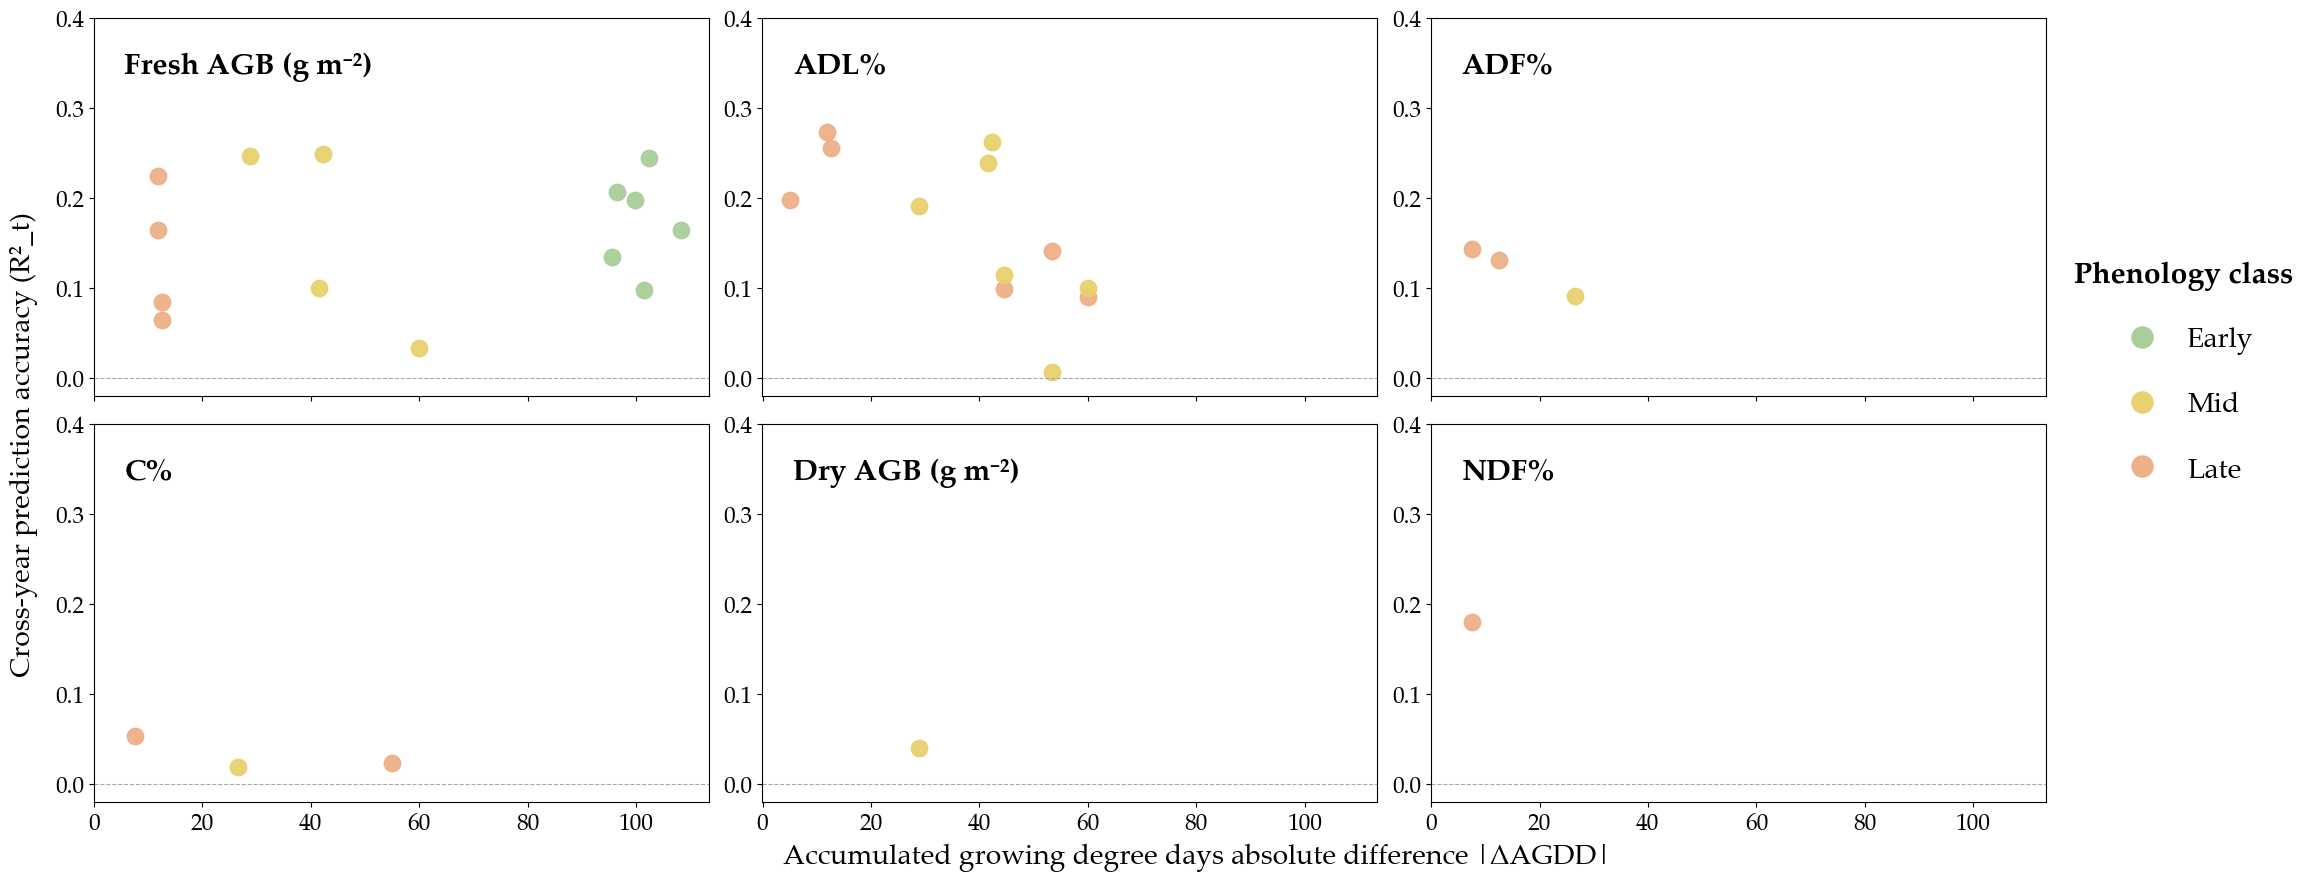

In [75]:
# =========================
# Block 3a&b (AGDD) — Overall relationship between |ΔAGDD| and R²_ext
# ========================= MAIN FIGURE

from itertools import permutations
from matplotlib.ticker import FormatStrFormatter

# -------------------------
# Dynamic Font sizes (your rule)
# -------------------------
base_size = 12  # change if you want (e.g., 10, 11, 13)

def rel(x):
    return base_size * x

plt.rcParams.update({
    "font.family": "palatino linotype",
    "axes.titlesize": rel(1.5),
    "axes.labelsize": rel(1.5),
    "figure.titlesize": rel(1.6),
    "xtick.labelsize": rel(1.4),
    "ytick.labelsize": rel(1.4),
    "legend.fontsize": rel(1.4),
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# -------------------------
# USER CONTROLS (edit here)
# -------------------------
FIGSIZE = (24, 9)

WSPACE = 0.10
HSPACE = 0.8

POINT_SIZE = 140
POINT_ALPHA = 0.95

REFLINE_LW = 0.8
REFLINE_LS = "--"

TEXT_X = 0.05
TRAIT_TEXT_Y = 0.91 # 0.12
CORR_TEXT_Y  = 0.84 # 0.02

TRAIT_FONTSIZE = rel(1.8)
CORR_FONTSIZE  = rel(1.7)
LEGEND_FONTSIZE = rel(1.7)
LEGEND_TITLE_FONTSIZE = rel(1.8)

LEGEND_NCOL = 1
LEGEND_MARKERSIZE = 15

# -------------------------
# Year order
# -------------------------
year_order = [
    "2010","2011","2012","2013",
    "2010-2011","2010-2012","2010-2013","2011-2012","2011-2013","2012-2013",
    "2010-2011-2012","2010-2011-2013","2010-2012-2013","2011-2012-2013"
]

# -------------------------
# Trait labels
# -------------------------
trait_labels = {
    "Biom_dry_g": "Dry AGB (g m⁻²)",
    "Biom_wet_g": "Fresh AGB (g m⁻²)",
    "ADF_perc": "ADF%",
    "ADL_perc": "ADL%",
    "NDF_perc": "NDF%",
    "C_perc": "C%",
    "N_perc": "N%",
}

trait_order = [
    "Fresh AGB (g m⁻²)",
    "ADL%",
    "ADF%",
    "C%",
    "Dry AGB (g m⁻²)", # "N%",
    "NDF%",

]

label_to_internal = {v: k for k, v in trait_labels.items()}

# -------------------------
# Phenology-group colors
# -------------------------
PHENO_COLORS = {
    "Early Phenology": to_rgba("#A9CE9A"),
    "Mid Phenology": to_rgba("#EDB087"),
    "Early-mid Phenology": to_rgba("#E8D16E"),
}

EARLY = {"2010"}

MID = {
    "2011","2012","2013",
    "2011-2012","2011-2013","2012-2013",
    "2011-2012-2013"
}

EARLY_MID = {
    "2010-2011","2010-2012","2010-2013",
    "2010-2011-2012","2010-2011-2013","2010-2012-2013"
}

def year_to_group(y: str) -> str:
    if y in EARLY:
        return "Early Phenology"
    if y in MID:
        return "Mid Phenology"
    if y in EARLY_MID:
        return "Early-mid Phenology"
    return "Other"

def year_to_color(y: str) -> str:
    return PHENO_COLORS.get(year_to_group(y), "#CCCCCC")

# -------------------------
# Build AGDD df
# -------------------------
agdd_df = (
    models_df_expanded
    .assign(
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        AGDD_num=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        abs_AGDD=lambda d: d["AGDD_num"].abs(),
        Year=lambda d: d["Year"].astype(str),
        inVar=lambda d: d["inVar"].astype(str)
    )
    .dropna(subset=["R2_ext_num", "abs_AGDD", "inVar", "Year"])
)

# Keep only positive external R² values
agdd_df = agdd_df[
    (agdd_df["inVar"] != "P_perc") &
    (agdd_df["inVar"] != "N_perc") &
    (agdd_df["R2_ext_num"] > 0)
].copy()

years_present = [y for y in year_order if y in set(agdd_df["Year"])]

# Keep only traits that have at least one positive R²_ext value
trait_order = [        
    label for label in trait_order
    if label_to_internal.get(label) in set(agdd_df["inVar"])
]

# -------------------------
# Exact Spearman p-value for very small sample sizes
# -------------------------
def exact_spearman_p(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    obs = spearmanr(x, y).correlation

    perm_rhos = []
    for yp in permutations(y):
        r = spearmanr(x, yp).correlation
        perm_rhos.append(r)

    perm_rhos = np.asarray(perm_rhos)
    p_exact = np.mean(np.abs(perm_rhos) >= abs(obs))

    return obs, p_exact

# def fmt_p(p):
#     if pd.isna(p):
#         return "NA"
#     return f"{p:.3e}"

# def fmt_p(p):
#     if pd.isna(p):
#         return "NA"
#     return f"{p:.5f}"

# def fmt_p_dynamic(p, max_decimals=15):

#     if pd.isna(p):
#         return "NA"

#     for d in range(3, max_decimals + 1):

#         txt = f"{p:.{d}f}"

#         # Check whether there is any non-zero decimal digit
#         decimals_only = txt.split(".")[1]

#         if any(ch != "0" for ch in decimals_only):
#             return txt

#     # fallback for extremely tiny values
#     return f"{p:.2e}"

def fmt_p_dynamic(p, max_decimals=15):

    if pd.isna(p):
        return "NA"

    # special case for p = 1
    if p == 1:
        return "1"

    for d in range(3, max_decimals + 1):

        txt = f"{p:.{d}f}"

        decimals_only = txt.split(".")[1]

        # stop at first non-zero decimal
        if any(ch != "0" for ch in decimals_only):

            # remove trailing zeros
            txt = txt.rstrip("0").rstrip(".")

            return txt

    # fallback for extremely tiny values
    # NO scientific notation
    return f"{p:.{max_decimals}f}".rstrip("0").rstrip(".")

# -------------------------
# Trait-wise Spearman rho + p for annotations
# -------------------------
trait_stats = {}

for label in trait_order:
    internal = label_to_internal.get(label)
    g = agdd_df[agdd_df["inVar"] == internal]

    if len(g) >= 3:
        x = g["abs_AGDD"].values
        y = g["R2_ext_num"].values

        if len(g) <= 8:
            rho, p = exact_spearman_p(x, y)
        else:
            res = spearmanr(x, y)
            rho = res.correlation
            p = res.pvalue

    else:
        rho, p = np.nan, np.nan

    trait_stats[label] = (rho, p)

# -------------------------
# Plot: 2 rows x 4 cols
# -------------------------
# fig, axes = plt.subplots(2, 4, figsize=FIGSIZE, sharex=True, sharey=False)
fig, axes = plt.subplots(2, 3, figsize=FIGSIZE, sharex=True, sharey=False)
axes = axes.ravel()


for i, label in enumerate(trait_order):
    ax = axes[i]
    internal = label_to_internal[label]
    df_t = agdd_df[agdd_df["inVar"] == internal]

    for y in years_present:
        d = df_t[df_t["Year"] == y]

        if len(d) == 0:
            continue

        ax.scatter(
            d["abs_AGDD"],
            d["R2_ext_num"],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=year_to_color(y)
        )

    ax.axhline(0, linestyle=REFLINE_LS, linewidth=REFLINE_LW, color="darkgray")

    # -------------------------
    # Dynamic y-limits per panel
    # -------------------------
    yvals = df_t["R2_ext_num"]

    if len(yvals) > 0:
        ymin = yvals.min()
        ymax = yvals.max()
        padding = 0.05 * (ymax - ymin if ymax != ymin else 1)

        # ax.set_ylim(ymin - padding, ymax + padding)
        # ax.set_ylim(ymin - padding, 0.4 + padding)
        ax.set_ylim(-0.02, 0.4)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # -------------------------
    # Bottom-left annotations
    # -------------------------
    rho, p = trait_stats[label]

    ax.text(
        TEXT_X, TRAIT_TEXT_Y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top", #bottom
        fontsize=TRAIT_FONTSIZE,
        fontweight="bold"
    )

    # ax.text(
    #     TEXT_X, CORR_TEXT_Y,
    #     # f"Spearman ρ = {rho:.2f}, p = {fmt_p(p)}",
    #     # f"Spearman ρ = {rho:.2f}, p = {fmt_p_dynamic(p)}",
    #     f"Spearman ρ = {'NA' if pd.isna(rho) else f'{rho:.2f}'}, "
    #     f"p = {fmt_p_dynamic(p)}",
    #     transform=ax.transAxes,
    #     ha="left",
    #     va="top", # bottom
    #     fontsize=CORR_FONTSIZE-rel(0.1)
    # )

# # Hide unused axes
# for j in range(len(trait_order), len(axes)):
#     axes[j].set_axis_off()

# # -------------------------
# # Legend panel
# # -------------------------
# # Use first unused axis for legend
# legend_ax = axes[len(trait_order)]
# legend_ax.set_axis_off()

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=LEGEND_MARKERSIZE + rel(0.1),
        markerfacecolor=PHENO_COLORS["Early Phenology"],
        markeredgecolor='none',
        label="Early"
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=LEGEND_MARKERSIZE + rel(0.1),
        markerfacecolor=PHENO_COLORS["Early-mid Phenology"],
        markeredgecolor='none',
        label="Mid"
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markersize=LEGEND_MARKERSIZE + rel(0.1),
        markerfacecolor=PHENO_COLORS["Mid Phenology"],
        markeredgecolor='none',
        label="Late"
    ),
]

fig.legend( #legend_ax
    handles=legend_handles,
    title="Phenology class",
    frameon=False,
    ncol=LEGEND_NCOL,
    fontsize=LEGEND_FONTSIZE,
    loc="center left",
    bbox_to_anchor=(0.855, 0.58),
    # title_fontsize=LEGEND_TITLE_FONTSIZE,
    title_fontproperties={'weight': 'bold', 'size': LEGEND_TITLE_FONTSIZE},
    handletextpad=0.6,
    labelspacing=1.3
)

# -------------------------
# Spacing controls
# -------------------------
fig.subplots_adjust(
    wspace=WSPACE,
    hspace=HSPACE,
    right=0.86
)

# Common axis labels
fig.supxlabel(
    "Accumulated growing degree days absolute difference |ΔAGDD|",
    y=0.025,
    fontsize=LEGEND_TITLE_FONTSIZE - rel(0.1)
)

fig.supylabel(
    "Cross-year prediction accuracy (R²_t)",
    x=0.00555555,
    fontsize=LEGEND_TITLE_FONTSIZE - rel(0.1)
)

# plt.tight_layout()
plt.tight_layout(rect=[0, 0, 0.86, 1])

# # -------------------------
# # Save figure (PNG, 300 dpi & PDF)
# # -------------------------
# fig.savefig(
#     output_path("PPR2_Appendix_FIGURE_AGDD_vs_R2ext_byTrait_Positives.pdf"),
#     bbox_inches="tight",
#     pad_inches=0.05
# )

# fig.savefig(
#     output_path("PPR2_Appendix_FIGURE_AGDD_vs_R2ext_byTrait_Positives.png"),
#     bbox_inches="tight",
#     pad_inches=0.05,
#     dpi=300
# )

plt.show()

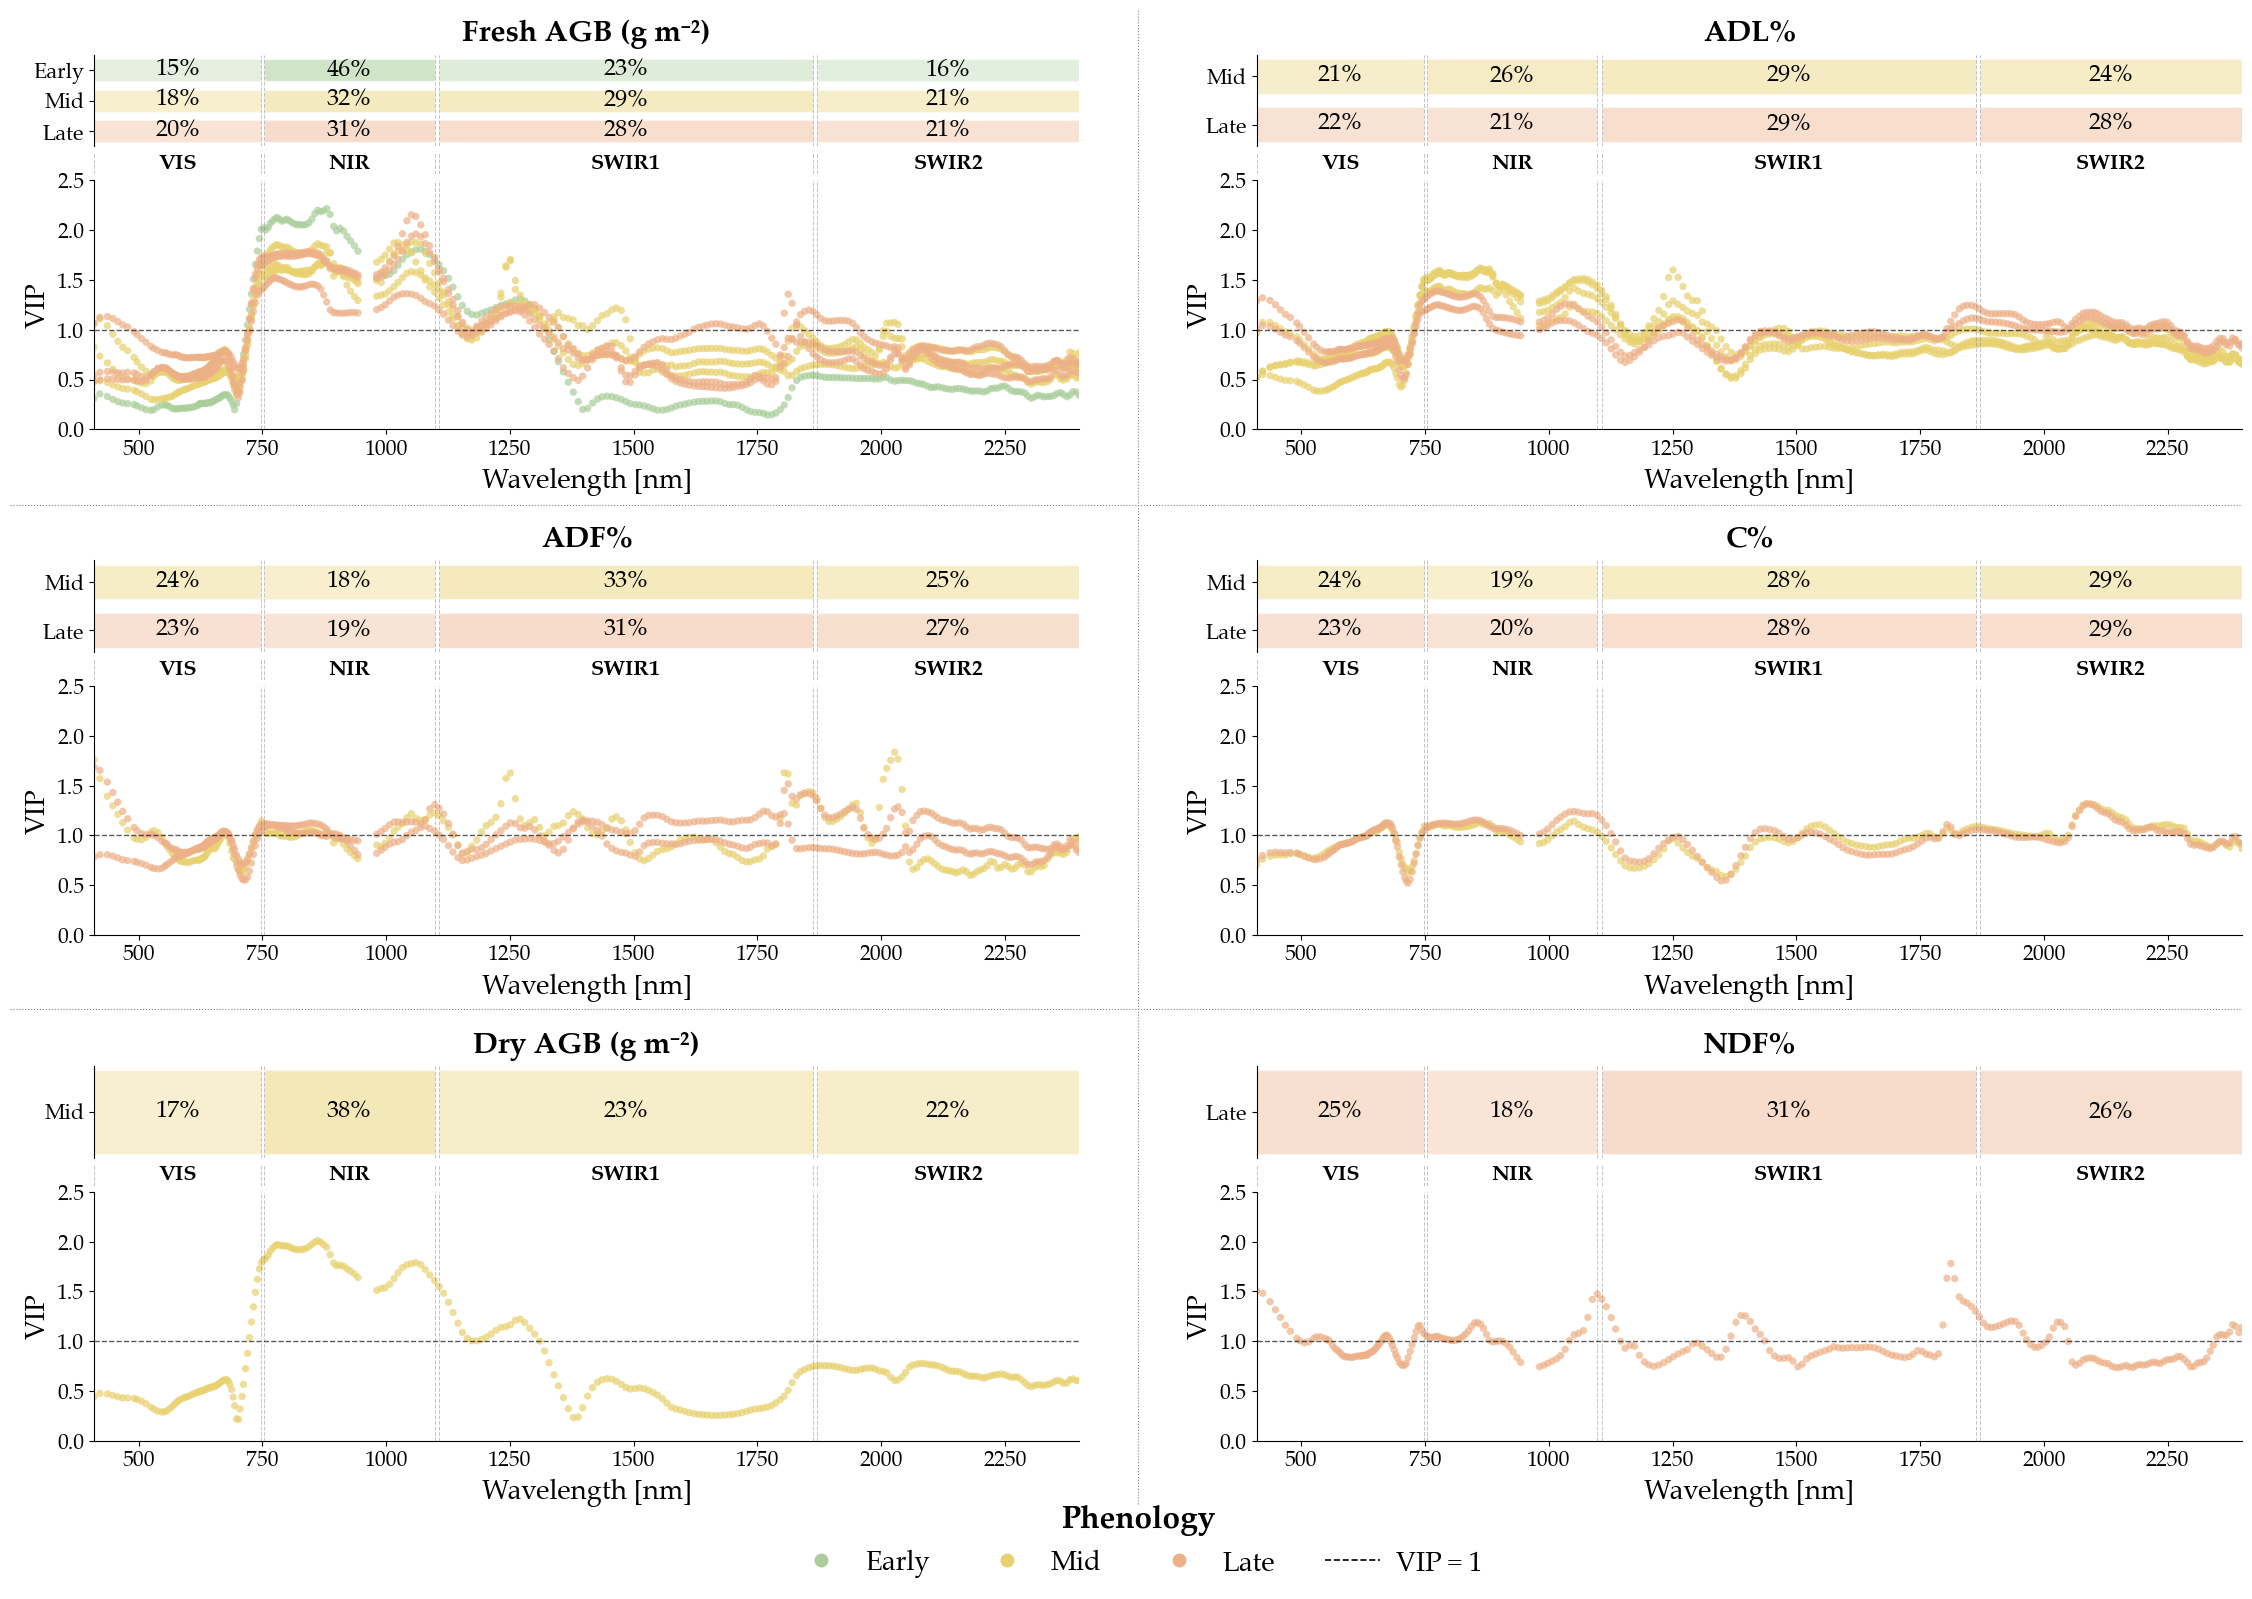

In [76]:
### ENRICHED VIP FIGURE — ALL TRAITS GRID ###
# ============================================================
# Each trait panel:
# Top: regional VIP share (%) by phenology class
# Middle: spectral region labels
# Main: averaged VIP scatter by wavelength and phenology
#
# Layout:
# 2 columns × 4 rows
# Last empty cell used for shared legend
# ============================================================

FIGSIZE = (24, 18)
POINT_SIZE = 28
POINT_ALPHA = 0.70

# -------------------------
# Figure font scaling
# -------------------------
base_size = 12

def rel(x):
    return base_size * (x + 0.3)

# PHENO_COLORS_SHORT = {
#     "Early": "#A9CE9A",
#     "Early–mid": "#E8D16E",
#     "Mid": "#EDB087",
# }

PHENO_COLORS_SHORT = {
    "early": "#A9CE9A",
    "mid": "#E8D16E",
    "late": "#EDB087",
}

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

# MAIN FIGURE TRAIT ORDER
trait_order_codes = [
    "Biom_wet_g",
    "ADL_perc",
    "ADF_perc",
    "C_perc",
    "Biom_dry_g", #"N_perc",
    "NDF_perc",
]

trait_order_labels = [
    trait_labels_pub[t] for t in trait_order_codes
]

# -------------------------
# Build long VIP table for all selected traits
# -------------------------
vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)

    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    if trait_val not in trait_order_codes:
        continue

    phen_group = phenology_group(year_val)
    trait_label = trait_labels_pub[trait_val]

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)
    vips = pd.read_csv(vips_file).drop(columns=["Unnamed: 0"], errors="ignore")

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]
    if not vip_cols:
        continue

    X = vips[vip_cols].apply(pd.to_numeric, errors="coerce")
    vip_mean_by_wvl = X.mean(axis=0)

    for col in vip_cols:
        wvl = float(col)
        region = spectral_region(wvl)

        if pd.isna(region):
            continue

        vip_rows.append({
            "Year": year_val,
            "inVar": trait_val,
            "Trait_label": trait_label,
            "Phenology": phen_group,
            "Wavelength": wvl,
            "Region": region,
            "VIP": float(vip_mean_by_wvl[col])
        })

vip_long_all = pd.DataFrame(vip_rows)

vip_long_all["Phenology"] = vip_long_all["Phenology"].replace({
    "Early": "early",
    "Mid": "late",
    "Early–mid": "mid",
    "Early-mid": "mid"   # included in case your dash is different
})

# # Keep only convergent / retained models from models_df_expanded
# valid_model_keys = models_df_expanded[["Year", "inVar"]].drop_duplicates()

# Keep only models with positive R2_ext
valid_model_keys = (
    models_df_expanded[models_df_expanded["R2_ext"] > 0]
    [["Year", "inVar"]]
    .drop_duplicates()
)

vip_long_all = vip_long_all.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

vip_long_all["Phenology"] = pd.Categorical(
    vip_long_all["Phenology"],
    categories=phenology_order,
    ordered=True
)

vip_long_all["Trait_label"] = pd.Categorical(
    vip_long_all["Trait_label"],
    categories=trait_order_labels,
    ordered=True
)

vip_long_all = vip_long_all.sort_values(
    ["Trait_label", "Phenology", "Year", "Wavelength"]
)

# -------------------------
# Helper for transparency
# -------------------------
def pct_to_alpha(pct, min_alpha=0.20, max_alpha=0.95):
    return min_alpha + (max_alpha - min_alpha) * (pct / 100)

# # Phenology dictionary
# PHENO_LABELS_VISUAL = {
#     "Early": "early",
#     "Early–mid": "mid",
#     "Mid": "late",
# }

PHENO_LABELS_VISUAL = {
    "early": "Early",
    "mid": "Mid",
    "late": "Late",
}

# -------------------------
# Helper to draw one trait panel
# -------------------------
def draw_trait_panel(fig, outer_spec, trait_code, trait_label):

    subgs = outer_spec.subgridspec(
        nrows=3,
        ncols=1,
        height_ratios=[1.25, 0.30, 3.4],
        hspace=0.05
    )

    ax_top = fig.add_subplot(subgs[0, 0])
    ax_region = fig.add_subplot(subgs[1, 0], sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2, 0], sharex=ax_top)

    vip_trait = vip_long_all[vip_long_all["inVar"] == trait_code].copy()

    if vip_trait.empty:
        ax_main.text(
            0.5, 0.5,
            f"No data for {trait_label}",
            ha="center",
            va="center",
            transform=ax_main.transAxes
        )
        return ax_top, ax_region, ax_main

    active_phenology_order = [
        ph for ph in phenology_order
        if ph in vip_trait["Phenology"].dropna().astype(str).unique()
    ]

    # -------------------------
    # Regional VIP percentage
    # -------------------------
    share_df = (
        vip_trait
        .groupby(["Phenology", "Region"], observed=True)["VIP"]
        .sum()
        .reset_index()
    )

    share_df["Region"] = pd.Categorical(
        share_df["Region"],
        categories=region_order,
        ordered=True
    )

    share_df["Phenology"] = pd.Categorical(
        share_df["Phenology"],
        categories=active_phenology_order,
        ordered=True
    )

    share_df["Total"] = share_df.groupby("Phenology", observed=True)["VIP"].transform("sum")
    share_df["VIP_pct"] = (share_df["VIP"] / share_df["Total"]) * 100

    share_wide = (
        share_df
        .pivot(index="Phenology", columns="Region", values="VIP_pct")
        .reindex(active_phenology_order)
        .fillna(0)
    )
    
    # print(trait_label)
    # print(share_wide)
    # print("Row sums:", share_wide.sum(axis=1))
    
    share_wide_int = share_wide.copy()

    for idx in share_wide.index:
        vals = share_wide.loc[idx].values

        ints = np.floor(vals).astype(int)
        remainder = 100 - ints.sum()

        order = np.argsort(vals - ints)[::-1]

        ints[order[:remainder]] += 1

        share_wide_int.loc[idx] = ints

    # -------------------------
    # Shared wavelength boundaries
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        for reg, (x0, x1) in REGION_BANDS.items():
            ax.axvline(x0, color="grey", lw=0.75, ls="--", alpha=0.45)
            ax.axvline(x1, color="grey", lw=0.75, ls="--", alpha=0.45)

    # -------------------------
    # Top percentage bars
    # -------------------------
    bar_height = 0.72
    y_positions = np.arange(len(active_phenology_order))

    for i, ph in enumerate(active_phenology_order):

        for reg in region_order:

            if reg not in share_wide.columns:
                continue

            # pct = float(share_wide.loc[ph, reg])
            pct = float(share_wide_int.loc[ph, reg])

            if pct <= 0:
                continue

            x0, x1 = REGION_BANDS[reg]
            width = x1 - x0

            ax_top.barh(
                y=i,
                width=width,
                left=x0,
                height=bar_height,
                color=PHENO_COLORS_SHORT[ph],
                alpha=pct_to_alpha(pct),
                edgecolor="white",
                linewidth=1.0
            )

            ax_top.text(
                x0 + width / 2,
                i,
                f"{pct:.0f}%",
                # f"{pct:.1f}%",
                ha="center",
                va="center",
                fontsize=rel(1.15)
            )

    ax_top.set_yticks(y_positions)
    # ax_top.set_yticklabels(active_phenology_order, fontsize=rel(1.0), rotation = 45)
    ax_top.set_yticklabels(
    [PHENO_LABELS_VISUAL[ph] for ph in active_phenology_order],
    fontsize=rel(1.0) ,
    # rotation=45
    )
    ax_top.invert_yaxis()
    ax_top.set_xlim(410, 2400)
    # TITLE FONTSIZE
    ax_top.set_title(trait_label, fontsize=rel(1.5), fontweight="bold", pad=10)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

    # -------------------------
    # Middle spectral-region labels
    # -------------------------
    ax_region.set_ylim(0, 1)
    ax_region.set_yticks([])

    for reg, (x0, x1) in REGION_BANDS.items():
        ax_region.text(
            (x0 + x1) / 2,
            0.5,
            reg,
            ha="center",
            va="center",
            fontsize=rel(1.0),
            fontweight="bold"
        )

    ax_region.tick_params(axis="x", bottom=False, labelbottom=False)

    # -------------------------
    # Main VIP scatter
    # -------------------------
    for ph in active_phenology_order:
        d = vip_trait[vip_trait["Phenology"].astype(str) == ph]

        ax_main.scatter(
            d["Wavelength"],
            d["VIP"],
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=PHENO_COLORS_SHORT[ph],
            edgecolor="none",
            # label=ph
            label=PHENO_LABELS_VISUAL[ph]
        )

    ax_main.axhline(1, color="black", lw=1.0, ls="--", alpha=0.65)

    ax_main.set_xlim(410, 2400)
    ax_main.set_xlabel("Wavelength [nm]", fontsize=rel(1.35), labelpad=5)
    ax_main.set_ylim(0, 2.5)
    ax_main.set_ylabel("VIP", fontsize=rel(1.35))
    ax_main.tick_params(axis="both", labelsize=rel(1.0))

    # -------------------------
    # Styling
    # -------------------------
    for ax in [ax_top, ax_region, ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)

    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

    return ax_top, ax_region, ax_main

# -------------------------
# Figure layout: 4 rows × 2 columns
# -------------------------
fig = plt.figure(figsize=FIGSIZE)

outer_gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    wspace=0.18,
    hspace=0.35 # vertical spacing
)

# Draw 7 trait panels
for idx, trait_code in enumerate(trait_order_codes):

    row = idx // 2
    col = idx % 2

    trait_label = trait_labels_pub[trait_code]

    draw_trait_panel(
        fig=fig,
        outer_spec=outer_gs[row, col],
        trait_code=trait_code,
        trait_label=trait_label
    )

# -------------------------
# Last empty cell: shared legend
# -------------------------
# -------------------------
# Shared legend at bottom center
# -------------------------
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=10,
        markerfacecolor=PHENO_COLORS_SHORT[ph],
        markeredgecolor="none",
        label=PHENO_LABELS_VISUAL[ph]
    )
    for ph in phenology_order
]

vip_line = Line2D(
    [0], [0],
    color="black",
    lw=1.2,
    ls="--",
    label="VIP = 1"
)

fig.legend(
    handles=legend_handles + [vip_line],
    title="Phenology",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.44, 0.02),
    ncol=4,
    fontsize=rel(1.35),
    title_fontproperties={'weight': 'bold', 'size': rel(1.6)},
    columnspacing=1.8,
    handletextpad=0.6
)
# ax_legend = fig.add_subplot(outer_gs[3, 1])
# ax_legend.axis("off")

# legend_handles = [
#     Line2D(
#         [0], [0],
#         marker="o",
#         linestyle="None",
#         markersize=10,
#         markerfacecolor=PHENO_COLORS_SHORT[ph],
#         markeredgecolor="none",
#         # label=ph
#         label=PHENO_LABELS_VISUAL[ph]
#     )
#     for ph in phenology_order
# ]

# vip_line = Line2D(
#     [0], [0],
#     color="black",
#     lw=1.2,
#     ls="--",
#     label="VIP = 1"
# )

# ax_legend.legend(
#     handles=legend_handles + [vip_line],
#     title="Phenology",
#     frameon=False,
#     loc="center bottom", #center left #center #upper left
#     fontsize=rel(1.35),
#     title_fontproperties={'weight': 'bold', 'size': rel(1.6)},
#     # title_fontsize=rel(1.6),
#     labelspacing=1.3
# )

# -------------------------
# Figure title
# -------------------------
# fig.suptitle(
#     "Regional VIP share and wavelength-level VIP distribution of trait models across phenology classes",
#     fontsize=rel(1.7),
#     y=0.915
# )

from matplotlib.lines import Line2D

# ============================================================
# Grid separators (light gray dotted lines)
# ============================================================
# Coordinates are in figure units:
# x = 0 is far left of the whole figure, x = 1 is far right
# y = 0 is bottom of the whole figure, y = 1 is top

# ============================================================
# Grid separators
# ============================================================

# -------------------------
# Vertical separator between the 2 columns
# -------------------------
fig.add_artist(
    Line2D(
        [0.44, 0.44],   # x position of the vertical line
                        # smaller = move LEFT
                        # larger = move RIGHT

        [0.075, 0.905],   # vertical line length = [bottom, top]
                        # first value  -> raises/lowers START of line
                        # second value -> raises/lowers END of line

        transform=fig.transFigure,

        color="gray",
        lw=0.8,         # line thickness
        ls=":"          # dotted line
    )
)

# -------------------------
# Horizontal separators between trait rows
# -------------------------
# Each y value controls vertical placement of one separator
# larger y = higher line
# smaller y = lower line

for y in [0.63, 0.35]:

    fig.add_artist(
        Line2D(
            [-0.03, 0.90],   # horizontal line length = [left, right]
                             # first value  -> where line STARTS
                             # second value -> where line ENDS

            [y, y],         # y position of separator

            transform=fig.transFigure,

            color="gray",
            lw=0.8,         # line thickness
            ls=":"          # dotted line
        )
    )

# plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.tight_layout(rect=[0, 0.04, 1, 0.985])
fig.subplots_adjust(left=0.005)

# # -------------------------
# # Save figure (PNG, 300 dpi & PDF)
# # -------------------------
# # pad_inches trims excess outer whitespace without altering any figure element(s)
# fig.savefig(output_path("PPR2_FIGURE_2_VIPS_vs_Trait-Phenology-Years-neu-all-transferred-traits.pdf"), bbox_inches="tight", pad_inches=0.05)
# fig.savefig(output_path("PPR2_FIGURE_2_VIPS_vs_Trait-Phenology-Years-neu-all-transferred-traits.png"), bbox_inches="tight", pad_inches=0.05, dpi=300)

plt.show()

In [77]:
### APPENDIX VIP TABLE — SINGLE-YEAR vs MULTI-YEAR RETAINED MODELS ###
# ============================================================
# Table:
# Trait | Model type | Phenology | VIS (%) | NIR (%) | SWIR1 (%) | SWIR2 (%)
#
# Model selection:
# Model_Type == "Single_Year"   -> Single-year
# Model_Type == "Combined_Year" -> Multi-year
#
# Retained models:
# Iter_R2_iqr <= 0.5   # change to 0.2 if needed
# R2 >= 0
#
# No R2_ext filtering
# ============================================================

import re
import numpy as np
import pandas as pd

MODEL_TYPE_LABELS = {
    "Single_Year": "Single-year",
    "Combined_Year": "Multi-year",
}

calib_type_order = ["Single-year", "Multi-year"]

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

trait_order_codes = [
    "Biom_wet_g",
    "ADL_perc",
    "Biom_dry_g",
    "ADF_perc",
    "C_perc",
    "N_perc",
    "NDF_perc",
]

trait_order_labels = [
    trait_labels_pub[t] for t in trait_order_codes
]

PHENO_LABELS_VISUAL = {
    "Early": "early",
    "Early–mid": "mid",
    "Mid": "late",
}

# ============================================================
# Build long VIP table from folders
# ============================================================

vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)

    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    if trait_val not in trait_order_codes:
        continue

    phen_group = phenology_group(year_val)
    trait_label = trait_labels_pub[trait_val]

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)

    vips = (
        pd.read_csv(vips_file)
        .drop(columns=["Unnamed: 0"], errors="ignore")
    )

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]

    if not vip_cols:
        continue

    X = vips[vip_cols].apply(pd.to_numeric, errors="coerce")
    vip_mean_by_wvl = X.mean(axis=0)

    for col in vip_cols:

        wvl = float(col)
        region = spectral_region(wvl)

        if pd.isna(region):
            continue

        vip_rows.append({
            "Year": year_val,
            "inVar": trait_val,
            "Trait": trait_label,
            "Phenology_raw": phen_group,
            "Phenology": PHENO_LABELS_VISUAL.get(phen_group, phen_group),
            "Wavelength": wvl,
            "Region": region,
            "VIP": float(vip_mean_by_wvl[col])
        })

vip_long_all = pd.DataFrame(vip_rows)

# ============================================================
# Select retained models from models_df_expanded
# ============================================================

models_for_vip = models_df_expanded.copy()

models_for_vip["Year"] = (
    models_for_vip["Year"]
    .astype(str)
    .str.replace("&", "-", regex=False)
)

models_for_vip["Iter_R2_iqr"] = pd.to_numeric(
    models_for_vip["Iter_R2_iqr"],
    errors="coerce"
)

models_for_vip["R2"] = pd.to_numeric(
    models_for_vip["R2"],
    errors="coerce"
)

# valid_model_keys = (
#     models_for_vip[
#         (models_for_vip["Model_Type"].isin(["Single_Year", "Combined_Year"])) &
#         (models_for_vip["Iter_R2_iqr"] <= 0.5) &   # use 0.2 if that is final
#         (models_for_vip["R2"] >= 0)
#     ]
#     [["Year", "inVar", "Model_Type"]]
#     .drop_duplicates()
# )

# # Keep only models with positive R2_ext
# valid_model_keys = (
#     models_df_expanded[models_df_expanded["R2_ext"] > 0]
#     [["Year", "inVar"]]
#     .drop_duplicates()
# )

models_for_vip["R2_ext"] = pd.to_numeric(
    models_for_vip["R2_ext"],
    errors="coerce"
)

valid_model_keys = (
    models_for_vip[
        (models_for_vip["Model_Type"].isin(["Single_Year", "Combined_Year"])) &
        (models_for_vip["Iter_R2_iqr"] <= 0.5) &
        (models_for_vip["R2_ext"] > 0)
    ]
    [["Year", "inVar", "Model_Type"]]
    .drop_duplicates()
)

valid_model_keys["Model type"] = valid_model_keys["Model_Type"].map(MODEL_TYPE_LABELS)

valid_model_keys = valid_model_keys.drop(columns="Model_Type")

# Merge retained model information into VIP table
vip_long_all = vip_long_all.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

# ============================================================
# Calculate regional VIP contribution percentages
# ============================================================

vip_region_sum = (
    vip_long_all
    .groupby(
        ["Trait", "inVar", "Model type", "Phenology_raw", "Phenology", "Region"],
        observed=True
    )["VIP"]
    .sum()
    .reset_index()
)

vip_region_sum["Total VIP"] = (
    vip_region_sum
    .groupby(
        ["Trait", "inVar", "Model type", "Phenology_raw", "Phenology"],
        observed=True
    )["VIP"]
    .transform("sum")
)

vip_region_sum["VIP contribution (%)"] = (
    vip_region_sum["VIP"] / vip_region_sum["Total VIP"] * 100
)

vip_table = (
    vip_region_sum
    .pivot_table(
        index=["Trait", "inVar", "Model type", "Phenology_raw", "Phenology"],
        columns="Region",
        values="VIP contribution (%)",
        fill_value=0,
        observed=True
    )
    .reset_index()
)

# Ensure region columns exist and order them
for reg in region_order:
    if reg not in vip_table.columns:
        vip_table[reg] = 0

vip_table = vip_table[
    ["Trait", "inVar", "Model type", "Phenology_raw", "Phenology"] + region_order
]

# ============================================================
# Sorting
# ============================================================

vip_table["Trait"] = pd.Categorical(
    vip_table["Trait"],
    categories=trait_order_labels,
    ordered=True
)

vip_table["Model type"] = pd.Categorical(
    vip_table["Model type"],
    categories=calib_type_order,
    ordered=True
)

vip_table["Phenology_raw"] = pd.Categorical(
    vip_table["Phenology_raw"],
    categories=phenology_order,
    ordered=True
)

vip_table = vip_table.sort_values(
    ["Trait", "Model type", "Phenology_raw"]
)

# ============================================================
# Format final table
# ============================================================

vip_table_final = vip_table.copy()

vip_table_final = vip_table_final.rename(columns={
    "VIS": "VIS (%)",
    "NIR": "NIR (%)",
    "SWIR1": "SWIR1 (%)",
    "SWIR2": "SWIR2 (%)",
})

vip_table_final = vip_table_final[
    ["Trait", "Model type", "Phenology", "VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]
]

# print(vip_table[region_order].sum(axis=1).round(10))

# for col in ["VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]:
#     vip_table_final[col] = vip_table_final[col].round(0).astype(int)

for idx in vip_table_final.index:

    vals = vip_table.loc[idx, region_order].values

    ints = np.floor(vals).astype(int)

    remainder = 100 - ints.sum()

    order = np.argsort(vals - ints)[::-1]

    ints[order[:remainder]] += 1

    vip_table_final.loc[idx, ["VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]] = ints

# # Optional: add row total check
# vip_table_final["Total (%)"] = (
#     vip_table_final[["VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]]
#     .sum(axis=1)
# )

# # ============================================================
# # Save as CSV
# # ============================================================
# csv_name = "PPR2_APPENDIX_Table_VIP_region_contributions_single_vs_multi_positive_R2_t_models.csv"
# vip_table_final.to_csv(
#     output_path(csv_name),
#     index=False
# )
# print(f"Saved CSV:  {output_path(csv_name)}")

# Display table
display(vip_table_final)

# print(
#     vip_table_final[["VIS (%)", "NIR (%)", "SWIR1 (%)", "SWIR2 (%)"]]
#     .sum(axis=1)
# )

Region,Trait,Model type,Phenology,VIS (%),NIR (%),SWIR1 (%),SWIR2 (%)
10,Fresh AGB (g m⁻²),Single-year,early,15.0000,46.0000,23.0000,16.0000
11,Fresh AGB (g m⁻²),Single-year,late,21.0000,29.0000,29.0000,21.0000
8,Fresh AGB (g m⁻²),Multi-year,mid,18.0000,32.0000,29.0000,21.0000
9,Fresh AGB (g m⁻²),Multi-year,late,20.0000,34.0000,25.0000,21.0000
4,ADL%,Single-year,late,21.0000,23.0000,28.0000,28.0000
2,ADL%,Multi-year,mid,21.0000,26.0000,29.0000,24.0000
3,ADL%,Multi-year,late,23.0000,20.0000,29.0000,28.0000
7,Dry AGB (g m⁻²),Multi-year,mid,17.0000,38.0000,23.0000,22.0000
0,ADF%,Multi-year,mid,24.0000,18.0000,33.0000,25.0000
1,ADF%,Multi-year,late,23.0000,19.0000,31.0000,27.0000


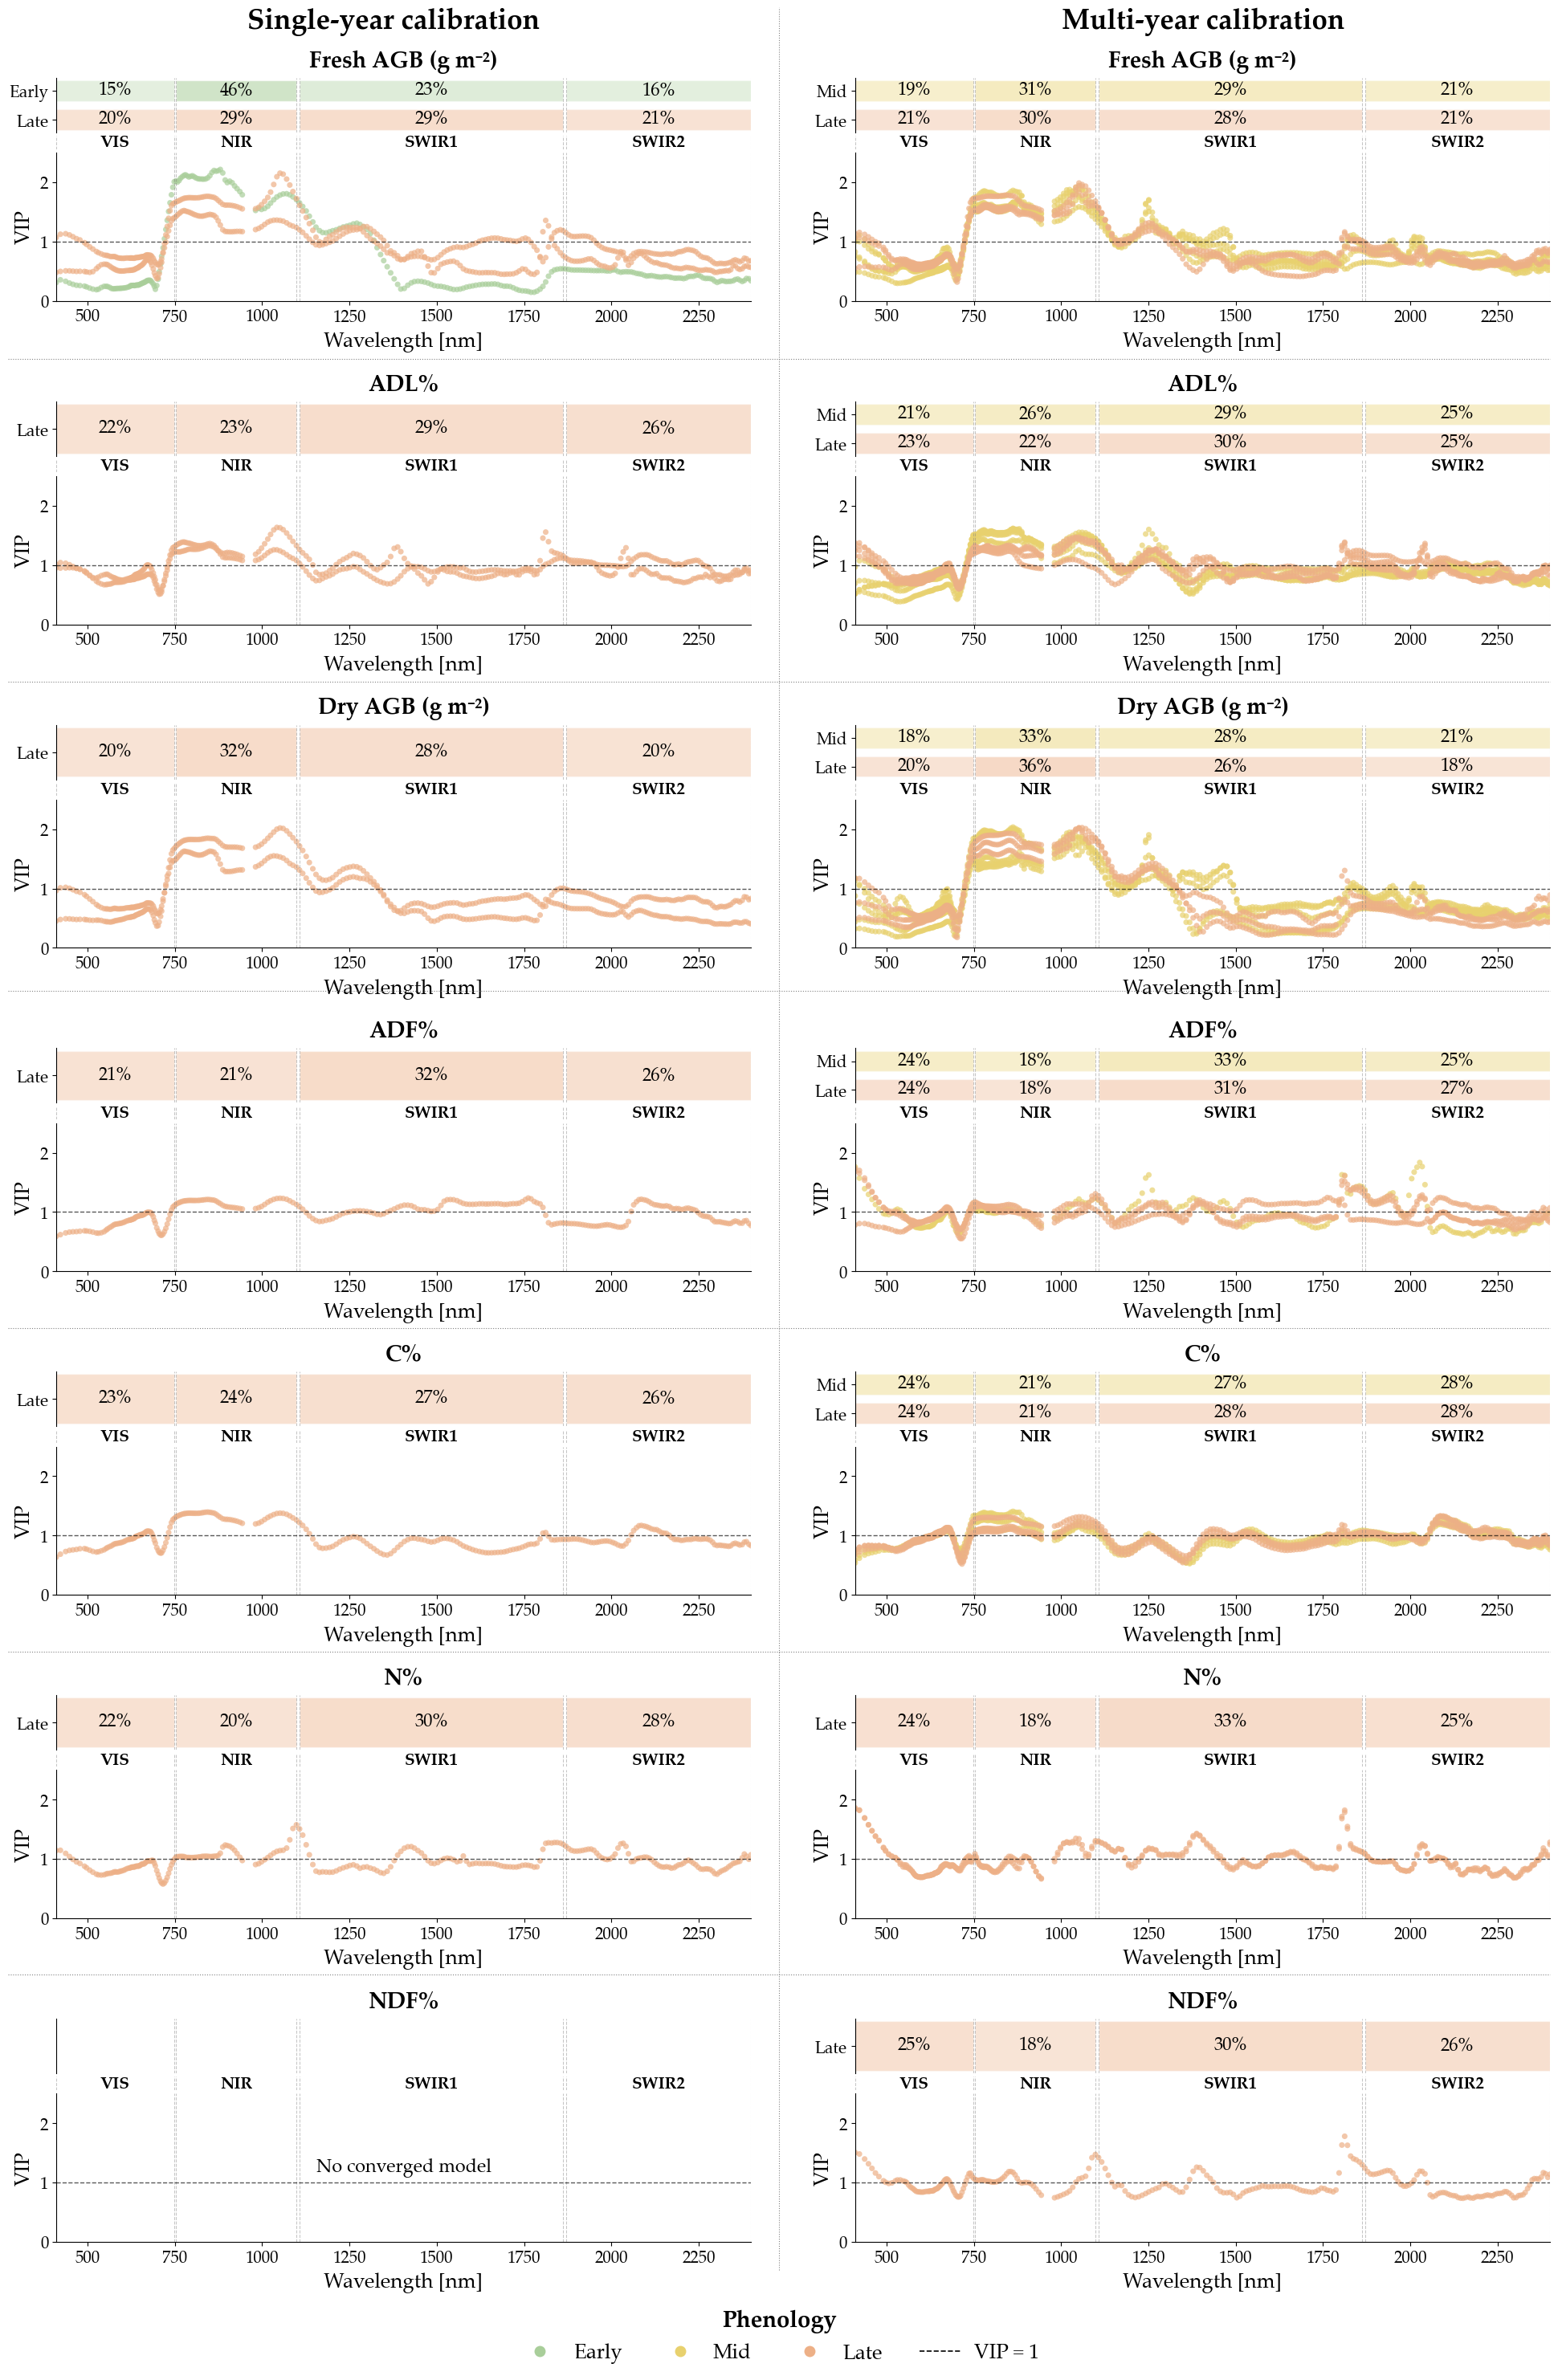

In [78]:
### APPENDIX VIP FIGURE — SINGLE-YEAR vs MULTI-YEAR RETAINED MODELS ###
# ============================================================
# Layout:
# 6 rows × 2 columns
# Rows    = traits
# Columns = Single-year vs Multi-year models
#
# Model selection:
# Model_Type == "Single_Year"   -> Single-year
# Model_Type == "Combined_Year" -> Multi-year
#
# Retained models:
# Iter_R2_iqr <= 0.2
# R2 >= 0
#
# No R2_ext filtering
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIGSIZE = (24, 35)
POINT_SIZE = 26
POINT_ALPHA = 0.70

base_size = 12

def rel(x):
    return base_size * (x + 0.3)

# PHENO_COLORS_SHORT = {
#     "Early": "#A9CE9A",
#     "Early–mid": "#E8D16E",
#     "Mid": "#EDB087",
# }

# PHENO_LABELS_VISUAL = {
#     "Early": "Early",
#     "Early–mid": "Mid",
#     "Mid": "Late",
# }

PHENO_COLORS_SHORT = {
    "early": "#A9CE9A",
    "mid": "#E8D16E",
    "late": "#EDB087",
}

PHENO_LABELS_VISUAL = {
    "early": "Early",
    "mid": "Mid",
    "late": "Late",
}

MODEL_TYPE_LABELS = {
    "Single_Year": "Single-year",
    "Combined_Year": "Multi-year",
}

calib_type_order = ["Single-year", "Multi-year"]

REGION_BANDS = {
    "VIS":   (410, 748),
    "NIR":   (753, 1098),
    "SWIR1": (1107, 1862),
    "SWIR2": (1870, 2400),
}

trait_order_codes = [
    "Biom_wet_g",
    "ADL_perc",
    "Biom_dry_g",
    "ADF_perc",
    "C_perc",
    "N_perc",
    "NDF_perc",
]

trait_order_labels = [
    trait_labels_pub[t] for t in trait_order_codes
]

# ============================================================
# Build VIP table from folders
# ============================================================

vip_rows = []

for folder in [p for p in root.iterdir() if p.is_dir()]:

    year_val, trait_val = parse_folder_name(folder.name)

    if year_val is None or trait_val is None:
        continue

    year_val = str(year_val).replace("&", "-")

    if trait_val not in trait_order_codes:
        continue

    phen_group = phenology_group(year_val)
    trait_label = trait_labels_pub[trait_val]

    vips_files = list(folder.glob("*REF_DF_MODELs*-VIPS.csv"))
    if not vips_files:
        continue

    vips_file = max(vips_files, key=iter_n)

    vips = (
        pd.read_csv(vips_file)
        .drop(columns=["Unnamed: 0"], errors="ignore")
    )

    vip_cols = [c for c in vips.columns if re.fullmatch(r"\d+", str(c))]

    if not vip_cols:
        continue

    X = vips[vip_cols].apply(pd.to_numeric, errors="coerce")
    vip_mean_by_wvl = X.mean(axis=0)

    for col in vip_cols:

        wvl = float(col)
        region = spectral_region(wvl)

        if pd.isna(region):
            continue

        vip_rows.append({
            "Year": year_val,
            "inVar": trait_val,
            "Trait_label": trait_label,
            "Phenology": phen_group,
            "Wavelength": wvl,
            "Region": region,
            "VIP": float(vip_mean_by_wvl[col])
        })

vip_long_all = pd.DataFrame(vip_rows)

vip_long_all["Phenology"] = vip_long_all["Phenology"].replace({
    "Early": "early",
    "Mid": "late",
    "Early–mid": "mid",
    "Early-mid": "mid"   # included in case your dash is different
})

# ============================================================
# Select retained models from models_df_expanded
# ============================================================

models_for_vip = models_df_expanded.copy()

models_for_vip["Year"] = (
    models_for_vip["Year"]
    .astype(str)
    .str.replace("&", "-", regex=False)
)

models_for_vip["Iter_R2_iqr"] = pd.to_numeric(
    models_for_vip["Iter_R2_iqr"],
    errors="coerce"
)

models_for_vip["R2"] = pd.to_numeric(
    models_for_vip["R2"],
    errors="coerce"
)

valid_model_keys = (
    models_for_vip[
        (models_for_vip["Model_Type"].isin(["Single_Year", "Combined_Year"])) &
        (models_for_vip["Iter_R2_iqr"] <= 0.5) & #0.2
        (models_for_vip["R2"] >= 0)
    ]
    [["Year", "inVar", "Model_Type"]]
    .drop_duplicates()
)

valid_model_keys["Calibration_type"] = valid_model_keys["Model_Type"].map(MODEL_TYPE_LABELS)

valid_model_keys = valid_model_keys.drop(columns="Model_Type")

# Merge retained model information into VIP table
vip_long_all = vip_long_all.merge(
    valid_model_keys,
    on=["Year", "inVar"],
    how="inner"
)

vip_long_all["Phenology"] = pd.Categorical(
    vip_long_all["Phenology"],
    categories=phenology_order,
    ordered=True
)

vip_long_all["Trait_label"] = pd.Categorical(
    vip_long_all["Trait_label"],
    categories=trait_order_labels,
    ordered=True
)

vip_long_all["Calibration_type"] = pd.Categorical(
    vip_long_all["Calibration_type"],
    categories=calib_type_order,
    ordered=True
)

vip_long_all = vip_long_all.sort_values(
    ["Trait_label", "Calibration_type", "Phenology", "Year", "Wavelength"]
)

# ============================================================
# Helpers
# ============================================================

def pct_to_alpha(pct, min_alpha=0.20, max_alpha=0.95):
    return min_alpha + (max_alpha - min_alpha) * (pct / 100)


def draw_trait_calib_panel(fig, outer_spec, trait_code, trait_label, calib_type):

    subgs = outer_spec.subgridspec(
        nrows=3,
        ncols=1,
        height_ratios=[1.25, 0.30, 3.4],
        hspace=0.05
    )

    ax_top = fig.add_subplot(subgs[0, 0])
    ax_region = fig.add_subplot(subgs[1, 0], sharex=ax_top)
    ax_main = fig.add_subplot(subgs[2, 0], sharex=ax_top)

    vip_trait = vip_long_all[
        (vip_long_all["inVar"] == trait_code) &
        (vip_long_all["Calibration_type"] == calib_type)
    ].copy()

    for ax in [ax_top, ax_region, ax_main]:
        for reg, (x0, x1) in REGION_BANDS.items():
            ax.axvline(x0, color="grey", lw=0.75, ls="--", alpha=0.45)
            ax.axvline(x1, color="grey", lw=0.75, ls="--", alpha=0.45)

    ax_top.set_xlim(410, 2400)
    ax_region.set_xlim(410, 2400)
    ax_main.set_xlim(410, 2400)
    ax_main.set_ylim(0, 2.5)

    if vip_trait.empty:
        ax_main.text(
            0.5, 0.5,
            "No converged model",
            ha="center",
            va="center",
            fontsize=rel(1.1),
            transform=ax_main.transAxes
        )

        ax_top.set_title(trait_label, fontsize=rel(1.4), fontweight="bold", pad=10)
        ax_top.set_yticks([])
        ax_region.set_yticks([])

    else:
        active_phenology_order = [
            ph for ph in phenology_order
            if ph in vip_trait["Phenology"].dropna().astype(str).unique()
        ]

        share_df = (
            vip_trait
            .groupby(["Phenology", "Region"], observed=True)["VIP"]
            .sum()
            .reset_index()
        )

        share_df["Region"] = pd.Categorical(
            share_df["Region"],
            categories=region_order,
            ordered=True
        )

        share_df["Phenology"] = pd.Categorical(
            share_df["Phenology"],
            categories=active_phenology_order,
            ordered=True
        )

        share_df["Total"] = (
            share_df
            .groupby("Phenology", observed=True)["VIP"]
            .transform("sum")
        )

        share_df["VIP_pct"] = (share_df["VIP"] / share_df["Total"]) * 100

        share_wide = (
            share_df
            .pivot(index="Phenology", columns="Region", values="VIP_pct")
            .reindex(active_phenology_order)
            .fillna(0)
        )

        y_positions = np.arange(len(active_phenology_order))
        bar_height = 0.72

        for i, ph in enumerate(active_phenology_order):

            for reg in region_order:

                if reg not in share_wide.columns:
                    continue

                pct = float(share_wide.loc[ph, reg])

                if pct <= 0:
                    continue

                x0, x1 = REGION_BANDS[reg]
                width = x1 - x0

                ax_top.barh(
                    y=i,
                    width=width,
                    left=x0,
                    height=bar_height,
                    color=PHENO_COLORS_SHORT[ph],
                    alpha=pct_to_alpha(pct),
                    edgecolor="white",
                    linewidth=1.0
                )

                ax_top.text(
                    x0 + width / 2,
                    i,
                    f"{pct:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=rel(1.05)
                )

        ax_top.set_yticks(y_positions)
        ax_top.set_yticklabels(
            [PHENO_LABELS_VISUAL[ph] for ph in active_phenology_order],
            fontsize=rel(0.95) #,
            # rotation=45
        )
        ax_top.invert_yaxis()
        ax_top.set_title(trait_label, fontsize=rel(1.4), fontweight="bold", pad=10)

        for ph in active_phenology_order:
            d = vip_trait[vip_trait["Phenology"].astype(str) == ph]

            ax_main.scatter(
                d["Wavelength"],
                d["VIP"],
                s=POINT_SIZE,
                alpha=POINT_ALPHA,
                color=PHENO_COLORS_SHORT[ph],
                edgecolor="none",
                label=PHENO_LABELS_VISUAL[ph]
            )

    # Spectral region labels
    ax_region.set_ylim(0, 1)
    ax_region.set_yticks([])

    for reg, (x0, x1) in REGION_BANDS.items():
        ax_region.text(
            (x0 + x1) / 2,
            0.5,
            reg,
            ha="center",
            va="center",
            fontsize=rel(0.95),
            fontweight="bold"
        )

    ax_main.axhline(1, color="black", lw=1.0, ls="--", alpha=0.65)

    ax_main.set_xlabel("Wavelength [nm]", fontsize=rel(1.25), labelpad=5)
    ax_main.set_ylabel("VIP", fontsize=rel(1.25))
    ax_main.tick_params(axis="both", labelsize=rel(0.95))

    ax_top.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_region.tick_params(axis="x", bottom=False, labelbottom=False)

    for ax in [ax_top, ax_region, ax_main]:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    ax_top.spines["bottom"].set_visible(False)
    ax_region.spines["left"].set_visible(False)
    ax_region.spines["bottom"].set_visible(False)
    ax_region.spines["top"].set_visible(False)

    return ax_top, ax_region, ax_main


# ============================================================
# Figure layout: 6 rows × 2 columns
# ============================================================

fig = plt.figure(figsize=FIGSIZE)

outer_gs = fig.add_gridspec(
    nrows=len(trait_order_codes),
    ncols=2,
    wspace= 0.15, # 0.18,
    hspace= 0.45 # 0.38
)

for row, trait_code in enumerate(trait_order_codes):

    trait_label = trait_labels_pub[trait_code]

    for col, calib_type in enumerate(calib_type_order):

        draw_trait_calib_panel(
            fig=fig,
            outer_spec=outer_gs[row, col],
            trait_code=trait_code,
            trait_label=trait_label,
            calib_type=calib_type
        )

# Column headers
fig.text(
    0.300, 0.905,
    "Single-year calibration",
    ha="center",
    va="top",
    fontsize=rel(1.8),
    fontweight="bold"
)

fig.text(
    0.720, 0.905,
    "Multi-year calibration",
    ha="center",
    va="top",
    fontsize=rel(1.8),
    fontweight="bold"
)

# Shared legend
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markersize=10,
        markerfacecolor=PHENO_COLORS_SHORT[ph],
        markeredgecolor="none",
        label=PHENO_LABELS_VISUAL[ph]
    )
    for ph in phenology_order
]

vip_line = Line2D(
    [0], [0],
    color="black",
    lw=1.2,
    ls="--",
    label="VIP = 1"
)

fig.legend(
    handles=legend_handles + [vip_line],
    title="Phenology",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.06),
    ncol=4,
    fontsize=rel(1.25),
    title_fontproperties={"weight": "bold", "size": rel(1.45)},
    columnspacing=1.8,
    handletextpad=0.6
)

# Grid separators
fig.add_artist(
    Line2D(
        [0.50, 0.50],
        [0.1, 0.905],
        transform=fig.transFigure,
        color="gray",
        lw=0.8,
        ls=":"
    )
)

for y in [0.78, 0.665, 0.555, 0.435, 0.320, 0.205]: #0.115 difference
    fig.add_artist(
        Line2D(
            [0.10, 0.90],
            [y, y],
            transform=fig.transFigure,
            color="gray",
            lw=0.8,
            ls=":"
        )
    )

plt.tight_layout(rect=[0, 0.04, 1, 0.965])

# # Save
# fig.savefig(
#     output_path("PPR2_APPENDIX_Figure_VIPS_single_vs_multi_converged_models.pdf"),
#     bbox_inches="tight",
#     pad_inches=0.05
# )

# fig.savefig(
#     output_path("PPR2_APPENDIX_Figure_VIPS_single_vs_multi_converged_models.png"),
#     bbox_inches="tight",
#     pad_inches=0.05,
#     dpi=300
# )

plt.show()

In [79]:
# Light green fill (Excel)
GREEN_FILL = PatternFill(start_color="D9F2D9", end_color="D9F2D9", fill_type="solid")

def safe_filename(s: str) -> str:
    return (
        s.replace(" ", "_")
         .replace("(", "")
         .replace(")", "")
         .replace("⁻", "-")
         .replace("²", "2")
         .replace("%", "perc")
         .replace("·", "_")
         .replace("—", "-")
         .replace("/", "-")
    )

def apply_excel_formatting(file_path, sheet_name="R2_ext"):
    wb = load_workbook(file_path)
    ws = wb[sheet_name]

    # Data region starts at B2 because:
    # A1 = blank corner, B1.. = columns, A2.. = index
    max_row = ws.max_row
    max_col = ws.max_column

    for r in range(2, max_row + 1):        # rows with data
        for c in range(2, max_col + 1):    # cols with data
            cell = ws.cell(row=r, column=c)
            v = cell.value

            # Make missing cells empty
            if v is None or (isinstance(v, float) and np.isnan(v)):
                cell.value = None
                continue

            # Keep numeric values, but apply your fmt_r2 rule to Excel display
            # (2 decimals normally; 3 decimals if |x| < 0.01)
            cell.number_format = "0.000" if abs(v) < 0.01 else "0.00"

            # Highlight only positive R2_ext
            if v >= 0:
                cell.fill = GREEN_FILL

    wb.save(file_path)
    wb.close()

# ===== Save one XLSX per trait =====
# for trait in traits:
#     styled, matrix = make_transfer_matrix(trait)  # we only need matrix here

#     file_name = f"PRINT_Results_Block2_AppendixTransferMatrix_{safe_filename(trait)}_neu.xlsx"
#     file_path = output_path(file_name)

#     # Write numeric matrix first
#     with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
#         matrix.to_excel(writer, sheet_name="R2_ext", index=True)

#     # Then apply formatting with openpyxl (your rule + green positives + blank NaNs)
#     apply_excel_formatting(file_path, sheet_name="R2_ext")

# print(f"Saved {len(traits)} formatted .xlsx files to:\n{the_output_folder}")


In [80]:
# Global minimum and maximum of R2_ext
# Ensure numeric
r2 = pd.to_numeric(models_df_expanded["R2_ext"], errors="coerce")

global_min = r2.min()
global_max = r2.max()

round(global_min, 3), round(global_max, 3)

# which trait + year combination produced the Global minimum and maximum of R2_ext
df_temp = models_df_expanded.copy()
df_temp["R2_ext_num"] = pd.to_numeric(df_temp["R2_ext"], errors="coerce")

min_row = df_temp.loc[df_temp["R2_ext_num"].idxmin()]
max_row = df_temp.loc[df_temp["R2_ext_num"].idxmax()]

min_row[["inVar", "Year", "Input_Year", "R2_ext_num"]], \
max_row[["inVar", "Year", "Input_Year", "R2_ext_num"]]

(inVar               ADL_perc
 Year          2011-2012-2013
 Input_Year              2010
 R2_ext_num          -19.4120
 Name: 47, dtype: object,
 inVar         ADL_perc
 Year              2012
 Input_Year        2013
 R2_ext_num      0.2730
 Name: 17, dtype: object)

In [81]:
# Core performance (non-negotiable) # Block 2 — Temporal transferability of single-year models
(
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            & (~d["Year"].astype(str).str.contains("-", regex=False)) # FOR SINGLE YEARS 
            & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.25)  # 0.2  # 0.25     # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.369)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 39.1) # 49.1   # how often the same nComps wins; higher = more stable
            & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700) # 100 # 50
            # & (d[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1)) #0.096
            
        ),
        ["Year","inVar","Input_Year","R2_ext","Val_R2","Cal_R2","R2_gap","Delta_R2_vs_baseline","Iter_R2_iqr","Iter_R2_ci_width","Valid_Iter"  # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode_pct","Iter_nComps_iqr","Iter_nComps_stable"                   # Stability & robustness (scale-free)
        ,"Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm" # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .sort_values(["Valid_Iter","R2_ext","Val_R2","Cal_R2"], ascending=[False,False,False,False]) #"Val_R2", , False
    .head(5)
    # .drop_duplicates(subset=["Year", "inVar"]) # comment this code when doing the transfer year analysis
)


,Year,inVar,Input_Year,R2_ext,Val_R2,Cal_R2,R2_gap,Delta_R2_vs_baseline,Iter_R2_iqr,Iter_R2_ci_width,Valid_Iter,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_stable,Top5_regions,B_n_wvl_strong,Phenology,AGDD,inVar_min,inVar_max,T_avg_M_C0,Precip_Avg_M_mm
94,2013,Biom_wet_g,2012,0.1640,0.5076,0.7108,0.2032,0.5121,0.0788,0.2476,1000,43.6000,1.0000,True,"[725-749, 750-774, 825-849, 1050-1074, 1075-1099]",20,mid,321.5000,34.9000,2280.5000,16.2,56.7
97,2013,Biom_wet_g,2011-2012,-0.0500,0.5076,0.7108,0.2032,0.5121,0.0788,0.2476,1000,43.6000,1.0000,True,"[725-749, 750-774, 825-849, 1050-1074, 1075-1099]",20,mid,321.5000,34.9000,2280.5000,16.2,56.7
96,2013,Biom_wet_g,2010-2012,-0.1210,0.5076,0.7108,0.2032,0.5121,0.0788,0.2476,1000,43.6000,1.0000,True,"[725-749, 750-774, 825-849, 1050-1074, 1075-1099]",20,mid,321.5000,34.9000,2280.5000,16.2,56.7
98,2013,Biom_wet_g,2010-2011-2012,-0.2370,0.5076,0.7108,0.2032,0.5121,0.0788,0.2476,1000,43.6000,1.0000,True,"[725-749, 750-774, 825-849, 1050-1074, 1075-1099]",20,mid,321.5000,34.9000,2280.5000,16.2,56.7
57,2013,Biom_dry_g,2012,-0.2460,0.3630,0.5053,0.1423,0.3692,0.0718,0.2303,1000,46.7000,4.0000,True,"[775-799, 750-774, 800-824, 825-849, 1050-1074]",22,mid,321.5000,8.4000,443.3000,16.2,56.7


In [82]:
# Core performance (non-negotiable) # Block 3a/2d — Does multi-year training improve stability?
(
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            # & (~d["Year"].astype(str).str.contains("-", regex=False)) # FOR SINGLE YEARS - comment it out for the multi-year analysises
            & (d["Year"].astype(str).str.contains("-", regex=False))  # FOR MULTI YEARS - comment it out for the single-year analysises
            & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.25)  # 0.2  # 0.25     # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.369)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 39.1) # 49.1   # how often the same nComps wins; higher = more stable
            & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700) # 100 # 50
            # & (d[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1)) #0.096
            
        ),
        ["Year","inVar","Input_Year","R2_ext","Val_R2","Cal_R2","R2_gap","Delta_R2_vs_baseline","Iter_R2_iqr","Iter_R2_ci_width","Valid_Iter"  # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode_pct","Iter_nComps_iqr","Iter_nComps_stable"                   # Stability & robustness (scale-free)
        ,"Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm" # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .sort_values(["Valid_Iter","R2_ext","Val_R2","Cal_R2"], ascending=[False,False,False,False]) #"Val_R2", , False
    .head(5)
    # .drop_duplicates(subset=["Year", "inVar"]) # comment this code when doing the transfer year analysis
)


,Year,inVar,Input_Year,R2_ext,Val_R2,Cal_R2,R2_gap,Delta_R2_vs_baseline,Iter_R2_iqr,Iter_R2_ci_width,Valid_Iter,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_stable,Top5_regions,B_n_wvl_strong,Phenology,AGDD,inVar_min,inVar_max,T_avg_M_C0,Precip_Avg_M_mm
45,2010-2011-2013,ADL_perc,2012,0.1150,0.1715,0.3039,0.1324,0.1705,0.0416,0.1328,1000,79.4000,0.0000,True,"[750-774, 725-749, 1050-1074, 1075-1099, 775-799]",10,early+mid,225.1 - 319.8 - 321.5,2.9677,20.9771,14.2 - 17.6 - 16.2,52.2 - 141.5 - 56.7
33,2010-2013,ADL_perc,2012,0.1000,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",11,early+mid,225.1 - 321.5,2.9677,20.9771,14.2 - 16.2,52.2 - 56.7
106,2011-2013,Biom_wet_g,2012,0.0640,0.2459,0.5428,0.2969,0.2486,0.1035,0.3514,1000,44.9000,5.0000,True,"[750-774, 725-749, 775-799, 825-849, 1050-1074]",25,mid,319.8 - 321.5,34.9000,2280.5000,17.6 - 16.2,141.5 - 56.7
103,2010-2013,Biom_wet_g,2012,0.0330,0.5026,0.6751,0.1725,0.5030,0.0726,0.2248,1000,51.2000,1.0000,True,"[725-749, 1050-1074, 1000-1024, 975-999, 1075-...",16,early+mid,225.1 - 321.5,34.9000,2280.5000,14.2 - 16.2,52.2 - 56.7
34,2010-2013,ADL_perc,2011-2012,0.0070,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",11,early+mid,225.1 - 321.5,2.9677,20.9771,14.2 - 16.2,52.2 - 56.7


In [83]:
# Core performance (non-negotiable) # Block 4 — Traits enabled only by multi-year calibration
(
    models_df_expanded
    .assign(
        RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]),
        is_multiyear=lambda d: d["Year"].astype(str).str.contains("-", regex=False),
        is_singleyear=lambda d: ~d["Year"].astype(str).str.contains("-", regex=False),
    )
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            & d["is_multiyear"]  # FOR MULTI YEARS
            & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.25)
            & (d["Iter_nComps_mode_pct"] >= 39.1)
            & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700)
            # & (d[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1))
            # --- NEW: keep only traits that do NOT pass in single-year under the same rules ---
            & ~d["inVar"].isin(
                d.loc[
                    lambda x: (
                        x["Val_R2_flag"].isin(["strong","moderate", "weak"])
                        & x["is_singleyear"]  # SINGLE YEAR
                        & (x["Delta_R2_vs_baseline"] >= 0)
                        & (x["Iter_R2_iqr"] <= 0.25)
                        & (x["Iter_nComps_mode_pct"] >= 39.1)
                        & (x["Iter_nComps_iqr"] <= 5.5)
                        & (x["Valid_Iter"] >= 700)
                        & (x[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1))
                    ),
                    "inVar"
                ].unique()
            )
        ),
        ["Year","inVar","Input_Year","R2_ext","Val_R2","Cal_R2","R2_gap","Delta_R2_vs_baseline","Iter_R2_iqr","Iter_R2_ci_width","Valid_Iter",
         "Iter_nComps_mode_pct","Iter_nComps_iqr","Iter_nComps_stable",
         "Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm"]
    ]
    .sort_values(["Valid_Iter","R2_ext","Val_R2","Cal_R2"], ascending=[False,False,False,False])
    .head(5)
)


,Year,inVar,Input_Year,R2_ext,Val_R2,Cal_R2,R2_gap,Delta_R2_vs_baseline,Iter_R2_iqr,Iter_R2_ci_width,Valid_Iter,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_stable,Top5_regions,B_n_wvl_strong,Phenology,AGDD,inVar_min,inVar_max,T_avg_M_C0,Precip_Avg_M_mm
45,2010-2011-2013,ADL_perc,2012,0.1150,0.1715,0.3039,0.1324,0.1705,0.0416,0.1328,1000,79.4000,0.0000,True,"[750-774, 725-749, 1050-1074, 1075-1099, 775-799]",10,early+mid,225.1 - 319.8 - 321.5,2.9677,20.9771,14.2 - 17.6 - 16.2,52.2 - 141.5 - 56.7
33,2010-2013,ADL_perc,2012,0.1000,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",11,early+mid,225.1 - 321.5,2.9677,20.9771,14.2 - 16.2,52.2 - 56.7
34,2010-2013,ADL_perc,2011-2012,0.0070,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",11,early+mid,225.1 - 321.5,2.9677,20.9771,14.2 - 16.2,52.2 - 56.7
69,2011-2013,Biom_dry_g,2012,-0.1690,0.1565,0.3321,0.1756,0.1550,0.0760,0.2274,1000,65.0000,1.0000,True,"[750-774, 775-799, 1050-1074, 1075-1099, 825-849]",12,mid,319.8 - 321.5,8.4000,443.3000,17.6 - 16.2,141.5 - 56.7
66,2010-2013,Biom_dry_g,2012,-0.2290,0.3979,0.5531,0.1552,0.4001,0.0787,0.2795,1000,45.2000,1.0000,True,"[725-749, 750-774, 1000-1024, 975-999, 1050-1074]",20,early+mid,225.1 - 321.5,8.4000,443.3000,14.2 - 16.2,52.2 - 56.7


In [84]:
# Core performance (non-negotiable) # Block 5 — Weak but stable temporal transfer
(
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            # & (~d["Year"].astype(str).str.contains("-", regex=False)) # FOR SINGLE YEARS - comment it out for the multi-year analysises
            # & (d["Year"].astype(str).str.contains("-", regex=False))  # FOR MULTI YEARS - comment it out for the single-year analysises
            & (d["Delta_R2_vs_baseline"] >= 0)
            & (d["Iter_R2_iqr"] <= 0.2)  # 0.2  # 0.25     # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.369)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 49.1) # 49.1   # how often the same nComps wins; higher = more stable
            & (d["Iter_nComps_iqr"] <= 5.5)
            & (d["Valid_Iter"] >= 700) # 100 # 50
            & (d["R2_ext"] >= 0)
            & (d["R2_ext"] < 0.2)
            & (d[["Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1))
            # & (d[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0.096).all(axis=1)) #0.096
            
        ),
        ["Year","inVar","Input_Year","R2_ext","Val_R2","Cal_R2","R2_gap","Delta_R2_vs_baseline","Iter_R2_iqr","Iter_R2_ci_width","Valid_Iter"  # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode_pct","Iter_nComps_iqr","Iter_nComps_stable"                   # Stability & robustness (scale-free)
        # ,"Top5_regions","B_n_wvl_strong","Phenology","AGDD","inVar_min","inVar_max","T_avg_M_C0","Precip_Avg_M_mm" # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .sort_values(["Valid_Iter","R2_ext","Val_R2","Cal_R2"], ascending=[False,False,False,False]) #"Val_R2", , False
    # .drop_duplicates(subset=["Year", "inVar"]) # comment this code when doing the transfer year analysis
)


,Year,inVar,Input_Year,R2_ext,Val_R2,Cal_R2,R2_gap,Delta_R2_vs_baseline,Iter_R2_iqr,Iter_R2_ci_width,Valid_Iter,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_stable
45,2010-2011-2013,ADL_perc,2012,0.1150,0.1715,0.3039,0.1324,0.1705,0.0416,0.1328,1000,79.4000,0.0000,True
33,2010-2013,ADL_perc,2012,0.1000,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True
103,2010-2013,Biom_wet_g,2012,0.0330,0.5026,0.6751,0.1725,0.5030,0.0726,0.2248,1000,51.2000,1.0000,True
34,2010-2013,ADL_perc,2011-2012,0.0070,0.1929,0.3612,0.1683,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True
129,2012-2013,C_perc,2011,0.0540,0.6269,0.7610,0.1341,0.6281,0.0951,0.3956,961,55.9834,2.0000,True
130,2012-2013,C_perc,2010-2011,0.0240,0.6269,0.7610,0.1341,0.6281,0.0951,0.3956,961,55.9834,2.0000,True
132,2010-2012-2013,C_perc,2011,0.0190,0.1255,0.2885,0.1630,0.1282,0.0791,0.3312,948,64.3460,2.0000,True
90,2012,Biom_wet_g,2011-2013,0.0850,0.3801,0.7347,0.3546,0.3774,0.0806,0.2350,860,86.3953,0.0000,True
8,2011-2013,ADF_perc,2012,0.1310,0.1071,0.4603,0.3532,0.0892,0.1972,0.4139,707,50.3536,4.0000,True


In [85]:
# Core performance (non-negotiable) # Block 6 — Role of phenological alignment (AGDD)

agdd_transfer = (
    models_df_expanded
    .assign(
        AGDD_num=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        abs_AGDD=lambda d: d["AGDD_num"].abs()
    )
    .loc[
        lambda d: (
            (d["Delta_R2_vs_baseline"] >= 0) &
            (d["R2_ext_num"] >= 0)          # exclude negative transfer performance
        ),
        ["inVar", "abs_AGDD", "R2_ext_num", "Delta_R2_vs_baseline"]
    ]
    .dropna(subset=["abs_AGDD", "R2_ext_num"])
)

agdd_transfer.groupby("inVar")[["abs_AGDD", "R2_ext_num"]].corr()

abs_AGDD  R2_ext_num
inVar                                      
ADF_perc   abs_AGDD      1.0000     -0.9994
           R2_ext_num   -0.9994      1.0000
ADL_perc   abs_AGDD      1.0000     -0.6944
           R2_ext_num   -0.6944      1.0000
Biom_wet_g abs_AGDD      1.0000      0.1363
           R2_ext_num    0.1363      1.0000
C_perc     abs_AGDD      1.0000     -0.7165
           R2_ext_num   -0.7165      1.0000
NDF_perc   abs_AGDD         NaN         NaN
           R2_ext_num       NaN         NaN

In [86]:
# Block 6 — AGDD vs model stability

agdd_stability = (
    models_df_expanded
    .assign(
        AGDD_num=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
        R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
        Iter_R2_iqr_num=lambda d: pd.to_numeric(d["Iter_R2_iqr"], errors="coerce"),
        Iter_nComps_mode_pct_num=lambda d: pd.to_numeric(d["Iter_nComps_mode_pct"], errors="coerce"),
        abs_AGDD=lambda d: d["AGDD_num"].abs()
    )
    .loc[
        lambda d: (
            (d["Delta_R2_vs_baseline"] >= 0) &
            (d["R2_ext_num"] >= 0)   # exclude negative transfer performance
        ),
        [
            "inVar",
            "abs_AGDD",
            "Iter_R2_iqr_num",
            "Iter_nComps_mode_pct_num"
        ]
    ]
    .dropna(subset=["abs_AGDD", "Iter_R2_iqr_num"])
)

agdd_stability.groupby("inVar")[["abs_AGDD", "Iter_R2_iqr_num"]].corr()

abs_AGDD  Iter_R2_iqr_num
inVar                                                
ADF_perc   abs_AGDD           1.0000          -0.6699
           Iter_R2_iqr_num   -0.6699           1.0000
ADL_perc   abs_AGDD           1.0000          -0.3338
           Iter_R2_iqr_num   -0.3338           1.0000
Biom_wet_g abs_AGDD           1.0000           0.9142
           Iter_R2_iqr_num    0.9142           1.0000
C_perc     abs_AGDD           1.0000           0.1157
           Iter_R2_iqr_num    0.1157           1.0000
NDF_perc   abs_AGDD              NaN              NaN
           Iter_R2_iqr_num       NaN              NaN

In [88]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    trait_sensitivity = (
        models_df_expanded
        .assign(
            AGDD_num=lambda d: pd.to_numeric(d["|Δ| AGDD"], errors="coerce"),
            R2_ext_num=lambda d: pd.to_numeric(d["R2_ext"], errors="coerce"),
            abs_AGDD=lambda d: d["AGDD_num"].abs()
        )
        .loc[
            lambda d: (
                (d["Delta_R2_vs_baseline"] >= 0) &
                (d["R2_ext_num"] >= 0)
            ),
            ["inVar", "abs_AGDD", "R2_ext_num"]
        ]
        .dropna(subset=["abs_AGDD", "R2_ext_num"])
        .groupby("inVar")
        .apply(lambda df: df["abs_AGDD"].corr(df["R2_ext_num"]))
        .reset_index(name="AGDD_R2ext_corr")
        .sort_values("AGDD_R2ext_corr")
    )

In [89]:
# Exploratory diagnostic — high-confidence non-negative transfer cases only
# Core performance (non-negotiable)
(
    models_df_expanded
    .assign(RMSEP_range_rel=lambda d: d["Val_RMSEP"] / (d["inVar_max"] - d["inVar_min"]))
    .loc[
        lambda d: (
            d["Val_R2_flag"].isin(["strong","moderate", "weak"])
            & (d["Delta_R2_vs_baseline"] >= 0)
            # & (d["Iter_R2_iqr"] <= 0.2)          # robust R² variability across iterations; smaller = more stable
            # & (d["Iter_R2_ci_width"] <= 0.35)     # full R² uncertainty span across iterations; smaller = less extreme spread
            & (d["Iter_nComps_mode_pct"] >= 49.1)   # how often the same nComps wins; higher = more stable
            & (d["Valid_Iter"] >= 700)
            & (d[["R2_ext","Val_R2","R2","Cal_R2"]].ge(0).all(axis=1))
            # & (d["R2_ext"] >= 0.096)
        ),
        ["Year","inVar","Input_Year","R2_ext","Val_R2","Delta_R2_vs_baseline","Iter_R2_iqr","Iter_R2_ci_width","Valid_Iter"   # Primary ranking metrics (scale-free) #"Better_than_baseline_R2",
        ,"Iter_nComps_mode_pct","Iter_nComps_iqr","Iter_nComps_stable","R2_gap","Cal_R2"                     # Stability & robustness (scale-free)
        ,"Top5_regions","Phenology","|Δ| AGDD" #"Model_Function","Model_Type","Val_R2_flag",                   # Structural / categorical (neutral, non-ranking but safe) - Explanatory
        ] 
    ]
    .sort_values(["Valid_Iter","R2_ext"], ascending=[False, False]) #"Val_R2", , False
    .head(5)
    # .drop_duplicates(subset=["Year", "inVar"]) # comment this code when doing the transfer year analysis
)


,Year,inVar,Input_Year,R2_ext,Val_R2,Delta_R2_vs_baseline,Iter_R2_iqr,Iter_R2_ci_width,Valid_Iter,Iter_nComps_mode_pct,Iter_nComps_iqr,Iter_nComps_stable,R2_gap,Cal_R2,Top5_regions,Phenology,|Δ| AGDD
45,2010-2011-2013,ADL_perc,2012,0.1150,0.1715,0.1705,0.0416,0.1328,1000,79.4000,0.0000,True,0.1324,0.3039,"[750-774, 725-749, 1050-1074, 1075-1099, 775-799]",early+mid,44.5000
33,2010-2013,ADL_perc,2012,0.1000,0.1929,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,0.1683,0.3612,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",early+mid,60.0000
103,2010-2013,Biom_wet_g,2012,0.0330,0.5026,0.5030,0.0726,0.2248,1000,51.2000,1.0000,True,0.1725,0.6751,"[725-749, 1050-1074, 1000-1024, 975-999, 1075-...",early+mid,60.0000
34,2010-2013,ADL_perc,2011-2012,0.0070,0.1929,0.1893,0.0446,0.1500,1000,77.6000,0.0000,True,0.1683,0.3612,"[725-749, 750-774, 1050-1074, 1075-1099, 775-799]",early+mid,53.3000
111,2010-2011-2012,Biom_wet_g,2013,0.2470,0.1062,0.0552,0.1301,0.3781,990,49.8990,1.0000,True,0.2777,0.3839,"[775-799, 750-774, 850-874, 875-899, 1075-1099]",early+mid,28.8000


In [90]:
    "Iter_R2_iqr",          # robust R² variability across iterations; smaller = more stable
    "Iter_R2_ci_width",     # full R² uncertainty span across iterations; smaller = less extreme spread
    "Iter_RMSEP_iqr",       # robust RMSEP variability across iterations; smaller = more stable
    "Iter_RMSEP_ci_width",  # full RMSEP uncertainty span across iterations; smaller = less extreme spread
    "Iter_nComps_mode_pct", # how often the same nComps wins; higher = more stable
    "Iter_nComps_iqr",      # spread of chosen complexity; smaller = more stable
    "RMSEP_range_rel"       # RMSEP normalized by trait range (lower = better)

'RMSEP_range_rel'

In [91]:
models_df_expanded["Iter_R2_ci_width"].agg(["min", "mean", "max"])
# models_df_expanded["Iter_R2_iqr"].agg(["min", "mean", "max"])
# models_df_expanded["Iter_RMSEP_iqr"].agg(["min", "mean", "max"])
# models_df_expanded["Iter_RMSEP_ci_width"].agg(["min", "mean", "max"])
# models_df_expanded["RMSEP_range_rel"].agg(["min", "mean", "max"])
# models_df_expanded["Iter_nComps_mode_pct"].agg(["min", "mean", "max"])
# models_df_expanded["Iter_nComps_iqr"].agg(["min", "mean", "max"])

min    0.1328
mean   0.3414
max    0.7332
Name: Iter_R2_ci_width, dtype: float64

In [88]:
### END ###